#**Análise do desempenho de uma atleta da NBA e seu impacto no salário para a temporada seguinte.**

Caio Augusto Marangoni de Mello

Davi Ferrari Hannickel

Gustavo Prevelato de Freitas

Henrique Nardi Farbelow


#Contexto e Problema de Negócio:
Na NBA, a gestão de talentos é um desafio de centenas de milhões de dólares. A precificação correta de um atleta baseada em sua entrega em quadra é fundamental para o sucesso financeiro e esportivo das franquias. Este projeto busca responder: é possível prever o salário de um jogador utilizando apenas suas estatísticas de performance?

#Pipeline:

Para resolver este problema, estruturamos um fluxo completo de análise e modelagem:

* Engenharia de Dados & ETL: Realizamos a limpeza e tratamento de duplicatas, garantindo que jogadores que atuaram em múltiplos times na mesma temporada fossem contabilizados de forma única e justa.

* Feature Selection: Focamos em métricas fundamentais como Pontos (PTS), Assistências (AST), Roubos de Bola (STL), Tocos (BLK), Minutos Jogados (MP) e Rebotes (ORB/DRB).

* Segmentação por Clustering (K-Means): Aplicamos aprendizado não-supervisionado para agrupar jogadores com perfis similares, permitindo que o modelo entenda as nuances entre diferentes funções táticas em quadra.

* Modelagem Preditiva: Comparamos o desempenho de um modelo linear regularizado (LassoCV) com um modelo de conjunto baseado em árvores (Random Forest Regressor) para identificar o melhor equilíbrio entre erro médio e capacidade de generalização.

#Tecnologias Utilizadas:
* Linguagem: Python

* Bibliotecas: Pandas, NumPy, Scikit-Learn, Matplotlib, Seaborn

Vamos iniciar pegando os dados nescessários. Para não precisar colocar o arquivo no ambiente, copiamos o CSV e limpamos os dados tanto para o salário quanto para as estatísticas::

In [2]:
import pandas as pd
import io
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [6]:
import pandas as pd

df = pd.read_csv('data/nba_salaries_2025.csv')

dados_sal = df[['Player', '2025-26']].copy()
dados_sal['2025-26'] = dados_sal['2025-26'].str.replace('$', '', regex=False).astype(float)

print(f"Base carregada com {len(dados_sal)} jogadores.")
dados_sal.head()

Base carregada com 505 jogadores.


,Player,2025-26
0,Stephen Curry,59606817.0
1,Joel Embiid,55224526.0
2,Nikola Jokić,55224526.0
3,Kevin Durant,54708609.0
4,Jayson Tatum,54126450.0


In [8]:
import pandas as pd


df_stats_raw = pd.read_csv('data/nba_player_stats_2025.csv')


df_sorted = df_stats_raw.sort_values(by=['Player', 'G'], ascending=[True, False])
df_limpo = df_sorted.drop_duplicates(subset='Player', keep='first')

colunas_interesse = ['Player','PTS','AST','STL','BLK','FGA','MP','ORB','DRB']
dados_estat = df_limpo[colunas_interesse].copy()

print(f"Dataset processado: {dados_estat.shape[0]} jogadores únicos identificados.")
dados_estat.head()

Dataset processado: 570 jogadores únicos identificados.


,Player,PTS,AST,STL,BLK,FGA,MP,ORB,DRB
182,A.J. Green,15.8,3.1,1.1,0.2,12.4,1659.0,0.5,4.5
479,A.J. Lawson,23.4,3.1,1.3,0.6,18.8,486.0,2.0,6.5
424,AJ Johnson,16.4,5.7,0.9,0.2,15.9,639.0,0.6,3.8
223,Aaron Gordon,24.9,5.5,0.8,0.5,16.5,1447.0,2.7,5.5
381,Aaron Holiday,20.9,5.1,1.2,0.7,16.5,792.0,0.8,4.0


Ordenamos os jogadores por ordem alfabética e então por número de jogos e pegamos apenas o primeiro deles, pois os jogadores que atuaram por mais de um time tem uma linha para cada time e uma linha do total (mais de uma entrada), como o salário deles não é alterado, utilizamos a linha com as médias totais da temporada, como é o caso mostrado na imagem:



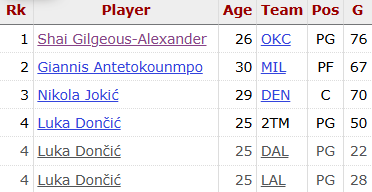

Agora vamos juntar essas duas tabelas usando o 'inner' que garantirá que apenas jogares que jogaram em 2024-25 e já tem contrato para 2025-26 aparecerão na nossa tabela. Depois iremos tranformar as colunas de interesse em numéricas.

In [ ]:
dados = pd.merge(dados_estat, dados_sal, on='Player', how='inner')
colunas_numericas = ['PTS','AST','STL','BLK','FGA','MP','ORB','DRB','2025-26']
dados[colunas_numericas] = dados[colunas_numericas].apply(pd.to_numeric, errors='coerce')
dados.info()
dados.head(448)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   448 non-null    object 
 1   PTS      448 non-null    float64
 2   AST      448 non-null    float64
 3   STL      448 non-null    float64
 4   BLK      448 non-null    float64
 5   FGA      448 non-null    float64
 6   MP       448 non-null    float64
 7   ORB      448 non-null    float64
 8   DRB      448 non-null    float64
 9   2025-26  448 non-null    int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 35.1+ KB


,Player,PTS,AST,STL,BLK,FGA,MP,ORB,DRB,2025-26
0,A.J. Green,15.8,3.1,1.1,0.2,12.4,1659.0,0.5,4.5,2301587
1,A.J. Lawson,23.4,3.1,1.3,0.6,18.8,486.0,2.0,6.5,2270735
2,AJ Johnson,16.4,5.7,0.9,0.2,15.9,639.0,0.6,3.8,3090480
3,Aaron Gordon,24.9,5.5,0.8,0.5,16.5,1447.0,2.7,5.5,22841455
4,Aaron Holiday,20.9,5.1,1.2,0.7,16.5,792.0,0.8,4.0,2296274
...,...,...,...,...,...,...,...,...,...,...
443,Zach LaVine,31.6,5.7,1.1,0.2,22.4,2602.0,0.4,5.4,47499660
444,Zeke Nnaji,14.6,1.8,2.0,3.0,11.2,608.0,2.6,4.5,8177778
445,Ziaire Williams,20.4,2.7,2.0,0.9,16.8,1541.0,2.0,7.3,6250000
446,Zion Williamson,41.7,9.0,2.1,1.5,28.7,857.0,4.3,7.9,39446090


Dessa forma, "dados" tem as estatísticas do jogador na temporada 2024-25 e seu salário para próxima temporada (2025-26), dessa forma veremos o impacto de suas estatísticas em seu salário, as estatísticas consideradas são:

*   PTS: Pontos
*   ORB: Rebotes Ofensivos
*   DRB: Rebotes Defensivos
*   FGA: Tentativas de arremessos
*   AST: Assistências
*   STL: Roubos de bola
*   BLK: Tocos
*   MP: Minutos jogados

Todas elas estão na forma de média por 100 posses da temporada 2024-25.


Agora vamos verificar se existe algum jogador que possa atrapalhar nossa análise, como por exemplo alguém sem salário para a temporada 2025-26 ou sem minutos jogados na temporada anterior. É importante remover esses casos pois eles podem interferir no verdadeiro objetivo do projeto por motivos à parte, como lesões e aposentadorias.

In [ ]:
dados.drop(dados[dados['2025-26'] == 0].index, inplace=True)
dados.info()
dados.isnull().any()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   448 non-null    object 
 1   PTS      448 non-null    float64
 2   AST      448 non-null    float64
 3   STL      448 non-null    float64
 4   BLK      448 non-null    float64
 5   FGA      448 non-null    float64
 6   MP       448 non-null    float64
 7   ORB      448 non-null    float64
 8   DRB      448 non-null    float64
 9   2025-26  448 non-null    int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 35.1+ KB


,0
Player,False
PTS,False
AST,False
STL,False
BLK,False
FGA,False
MP,False
ORB,False
DRB,False
2025-26,False


Vemos que esse filtagrem não removeu ninguém e mostrou que não temos células nulas, entretanto é um passo fundamental para evitar erros, caso esses exemplos existissem nos dados.

Como temos muito jogadores que jogaram uma quantidade muito baixa de minutos, vamos remover os 15% com menos minutos para evitar que jogadores que atuaram muito pouco (Seja por lesão ou por Habilidade) tenham uma influência grande, e evitar que eles impactem nas medidas centrais.

Corte: 379 minutos.


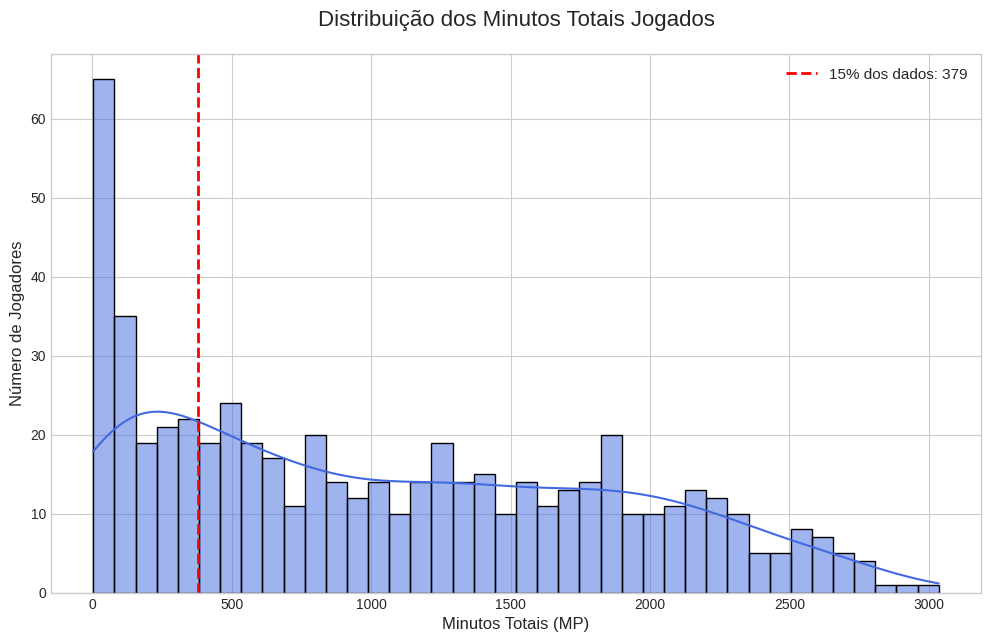

In [ ]:
corte = dados['MP'].quantile(0.15)
print(f"Corte: {corte:.0f} minutos.")

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 7))
sns.histplot(dados_estat['MP'], bins=40, kde=True, color='royalblue')
plt.title('Distribuição dos Minutos Totais Jogados', fontsize=16, pad=20)
plt.xlabel('Minutos Totais (MP)', fontsize=12)
plt.ylabel('Número de Jogadores', fontsize=12)
plt.axvline(corte, color='red', linestyle='--', lw=2, label=f'15% dos dados: {corte:.0f}')

plt.legend(fontsize=11)
plt.show()

# Análise Exploratória de Dados — Visualização Gráfica

Criando histogramas com curvas de densidade (KDE) para cada variável da base, com o objetivo de visualizar a distribuição dos dados e identificar padrões ou tendências de forma rápida e intuitiva.

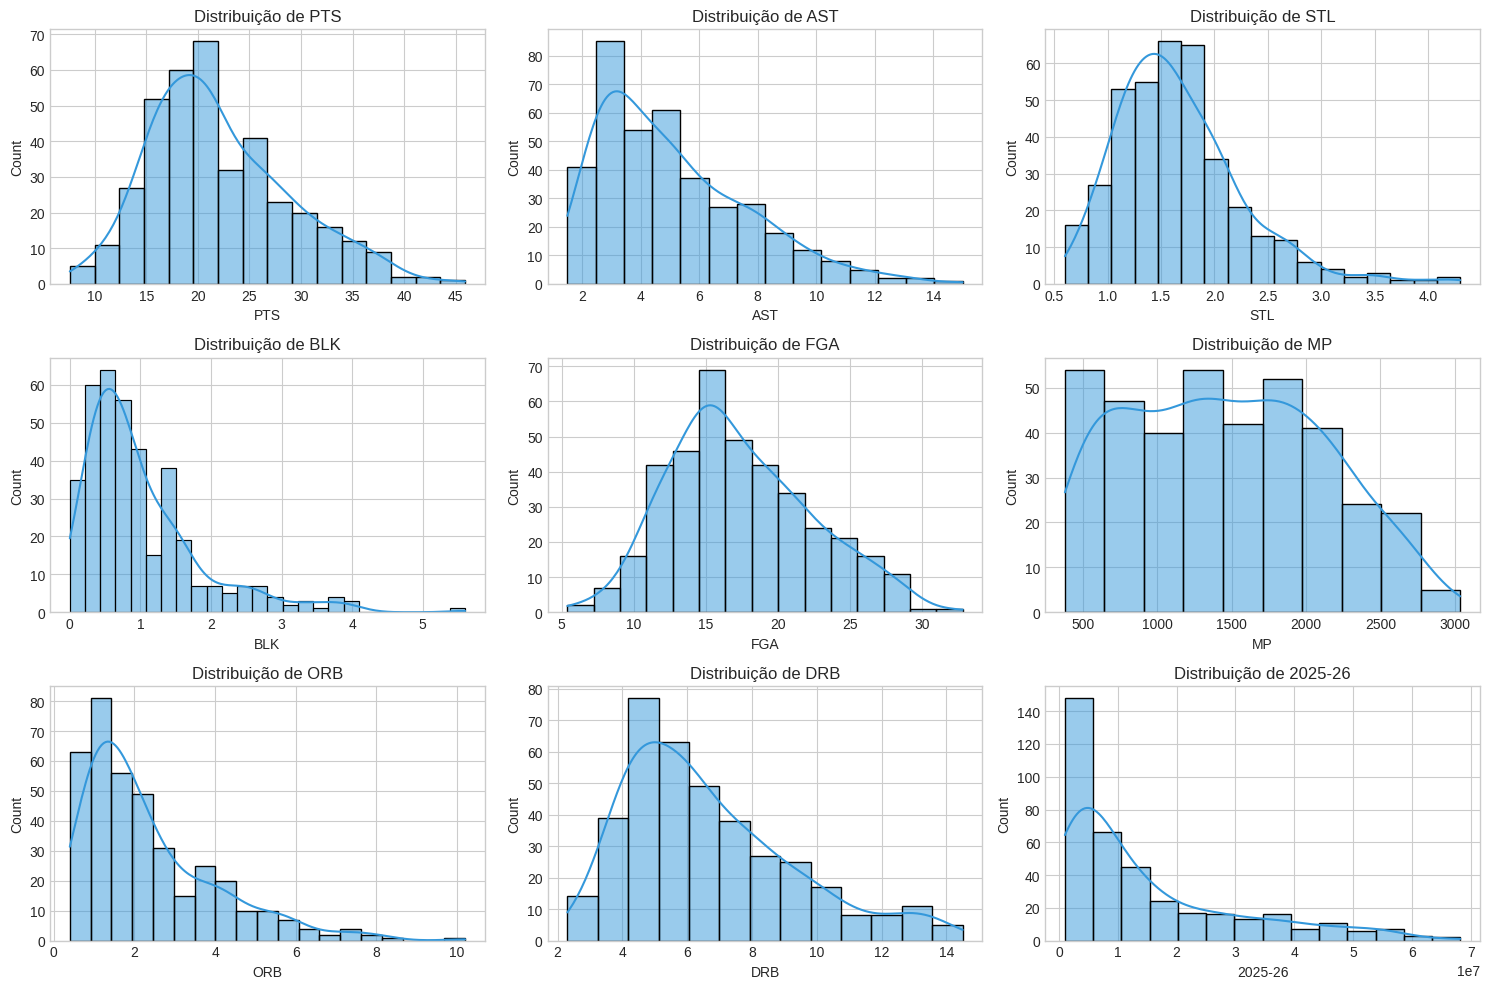

In [ ]:
variaveis = ['PTS', 'AST', 'STL', 'BLK', 'FGA', 'MP', 'ORB', 'DRB']
salario = '2025-26'
plt.figure(figsize=(15, 10))
for i, var in enumerate(variaveis + [salario], 1):
    plt.subplot(3, 3, i)
    sns.histplot(dados[var], kde=True, color='#3498DB')
    plt.title(f'Distribuição de {var}')
plt.tight_layout()
plt.show()

Gráficos de dispersão (scatter plots) para cada variável em relação ao salário, com o objetivo de visualizar a relação entre as estatísticas dos jogadores e seus salários, identificando tendências e possíveis correlações.

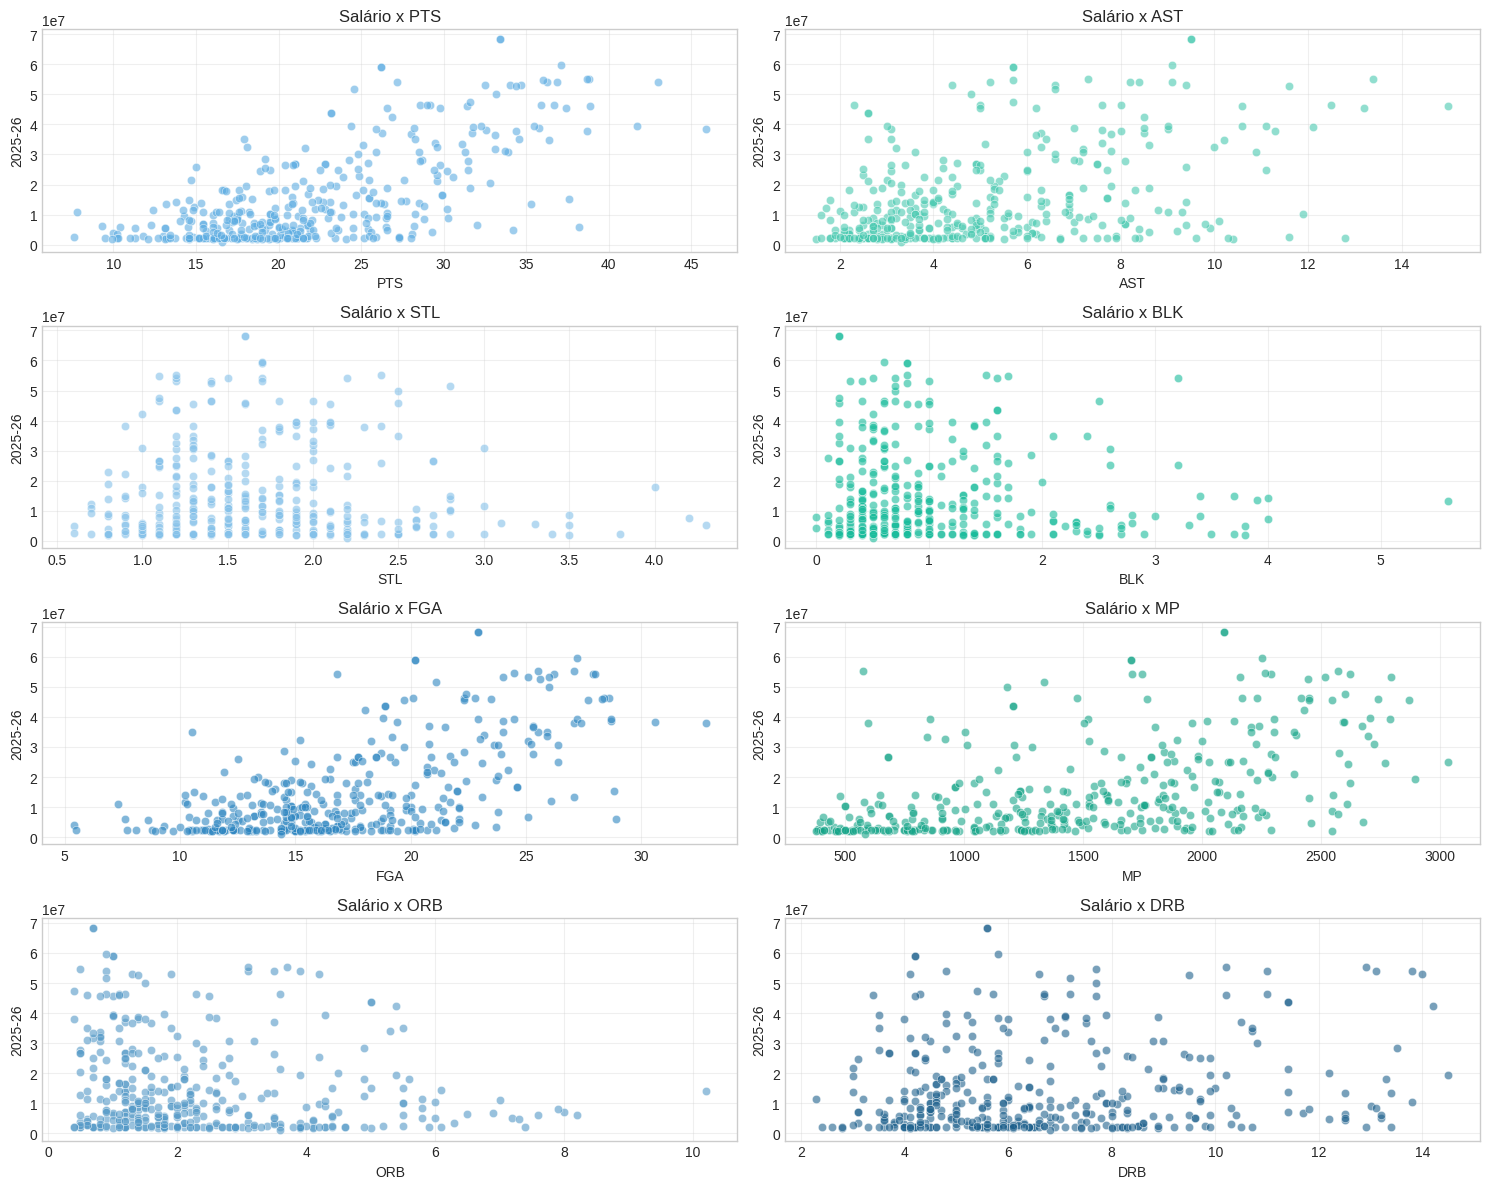

In [ ]:
cores = ['#5DADE2', '#48C9B0', '#85C1E9', '#1ABC9C', '#2E86C1', '#17A589', '#5499C7', '#1F618D']

plt.figure(figsize=(15, 12))
for i, var in enumerate(variaveis, 1):
    plt.subplot(4, 2, i)
    sns.scatterplot(data=dados, x=var, y=salario, color=cores[i-1], alpha=0.6)
    plt.title(f'Salário x {var}')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Gráficos de dispersão com linha de tendência para cada variável em relação ao salário, permitindo visualizar como o salário tende a variar conforme cada estatística aumenta. Em seguida, calculamos a correlação numérica entre cada variável e o salário, confirmando e quantificando visualmente as tendências observadas nos gráficos.

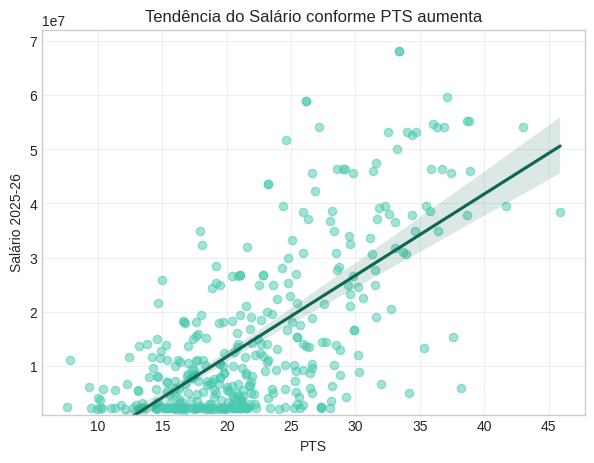

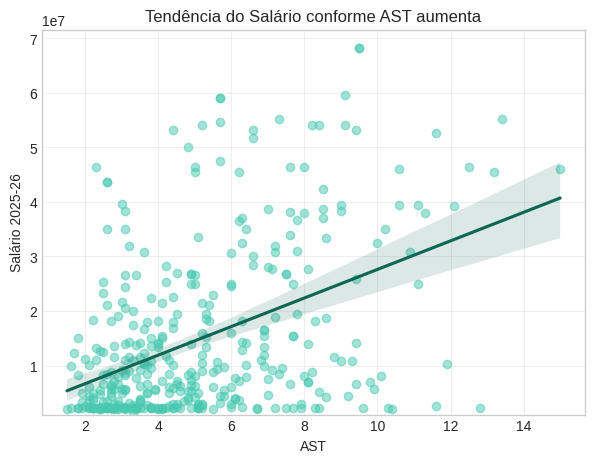

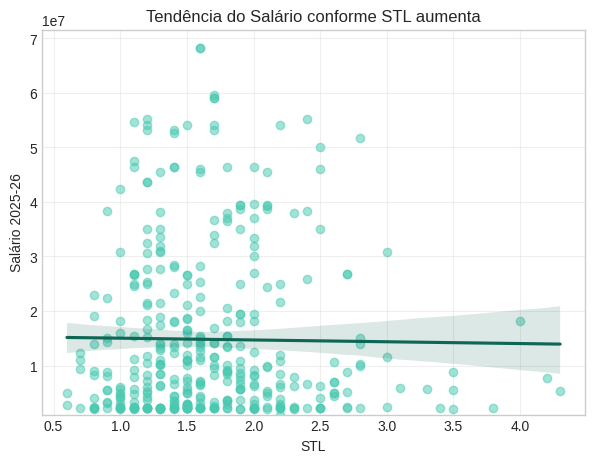

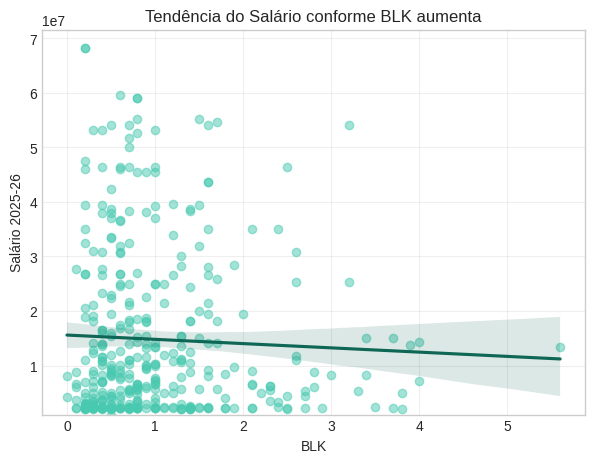

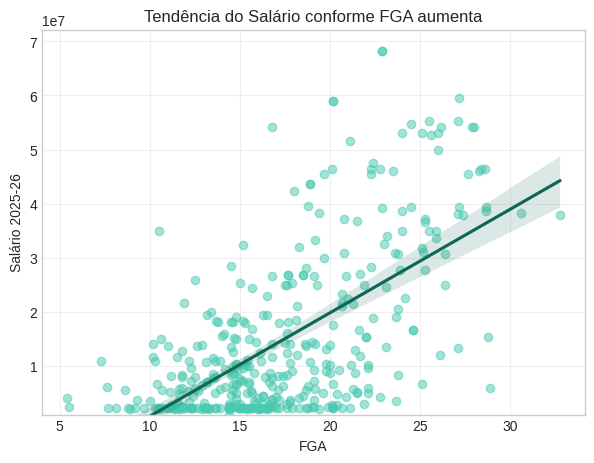

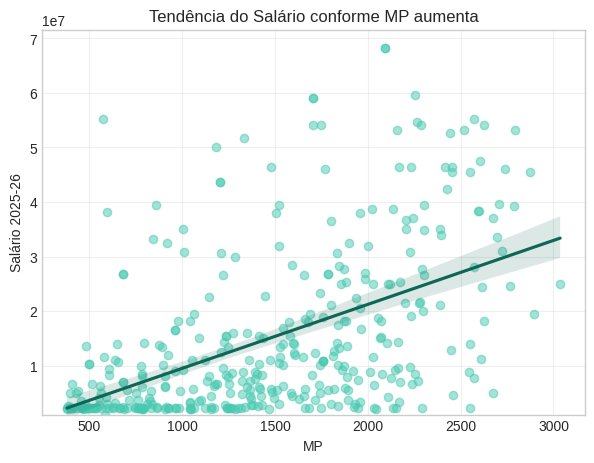

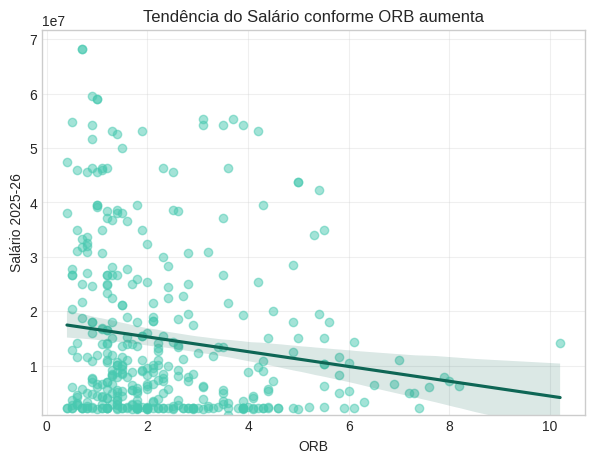

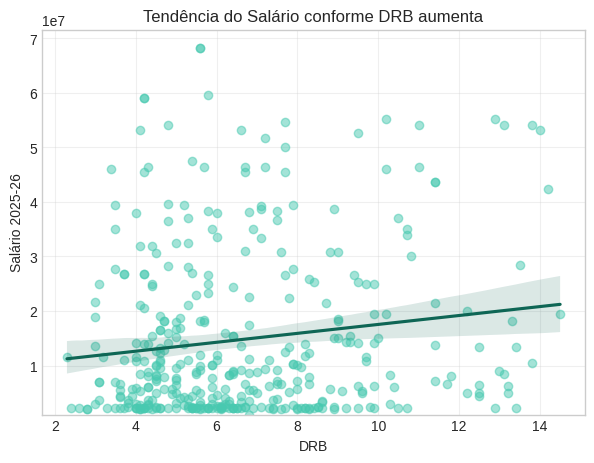


Correlação das variáveis com o salário:
2025-26    1.000000
PTS        0.679952
FGA        0.624120
MP         0.513320
AST        0.442905
DRB        0.141682
STL       -0.012992
BLK       -0.042913
ORB       -0.149980
Name: 2025-26, dtype: float64


In [ ]:

for var in variaveis:
    plt.figure(figsize=(7, 5))
    sns.regplot(
        data=dados,
        x=var,
        y=salario,
        scatter_kws={'alpha': 0.5, 'color': '#48C9B0'},
        line_kws={'color': '#0E6655'}
    )
    plt.title(f"Tendência do Salário conforme {var} aumenta")
    plt.xlabel(var)
    plt.ylabel("Salário 2025-26")
    plt.ylim(bottom=dados[salario].min())
    plt.grid(True, alpha=0.3)
    plt.show()

print("\nCorrelação das variáveis com o salário:")
print(dados[variaveis + [salario]].corr()[salario].sort_values(ascending=False))

Boxplots do salário divididos em quartis para cada variável, permitindo comparar visualmente como o salário se distribui entre níveis baixos, médios e altos de cada estatística, facilitando a identificação de padrões ou diferenças significativas entre os quartis.

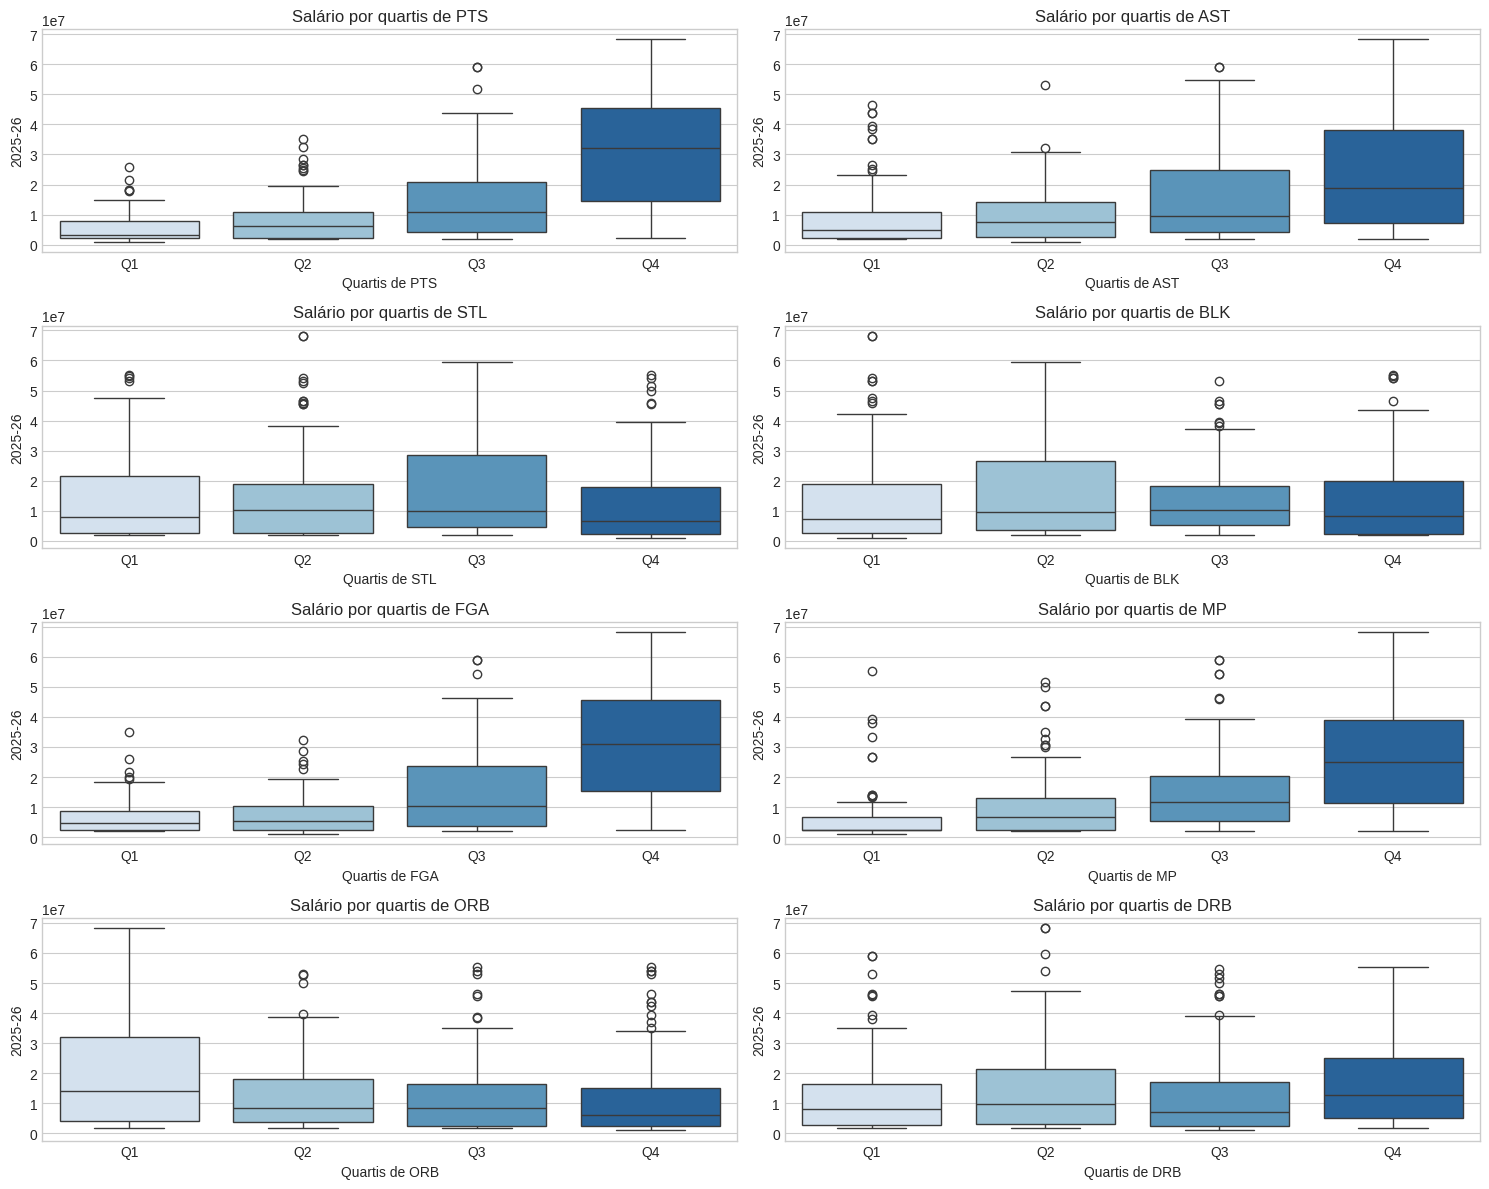

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.figure(figsize=(15, 12))
for i, var in enumerate(variaveis, 1):
    dados[f'{var}_quartil'] = pd.qcut(dados[var], 4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
    plt.subplot(4, 2, i)
    sns.boxplot(x=f'{var}_quartil', y=salario, data=dados, palette='Blues')
    plt.title(f'Salário por quartis de {var}')
    plt.xlabel(f'Quartis de {var}')
plt.tight_layout()
plt.show()

Agora vamos aplicar esse corte nos dados

In [ ]:
dados.drop(dados[dados['MP'] < 379.0].index, inplace=True)
dados.info()

<class 'pandas.core.frame.DataFrame'>
Index: 381 entries, 0 to 446
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   381 non-null    object 
 1   PTS      381 non-null    float64
 2   AST      381 non-null    float64
 3   STL      381 non-null    float64
 4   BLK      381 non-null    float64
 5   FGA      381 non-null    float64
 6   MP       381 non-null    float64
 7   ORB      381 non-null    float64
 8   DRB      381 non-null    float64
 9   2025-26  381 non-null    int64  
dtypes: float64(8), int64(1), object(1)
memory usage: 32.7+ KB


Com os dados prontos de fato, vamos começar as análises

#Análise de Regressão Linear Multivariada
Vamos ajustar um modelo de regressão linear com todas as variáveis para tentar prever o salário e verificar se ela é boa. Para isso, iremos testar as hipóteses de quais variáveis são insignificantes no modelo e, se existirem, retirá-las. Após isso vamos calcular o valor do $R^2$ ajustado para verificar a capacidade da regressão em explicar os salários.

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np

y = dados['2025-26']
X = dados.drop(columns=['Player', '2025-26'])
X_const = sm.add_constant(X)
modelo_inicial = sm.OLS(y, X_const).fit()

alfa = 0.05
p_valores = modelo_inicial.pvalues
variaveis_nao_significantes = p_valores[p_valores > alfa].index.tolist()
if 'const' in variaveis_nao_significantes:
    variaveis_nao_significantes.remove('const')

print(f"\nVariáveis não significantes com alfa={alfa}: {variaveis_nao_significantes}")

if variaveis_nao_significantes:
    X_final = X.drop(columns=variaveis_nao_significantes)
    X_final_const = sm.add_constant(X_final)
    modelo_final = sm.OLS(y, X_final_const).fit()
    modelo_final
else:
    modelo_final = modelo_inicial

params = modelo_final.params
equacao_str = f"Salario = {params['const']:.2f}"
for variavel, beta in params.drop('const').items():
    if beta >= 0:
        equacao_str += f" + {beta:.2f} * {variavel}"
    else:
        equacao_str += f" - {abs(beta):.2f} * {variavel}"

y_pred_ols = modelo_final.predict()
mae_ols = np.mean(np.abs(y - y_pred_ols))
ols_adj_r2 = modelo_final.rsquared_adj
ols_rmse = np.sqrt(modelo_final.mse_resid)

print(equacao_str)
print()
print(f"R² Ajustado: {ols_adj_r2:.4f}")
print(f"O modelo explica {modelo_final.rsquared_adj:.1%} da variação nos salários.\n")
print( )
print(f"P-valor da Estatística F: {modelo_final.f_pvalue:.4e}")
print("Testa a significância GERAL do modelo. Um valor muito baixo (< 0.05) indica que o modelo é útil e a relação encontrada não é fruto do acaso.\n")
print(f"Erro absoluto(MAE): {mae_ols:.2f}")
print(f"Raiz do Erro Quadrático Médio(RMSE): {ols_rmse:.2f}")


Variáveis não significantes com alfa=0.05: ['STL', 'BLK', 'FGA', 'ORB', 'DRB']
Salario = -23124992.71 + 1116636.80 * PTS + 897707.39 * AST + 5976.69 * MP

R² Ajustado: 0.5412
O modelo explica 54.1% da variação nos salários.


P-valor da Estatística F: 4.2909e-64
Testa a significância GERAL do modelo. Um valor muito baixo (< 0.05) indica que o modelo é útil e a relação encontrada não é fruto do acaso.

Erro absoluto(MAE): 7696663.23
Raiz do Erro Quadrático Médio(RMSE): 10217537.10


Nosso Modelo preditor é:

 **Salário$_{25/26} = -23124992.71 + 1116636.80.X_{PTS} + 897707.39.X_{AST} + 5976.69.X_{MP}$**

O nosso $R^2$ tem um valor baixo ($54.12$%) isso pode indicar que esse modelo não consegue explicar tão o bem os salários, entretanto, o valor da estatística F (Significância) é muito baixa, o que indica que os dados tem uma relação muito forte com o salário.

Como interpretação geral, podemos pensar que nosso modelo consegue entender que a relação entre as variáveis existe e é muito alta, entretanto ela falha ao tentar expressar essa relação de forma linear o que nos sugere que esses dados tenham uma relação não linear. Além disso, existem fatores que não são considerados na análise que podem ter influência como: idade, fama, time, atuações defensivas (que não são registradas no box-score).

#LassoCV

In [ ]:
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
features_ols_final = ['PTS', 'AST', 'MP']
X_ols = dados[features_ols_final]
y = dados['2025-26']

features_all = ['PTS','AST','STL','BLK','FGA','MP','ORB','DRB']
X_all = dados[features_all]
n = len(y)

print("--- Regressão LassoCV ---")


scaler_lasso = StandardScaler()
X_all_scaled = scaler_lasso.fit_transform(X_all)
X_all_scaled_df = pd.DataFrame(X_all_scaled, columns=features_all, index=X_all.index)

lasso_cv_model = LassoCV(cv=5, random_state=42, n_jobs=-1, max_iter=10000)
lasso_cv_model.fit(X_all_scaled_df, y)

best_alpha = lasso_cv_model.alpha_
print(f"\nMelhor alpha encontrado: {best_alpha:.4f}")

print("\nVariáveis selecionadas pelo LassoCV (coeficientes não nulos):")
coefs_lasso_cv = pd.Series(lasso_cv_model.coef_, index=features_all)
non_zero_coefs = coefs_lasso_cv[np.abs(coefs_lasso_cv) > 1e-6]
print(non_zero_coefs)
print(f"Intercepto: {lasso_cv_model.intercept_:.2f}")

# Avaliação
y_pred_lasso_cv = lasso_cv_model.predict(X_all_scaled_df)
r2_lasso_cv = r2_score(y, y_pred_lasso_cv)
p_lasso_cv = len(non_zero_coefs)
adj_r2_lasso_cv = 1 - (1 - r2_lasso_cv) * (n - 1) / (n - p_lasso_cv - 1) if (n - p_lasso_cv - 1) != 0 else np.nan
rmse_lasso_cv = np.sqrt(mean_squared_error(y, y_pred_lasso_cv))
mae_lasso = mean_absolute_error(y, y_pred_lasso_cv)

print(f"\nR² Ajustado: {adj_r2_lasso_cv:.4f}")
print(f"O modelo LassoCV explica {adj_r2_lasso_cv:.1%} da variação nos salários.")
print(f"Raiz do Erro Quadrático Médio(RMSE): {rmse_lasso_cv:.2f}")
print(f"Erro Absoluto(MAE): {mae_lasso:.2f}")

--- Regressão LassoCV ---

Melhor alpha encontrado: 312806.8946

Variáveis selecionadas pelo LassoCV (coeficientes não nulos):
PTS    7.191179e+06
AST    2.325702e+06
STL    1.881121e+04
MP     3.787134e+06
DRB    1.136387e+06
dtype: float64
Intercepto: 14793435.03

R² Ajustado: 0.5467
O modelo LassoCV explica 54.7% da variação nos salários.
Raiz do Erro Quadrático Médio(RMSE): 10075991.37
Erro Absoluto(MAE): 7656943.25


#Regressão Polinomial

In [ ]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

coluna_y = '2025-26'
features_ols_final = ['PTS', 'AST', 'MP']

colunas_necessarias = [coluna_y] + features_ols_final
df_completo = dados[colunas_necessarias]
df_limpo = df_completo.dropna()

if df_limpo.empty:
    print(f"Erro: Não há dados suficientes nas colunas {colunas_necessarias} após remover NaNs.")
else:
    print(f"Total de {len(df_limpo)} observações")

    y = df_limpo[coluna_y]
    X_ols = df_limpo[features_ols_final]


    print('Criando Features Polinomiais (Grau 2)')
    degree = 2
    poly_features = PolynomialFeatures(degree=degree, include_bias=False)

    X_poly = poly_features.fit_transform(X_ols)
    poly_feature_names = poly_features.get_feature_names_out(features_ols_final)

    scaler_poly = StandardScaler()
    X_poly_scaled = scaler_poly.fit_transform(X_poly)

    X_para_eliminar = pd.DataFrame(
        X_poly_scaled,
        columns=poly_feature_names,
        index=X_ols.index)
    print(f'\nUsaremos alfa=0.15 para remover apenas variáveis que tem uma influência extremamente baixa.')
    alfa = 0.15
    variaveis_do_modelo = X_para_eliminar.columns.tolist()
    modelo_final = None

    while len(variaveis_do_modelo) > 0:
        X_temp_const = sm.add_constant(X_para_eliminar[variaveis_do_modelo])
        modelo_atual = sm.OLS(y, X_temp_const).fit()

        p_valores = modelo_atual.pvalues.drop('const')

        p_max = p_valores.max()
        variavel_a_remover = p_valores.idxmax()

        if p_max <= alfa:
            print(f"\nTodas as variáveis restantes são significantes a alfa = 0.15.")
            modelo_final = modelo_atual
            break

        print(f"\nRemovendo: '{variavel_a_remover}' (p-valor: {p_max:.4f})")
        print(f"R² Ajustado ANTES da remoção: {modelo_atual.rsquared_adj:.4f}")

        variaveis_do_modelo.remove(variavel_a_remover)

        X_depois_const = sm.add_constant(X_para_eliminar[variaveis_do_modelo])
        modelo_depois = sm.OLS(y, X_depois_const).fit()
        print(f"R² Ajustado DEPOIS da remoção: {modelo_depois.rsquared_adj:.4f}")


    print("\nModelo Polinomial Final:")

    if modelo_final:
        params = modelo_final.params
        equacao_str = f"Salario = {params['const']:.2f}"

        for variavel, beta in params.drop('const').items():
            if beta >= 0:
                equacao_str += f" + {beta:.2f} * {variavel}"
            else:
                equacao_str += f" - {abs(beta):.2f} * {variavel}"

        print(equacao_str)


        y_pred = modelo_final.predict()
        mae_poly = np.mean(np.abs(y - y_pred))
        adj_r2_poly = modelo_final.rsquared_adj
        rmse_poly = np.sqrt(modelo_final.mse_resid)


        print(f"\nO modelo final explica R²={adj_r2_poly:.2%} da variação nos salários.")
        print(f"MAE: {mae_poly:.2f}")
        print(f"RMSE: {rmse_poly:.2f}")
    else:
        print(f"\nNão foi possível gerar um modelo final.")


Total de 381 observações
Criando Features Polinomiais (Grau 2)

Usaremos alfa=0.15 para remover apenas variáveis que tem uma influência extremamente baixa.

Removendo: 'MP' (p-valor: 0.8670)
R² Ajustado ANTES da remoção: 0.5770
R² Ajustado DEPOIS da remoção: 0.5781

Removendo: 'AST' (p-valor: 0.7769)
R² Ajustado ANTES da remoção: 0.5781
R² Ajustado DEPOIS da remoção: 0.5791

Removendo: 'MP^2' (p-valor: 0.6688)
R² Ajustado ANTES da remoção: 0.5791
R² Ajustado DEPOIS da remoção: 0.5800

Removendo: 'AST^2' (p-valor: 0.6060)
R² Ajustado ANTES da remoção: 0.5800
R² Ajustado DEPOIS da remoção: 0.5808

Todas as variáveis restantes são significantes a alfa = 0.15.

Modelo Polinomial Final:
Salario = 14793435.03 - 4708473.82 * PTS + 5606909.73 * PTS^2 + 5914128.90 * PTS AST + 8839043.38 * PTS MP - 3378760.12 * AST MP

O modelo final explica R²=58.08% da variação nos salários.
MAE: 6850690.82
RMSE: 9765839.38


Como o R² do modelo polinomial é melhor, vamos considerá-lo superior. Agora faremos uma análise do resíduo:


Análise de normalidade para 381 resíduos


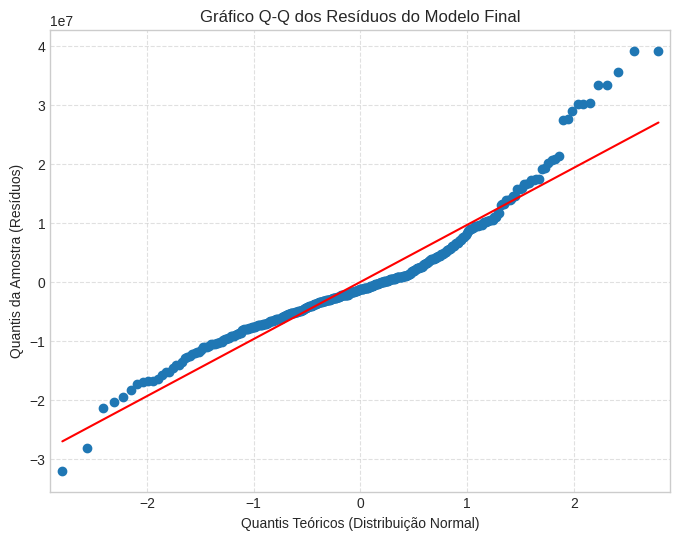

Teste de Normalidade (Shapiro-Wilk)
Estatística do Teste: 0.9292
P-valor: 0.000000000001853
Nível de Significância (alfa): 0.05
Interpretação: P-valor = 0.000000000001853 <= alfa (0.05).
Rejeitamos H0. Os resíduos NÃO PARECEM ser normalmente distribuídos.


In [ ]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.stats import shapiro
import numpy as np
import pandas as pd

residuos = modelo_final.resid
print(f"\nAnálise de normalidade para {len(residuos)} resíduos")

fig, ax = plt.subplots(figsize=(8, 6))
sm.qqplot(residuos, line='s', ax=ax)
ax.set_title("Gráfico Q-Q dos Resíduos do Modelo Final")
ax.set_xlabel("Quantis Teóricos (Distribuição Normal)")
ax.set_ylabel("Quantis da Amostra (Resíduos)")
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()


print("Teste de Normalidade (Shapiro-Wilk)")

stat_shapiro, p_valor_shapiro = shapiro(residuos)

print(f"Estatística do Teste: {stat_shapiro:.4f}")
print(f"P-valor: {p_valor_shapiro:.15f}")

alfa_teste = 0.05
print(f"Nível de Significância (alfa): {alfa_teste}")

if p_valor_shapiro > alfa_teste:
    print(f"Interpretação: P-valor = {p_valor_shapiro:.15f} > alfa ({alfa_teste}).")
    print("Falhamos em rejeitar a H0. Os resíduos PARECEM ser normalmente distribuídos.")
else:
    print(f"Interpretação: P-valor = {p_valor_shapiro:.15f} <= alfa ({alfa_teste}).")
    print("Rejeitamos H0. Os resíduos NÃO PARECEM ser normalmente distribuídos.")

Podemos notar que o resíduo dessa regressão não é normalmente distribuído.

#Random Forest Regressor
Para as regressões lineares, selecionamos apenas 9 colunas básicas. O objetivo lá era manter o modelo simples e interpretável, evitando variáveis redundantes (multicolinearidade) que atrapalham regressões lineares. Porém, o Random Forest é um algoritmo robusto que lida muito bem com muitas variáveis e relações não lineares. Ao adicionar essas estatísticas extras (como eficiência de arremesso e consistência em jogos), nós fornecemos mais informação para a árvore de decisão criar regras complexas, o que geralmente aumenta a precisão do modelo em comparação a usar apenas os pontos e rebotes básicos. Por isso, precisamos rodar novamente os dados, e dessa vez, selecionar mais colunas para adicionar mais informação para o modelo.

In [ ]:
# @title Dados para o Random Forest
csv_data2 = """Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,2P%,eFG%,FT,FTA,FT%,ORB,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,ORtg,DRtg,Awards,Player-additional
1,Mikal Bridges,28,NYK,SF,82,82,3036,9.7,19.3,.500,2.7,7.6,.354,7.0,11.8,.594,.570,1.6,1.9,.814,1.2,3.1,4.2,5.0,1.2,0.7,2.2,2.1,23.6,117,118,,bridgmi01
2,Josh Hart,29,NYK,SG,77,77,2897,6.9,13.2,.525,1.4,4.3,.333,5.5,8.9,.618,.579,2.7,3.5,.776,2.8,9.9,12.6,7.8,2.0,0.5,2.7,3.4,18.0,125,112,,hartjo01
3,Anthony Edwards,23,MIN,SG,79,79,2871,12.4,27.7,.447,5.5,13.9,.395,6.9,13.8,.501,.547,7.1,8.5,.837,1.0,6.7,7.7,6.2,1.6,0.9,4.3,2.6,37.4,115,112,MVP-7CPOY-3ASNBA2,edwaran01
4,Devin Booker,28,PHO,SG,75,75,2795,11.6,25.1,.461,3.2,9.7,.332,8.3,15.4,.542,.525,7.6,8.5,.894,1.3,4.1,5.4,9.4,1.2,0.3,3.9,3.5,34.0,119,123,,bookede01
5,James Harden,35,LAC,PG,79,79,2789,9.4,22.9,.410,4.1,11.8,.352,5.2,11.1,.472,.501,8.9,10.2,.874,1.0,7.1,8.1,12.1,2.1,1.0,6.0,2.9,31.8,114,110,MVP-10ASNBA3,hardeja01
6,DeMar DeRozan,35,SAC,SF,77,77,2768,11.0,23.1,.477,1.5,4.5,.328,9.5,18.6,.513,.509,6.7,7.8,.857,0.9,4.4,5.3,6.0,1.1,0.6,1.9,2.7,30.2,120,119,,derozde01
7,Trae Young,26,ATL,PG,76,76,2739,9.7,23.5,.411,3.7,11.0,.340,5.9,12.5,.474,.491,8.4,9.6,.875,0.6,3.4,4.0,15.0,1.6,0.2,6.1,2.5,31.4,114,119,CPOY-4AS,youngtr01
8,Tyler Herro,25,MIA,SG,77,77,2725,11.9,25.2,.472,4.6,12.3,.375,7.3,13.0,.565,.563,5.3,6.0,.878,0.6,6.7,7.3,7.8,1.3,0.3,3.6,1.6,33.7,117,115,AS,herroty01
9,OG Anunoby,27,NYK,PF,74,74,2706,9.0,18.8,.476,3.1,8.4,.372,5.8,10.4,.561,.559,3.4,4.1,.810,1.8,4.8,6.6,3.0,2.0,1.2,1.9,3.2,24.4,118,114,,anunoog01
10,Jalen Green,22,HOU,SG,82,82,2697,11.0,25.9,.423,4.2,11.9,.354,6.8,14.0,.482,.505,4.9,6.1,.813,0.8,6.0,6.8,5.1,1.3,0.5,3.7,2.3,31.1,110,113,,greenja05
11,Christian Braun,23,DEN,SG,79,77,2675,8.6,14.8,.580,1.6,4.0,.397,7.0,10.7,.648,.634,3.2,3.8,.827,1.8,5.6,7.4,3.7,1.5,0.7,1.5,3.1,21.9,133,118,,braunch01
12,Bam Adebayo,27,MIA,C,78,78,2674,10.1,20.8,.485,1.5,4.1,.357,8.6,16.6,.517,.521,4.7,6.1,.765,3.5,10.5,14.0,6.3,1.8,1.0,3.0,3.0,26.3,115,110,DPOY-10,adebaba01
13,Ivica Zubac,27,LAC,C,80,80,2624,11.1,17.7,.628,0.0,0.0,,11.1,17.7,.628,.628,2.9,4.4,.661,5.6,13.3,19.0,4.0,1.0,1.7,2.4,3.2,25.1,129,108,DPOY-6DEF2,zubaciv01
14,Jayson Tatum,26,BOS,PF,72,72,2624,12.7,28.0,.452,4.8,13.9,.343,7.9,14.1,.559,.537,6.8,8.4,.814,0.9,11.0,11.9,8.2,1.5,0.7,4.0,3.0,36.9,117,110,MVP-4CPOY-10ASNBA1,tatumja01
15,Jaden McDaniels,24,MIN,PF,82,82,2614,7.5,15.7,.477,1.9,5.7,.330,5.6,10.0,.561,.537,2.0,2.4,.813,2.4,6.4,8.9,3.1,2.1,1.4,1.8,4.2,18.9,115,110,,mcdanja02
16,Keegan Murray,24,SAC,PF,76,76,2610,6.8,15.4,.444,2.9,8.4,.343,3.9,7.0,.566,.538,1.1,1.3,.833,2.7,6.8,9.5,2.0,1.1,1.3,1.1,3.5,17.7,116,117,,murrake02
17,Zach LaVine,29,2TM,SG,74,74,2602,11.4,22.4,.511,4.4,9.8,.446,7.1,12.6,.562,.609,4.3,5.2,.825,0.4,5.4,5.8,5.7,1.1,0.2,3.8,2.2,31.6,116,119,,lavinza01
17,Zach LaVine,29,CHI,SF,42,42,1432,11.8,23.1,.511,4.4,9.9,.446,7.4,13.2,.560,.607,4.7,5.9,.797,0.4,6.2,6.6,6.2,1.3,0.3,3.9,2.1,32.8,115,117,,lavinza01
17,Zach LaVine,29,SAC,SG,32,32,1170,11.0,21.4,.511,4.3,9.7,.446,6.6,11.8,.564,.611,3.8,4.3,.874,0.4,4.3,4.7,5.1,0.8,0.1,3.6,2.4,30.0,117,121,,lavinza01
18,Shai Gilgeous-Alexander,26,OKC,PG,76,76,2598,15.9,30.6,.519,3.0,8.0,.375,12.9,22.6,.571,.569,11.1,12.4,.898,1.2,5.8,7.0,9.0,2.4,1.4,3.4,3.0,45.9,129,107,MVP-1DPOY-10CPOY-8ASNBA1,gilgesh01
19,Michael Porter Jr.,26,DEN,SF,77,77,2593,9.8,19.4,.504,3.6,9.1,.395,6.2,10.4,.599,.596,2.8,3.6,.768,2.6,7.5,10.0,3.1,0.9,0.7,1.9,2.9,25.9,122,118,,portemi01
20,Derrick White,30,BOS,SG,76,76,2574,8.3,18.7,.442,5.2,13.5,.384,3.1,5.2,.593,.580,2.6,3.1,.839,1.3,5.3,6.6,7.0,1.4,1.6,2.6,2.7,24.3,123,112,DPOY-10,whitede01
21,Dyson Daniels,21,ATL,SG,76,76,2571,8.3,16.8,.493,1.5,4.3,.340,6.8,12.5,.545,.536,1.5,2.5,.593,2.3,5.9,8.2,6.1,4.2,1.0,2.8,3.2,19.5,110,111,DPOY-2MIP-1DEF1,daniedy01
22,Nikola Jokić,29,DEN,C,70,70,2571,14.7,25.5,.576,2.6,6.2,.417,12.1,19.3,.627,.627,6.8,8.4,.800,3.7,12.9,16.7,13.4,2.4,0.8,4.3,3.0,38.7,133,111,MVP-2CPOY-2ASNBA1,jokicni01
23,Austin Reaves,26,LAL,SG,73,73,2550,9.2,20.0,.460,3.9,10.2,.377,5.3,9.8,.547,.556,6.2,7.1,.877,1.2,5.2,6.3,8.1,1.6,0.4,3.4,2.9,28.5,122,117,,reaveau01
24,Toumani Camara,24,POR,PF,78,78,2548,6.3,13.7,.458,2.6,6.9,.375,3.7,6.8,.542,.552,1.7,2.4,.722,3.3,5.3,8.6,3.3,2.2,1.0,2.1,4.4,16.8,117,115,DPOY-9DEF2,camarto01
25,Pascal Siakam,30,IND,PF,78,78,2548,11.6,22.3,.519,2.4,6.1,.389,9.2,16.2,.568,.572,4.3,5.8,.734,2.5,7.7,10.2,5.0,1.3,0.8,2.1,3.6,29.8,120,115,AS,siakapa01
26,Brook Lopez,36,MIL,C,80,80,2546,7.5,14.7,.509,2.6,7.1,.373,4.8,7.6,.636,.599,2.2,2.6,.826,2.1,5.5,7.6,2.7,0.9,2.8,1.6,3.2,19.8,122,114,,lopezbr01
27,Karl-Anthony Towns,29,NYK,C,72,72,2517,12.6,24.0,.526,2.8,6.7,.420,9.8,17.3,.567,.584,6.7,8.1,.829,4.2,14.0,18.1,4.4,1.4,1.0,3.8,4.9,34.7,122,110,ASNBA3,townska01
28,Bub Carrington,19,WAS,PG,82,57,2458,5.8,14.5,.401,2.7,7.9,.339,3.1,6.6,.475,.493,1.3,1.6,.812,0.6,6.0,6.6,7.0,1.0,0.4,2.7,3.7,15.6,104,121,,carrica01
29,Cade Cunningham,23,DET,PG,70,70,2452,13.4,28.6,.469,2.9,8.2,.356,10.5,20.4,.515,.521,6.1,7.3,.846,1.1,7.2,8.3,12.5,1.4,1.0,6.1,3.8,35.9,112,113,MVP-7ASNBA3,cunnica01
30,Tyrese Haliburton,24,IND,PG,73,73,2451,9.3,19.7,.473,4.3,11.0,.388,5.1,8.7,.581,.582,3.7,4.4,.851,0.8,4.2,5.1,13.2,2.1,1.0,2.4,1.8,26.6,131,115,NBA3,halibty01
31,Coby White,24,CHI,SG,74,73,2450,9.7,21.4,.453,4.1,11.1,.370,5.6,10.2,.544,.550,5.3,5.8,.902,0.5,4.7,5.2,6.3,1.3,0.3,3.4,2.9,28.8,114,118,,whiteco01
32,LeBron James,40,LAL,SF,70,70,2444,13.1,25.6,.513,3.0,8.0,.376,10.1,17.6,.574,.571,5.2,6.7,.782,1.4,9.5,11.0,11.6,1.4,0.8,5.2,2.0,34.4,117,114,MVP-6CPOY-7ASNBA2,jamesle01
33,Domantas Sabonis,28,SAC,C,70,70,2429,10.6,18.0,.590,1.3,3.1,.417,9.3,14.8,.627,.627,4.4,5.8,.754,5.4,14.2,19.6,8.5,1.0,0.5,4.1,4.6,26.9,128,114,,sabondo01
34,Jamal Murray,27,DEN,PG,67,67,2418,10.6,22.3,.474,3.1,7.9,.393,7.5,14.4,.518,.543,4.3,4.9,.886,0.9,4.3,5.2,8.0,1.8,0.7,2.7,2.5,28.6,120,118,,murraja01
35,Alperen Şengün,22,HOU,C,76,76,2395,11.5,23.2,.496,0.4,1.8,.233,11.1,21.4,.519,.505,6.0,8.7,.692,5.3,10.7,16.0,7.6,1.7,1.2,3.9,4.2,29.5,116,108,AS,sengual01
36,Dillon Brooks,29,HOU,SF,75,75,2388,7.8,18.2,.429,3.8,9.6,.397,4.0,8.7,.465,.533,2.0,2.5,.818,1.5,4.1,5.6,2.6,1.2,0.3,1.5,4.9,21.5,117,114,,brookdi01
37,Rudy Gobert,32,MIN,C,72,72,2388,7.0,10.5,.669,0.0,0.0,,7.0,10.5,.669,.669,3.8,5.6,.674,5.5,10.7,16.2,2.6,1.2,2.1,1.8,3.8,17.9,138,109,DPOY-13DEF2,goberru01
38,Tobias Harris,32,DET,PF,73,73,2305,8.0,16.8,.477,1.9,5.5,.345,6.1,11.3,.542,.534,3.0,3.5,.861,1.4,7.7,9.0,3.4,1.5,1.2,1.8,2.9,20.9,116,113,,harrito02
39,Darius Garland,25,CLE,PG,75,75,2301,11.6,24.5,.472,4.4,11.1,.401,7.1,13.5,.530,.562,4.7,5.3,.878,1.0,3.5,4.5,10.6,1.9,0.2,4.0,3.0,32.3,121,115,CPOY-6AS,garlada01
40,Jalen Brunson,28,NYK,PG,65,65,2301,12.6,25.9,.488,3.3,8.6,.383,9.3,17.3,.539,.551,7.9,9.7,.821,0.6,3.5,4.0,10.2,1.3,0.2,3.5,3.0,36.4,123,118,MVP-10CPOY-1ASNBA2,brunsja01
41,Jarrett Allen,26,CLE,C,82,82,2296,9.5,13.4,.706,0.0,0.1,.000,9.5,13.3,.712,.706,4.2,5.8,.718,4.5,12.2,16.7,3.3,1.6,1.5,2.0,2.7,23.1,142,108,,allenja01
42,Chris Paul,39,SAS,PG,82,82,2292,5.3,12.3,.427,3.0,7.8,.377,2.3,4.5,.514,.547,1.8,1.9,.924,0.7,5.5,6.2,12.8,2.2,0.5,2.7,3.2,15.2,125,118,,paulch01
43,Anfernee Simons,25,POR,SG,70,70,2292,10.2,23.9,.426,4.6,12.6,.363,5.6,11.3,.496,.521,3.7,4.1,.902,0.5,3.5,4.0,7.1,1.3,0.1,3.0,2.5,28.6,115,119,,simonan01
44,Giannis Antetokounmpo,30,MIL,PF,67,67,2289,16.8,27.9,.601,0.3,1.3,.222,16.5,26.5,.620,.607,9.2,14.9,.617,3.1,13.8,16.9,9.1,1.2,1.6,4.4,3.3,43.0,122,109,MVP-3DPOY-8ASNBA1,antetgi01
45,Malik Beasley,28,DET,SG,82,18,2283,9.7,22.6,.430,6.7,16.1,.416,3.0,6.4,.466,.579,2.0,2.9,.679,1.0,3.5,4.5,2.9,1.5,0.1,1.7,2.6,28.1,116,117,6MOY-2,beaslma01
46,Kentavious Caldwell-Pope,31,ORL,SG,77,77,2279,5.2,11.9,.439,2.5,7.2,.342,2.8,4.7,.589,.543,1.8,2.1,.863,0.7,3.0,3.7,3.0,2.2,0.7,1.4,3.0,14.7,115,112,,caldwke01
47,Nikola Vučević,34,CHI,C,73,72,2278,11.3,21.3,.530,2.6,6.6,.402,8.6,14.7,.587,.592,2.5,3.1,.805,3.6,11.4,15.1,5.2,1.2,1.1,2.4,3.3,27.6,122,113,,vucevni01
48,Payton Pritchard,27,BOS,PG,80,3,2271,9.0,19.1,.472,5.6,13.8,.407,3.4,5.3,.642,.620,1.6,1.9,.845,2.3,4.5,6.8,6.2,1.5,0.3,1.8,2.6,25.3,131,114,6MOY-1,pritcpa01
49,Kevin Durant,36,PHO,PF,62,62,2265,12.9,24.5,.527,3.5,8.1,.430,9.4,16.4,.574,.598,6.6,7.9,.839,0.5,7.7,8.2,5.7,1.1,1.7,4.1,2.3,36.0,117,119,AS,duranke01
50,Shaedon Sharpe,21,POR,SG,72,52,2252,10.8,23.8,.452,3.2,10.2,.311,7.6,13.6,.557,.519,4.1,5.2,.785,1.5,5.5,7.0,4.3,1.3,0.3,3.2,2.6,28.8,110,117,,sharpsh01
51,Stephen Curry,36,GSW,PG,70,70,2252,12.2,27.2,.448,6.7,16.9,.397,5.5,10.2,.534,.572,6.0,6.5,.933,0.9,5.8,6.7,9.1,1.7,0.6,4.3,2.1,37.1,120,113,MVP-9CPOY-5ASNBA2,curryst01
52,De'Aaron Fox,27,2TM,PG,62,62,2241,11.7,25.3,.463,2.6,8.3,.310,9.2,17.0,.538,.514,5.7,6.9,.827,1.2,5.3,6.5,8.5,2.0,0.5,3.8,3.6,31.7,113,117,,foxde01
52,De'Aaron Fox,27,SAC,PG,45,45,1663,12.2,26.0,.469,2.7,8.4,.322,9.5,17.6,.539,.521,6.0,7.2,.829,1.3,5.3,6.6,8.1,1.9,0.6,3.9,3.5,33.1,113,117,,foxde01
52,De'Aaron Fox,27,SAS,PG,17,17,578,10.5,23.4,.446,2.2,7.9,.274,8.3,15.5,.535,.493,4.9,6.0,.819,0.8,5.4,6.1,9.7,2.1,0.4,3.4,3.8,28.0,111,118,,foxde01
53,Jalen Williams,23,OKC,SG,69,69,2237,12.1,25.1,.484,2.7,7.3,.365,9.5,17.8,.533,.537,5.1,6.4,.789,1.3,6.7,7.9,7.6,2.4,1.0,3.2,3.4,32.0,116,107,ASNBA3DEF2,willija06
54,Donovan Mitchell,28,CLE,SG,71,71,2232,12.6,28.4,.443,5.0,13.6,.368,7.6,14.8,.512,.531,6.4,7.8,.823,1.2,5.7,6.9,7.6,2.0,0.4,3.2,3.0,36.7,118,113,MVP-5CPOY-9ASNBA1,mitchdo01
55,Harrison Barnes,32,SAS,PF,82,82,2230,7.5,14.8,.508,3.4,7.8,.433,4.1,7.0,.591,.622,3.5,4.3,.809,2.1,4.6,6.7,2.9,0.8,0.3,1.1,1.6,21.9,132,122,,barneha02
56,Julius Randle,30,MIN,PF,69,69,2226,10.1,20.8,.485,2.4,7.0,.344,7.7,13.9,.555,.542,6.0,7.4,.806,3.2,7.6,10.8,7.2,1.0,0.4,4.3,3.9,28.5,117,113,,randlju01
57,Amen Thompson,22,HOU,SF,69,42,2225,8.5,15.2,.557,0.5,2.0,.275,7.9,13.3,.599,.575,3.7,5.4,.684,4.2,8.1,12.3,5.8,2.1,1.9,3.0,3.7,21.2,123,108,DPOY-5DEF1,thompam01
58,Jaren Jackson Jr.,25,MEM,C,74,74,2207,12.5,25.5,.488,3.1,8.2,.375,9.4,17.4,.541,.548,6.6,8.4,.781,1.9,6.9,8.8,3.1,1.9,2.4,3.2,5.4,34.6,115,111,DPOY-7ASDEF2,jacksja02
59,Desmond Bane,26,MEM,SG,69,68,2205,10.4,21.5,.484,3.5,8.8,.392,6.9,12.6,.548,.565,3.7,4.2,.894,1.3,7.5,8.8,7.8,1.7,0.6,3.6,3.5,28.0,119,113,,banede01
60,Naz Reid,25,MIN,C,80,17,2200,9.6,20.7,.462,3.9,10.4,.379,5.6,10.3,.544,.556,2.5,3.2,.776,2.1,8.7,10.8,4.1,1.3,1.6,2.4,4.2,25.5,115,110,6MOY-5,reidna01
61,Tyus Jones,28,PHO,PG,81,58,2174,7.0,15.5,.448,3.8,9.1,.414,3.2,6.4,.496,.570,1.2,1.3,.895,0.9,3.5,4.5,9.8,1.6,0.2,2.1,1.4,18.9,124,122,,jonesty01
62,Myles Turner,28,IND,C,72,72,2174,8.6,17.9,.481,3.4,8.7,.396,5.2,9.2,.561,.577,4.1,5.3,.773,2.0,8.4,10.4,2.5,1.2,3.2,2.7,4.0,24.8,113,112,,turnemy01
63,Evan Mobley,23,CLE,PF,71,71,2167,11.2,20.1,.557,1.9,5.1,.370,9.3,15.0,.621,.604,4.9,6.8,.725,3.6,11.0,14.6,5.0,1.4,2.5,3.2,3.1,29.2,124,108,MVP-10DPOY-1ASNBA2DEF1,mobleev01
64,Taurean Prince,30,MIL,SF,80,73,2166,5.2,11.5,.457,3.3,7.5,.439,2.0,4.0,.492,.600,0.9,1.1,.813,0.8,5.6,6.4,3.5,1.7,0.3,1.8,3.7,14.6,114,115,,princta02
65,Stephon Castle,20,SAS,PG,81,47,2162,9.5,22.1,.428,2.1,7.4,.285,7.3,14.6,.501,.476,5.6,7.7,.724,2.0,4.6,6.6,7.4,1.7,0.5,4.0,3.7,26.6,106,119,ROY-1,castlst01
66,Deni Avdija,24,POR,SF,72,54,2161,9.0,19.0,.476,2.8,7.7,.365,6.2,11.3,.552,.550,6.5,8.4,.780,2.5,9.3,11.7,6.3,1.6,0.8,4.4,3.8,27.4,116,113,,avdijde01
67,Jaylen Brown,28,BOS,SF,63,63,2158,12.0,26.0,.463,2.7,8.3,.324,9.3,17.7,.529,.515,5.7,7.5,.764,1.9,6.6,8.6,6.6,1.7,0.4,3.8,3.6,32.5,112,112,AS,brownja02
68,Tim Hardaway Jr.,32,DET,SG,77,77,2153,6.2,15.2,.406,3.8,10.2,.368,2.4,5.0,.484,.529,2.8,3.2,.855,0.4,3.7,4.1,2.7,0.8,0.2,1.1,2.1,18.9,117,118,,hardati02
69,Bennedict Mathurin,22,IND,SF,72,49,2149,8.7,19.1,.458,2.2,6.4,.340,6.6,12.6,.519,.516,6.2,7.4,.831,1.9,6.6,8.6,3.0,1.1,0.5,3.0,3.6,25.9,110,116,,mathube01
70,Spencer Dinwiddie,31,DAL,PG,79,30,2136,6.4,15.4,.416,2.5,7.4,.334,4.0,8.1,.492,.496,4.4,5.5,.802,0.4,4.3,4.7,7.9,1.6,0.4,2.3,2.7,19.7,116,119,,dinwisp01
71,Scottie Barnes,23,TOR,PF,65,65,2134,10.7,24.0,.446,1.7,6.3,.271,9.0,17.7,.508,.482,5.1,6.8,.755,2.5,8.9,11.3,8.5,2.1,1.4,4.2,2.5,28.2,107,112,,barnesc01
72,Max Christie,21,2TM,SG,78,36,2127,5.8,13.5,.427,2.6,7.2,.366,3.1,6.3,.496,.525,3.0,3.5,.855,0.9,5.0,5.9,3.4,1.5,0.7,2.0,2.6,17.2,111,117,,chrisma02
72,Max Christie,21,LAL,SG,46,25,1154,5.5,12.3,.444,2.6,6.9,.368,2.9,5.3,.544,.549,3.2,3.7,.851,1.1,4.2,5.2,2.8,1.5,0.9,1.7,3.1,16.6,117,117,,chrisma02
72,Max Christie,21,DAL,SG,32,11,973,6.2,15.0,.411,2.7,7.5,.364,3.4,7.5,.457,.502,2.8,3.2,.862,0.6,6.1,6.7,4.0,1.4,0.5,2.4,2.1,17.8,106,118,,chrisma02
73,Josh Giddey,22,CHI,PG,70,69,2117,8.2,17.6,.465,2.3,6.1,.378,5.9,11.5,.512,.531,3.9,4.9,.781,2.8,9.7,12.5,11.1,1.9,1.0,4.5,2.7,22.5,115,113,,giddejo01
74,Fred VanVleet,30,HOU,PG,60,60,2111,6.6,17.5,.378,3.7,10.6,.345,3.0,6.9,.430,.483,2.6,3.2,.810,0.7,4.4,5.1,7.7,2.2,0.6,2.0,3.2,19.5,117,112,,vanvlfr01
75,Keyonte George,21,UTA,PG,67,35,2109,8.2,20.9,.391,4.0,11.5,.343,4.2,9.4,.449,.485,5.3,6.5,.818,0.6,5.2,5.8,8.6,1.0,0.2,4.2,2.5,25.6,109,123,,georgke01
76,Dennis Schröder,31,3TM,PG,75,49,2105,7.8,19.2,.406,2.9,8.6,.342,4.9,10.6,.458,.483,4.2,5.0,.838,0.6,4.0,4.6,9.4,1.5,0.3,3.3,4.2,22.7,111,117,,schrode01
76,Dennis Schröder,31,BRK,PG,23,23,772,9.5,21.0,.452,3.7,9.7,.387,5.7,11.3,.509,.542,4.6,5.2,.889,0.3,4.1,4.4,9.8,1.7,0.3,3.8,3.6,27.3,116,118,,schrode01
76,Dennis Schröder,31,GSW,SG,24,18,628,7.3,19.4,.375,2.9,8.9,.322,4.4,10.5,.419,.448,2.2,3.0,.744,0.8,3.6,4.3,8.1,1.9,0.2,3.7,5.2,19.7,99,114,,schrode01
76,Dennis Schröder,31,DET,PG,28,8,705,6.5,17.1,.378,2.2,7.2,.302,4.3,9.9,.434,.442,5.5,6.5,.833,0.9,4.2,5.0,10.0,1.0,0.3,2.4,3.9,20.6,117,117,,schrode01
77,Damian Lillard,34,MIL,PG,58,58,2093,10.3,22.9,.448,4.6,12.1,.376,5.7,10.8,.528,.547,8.4,9.1,.921,0.7,5.6,6.3,9.5,1.6,0.2,3.7,2.2,33.4,122,115,AS,lillada01
78,Russell Westbrook,36,DEN,PG,75,36,2092,8.6,19.1,.449,2.2,6.7,.323,6.4,12.4,.517,.505,3.5,5.4,.661,2.3,6.2,8.5,10.5,2.4,0.9,5.6,4.3,22.8,105,115,6MOY-7,westbru01
79,Kelly Oubre Jr.,29,PHI,SF,60,57,2078,8.3,17.6,.470,1.7,5.7,.293,6.6,11.8,.555,.518,3.3,4.4,.751,2.3,6.4,8.7,2.6,2.2,0.7,1.9,4.3,21.5,111,118,,oubreke01
80,Nickeil Alexander-Walker,26,MIN,SG,82,10,2073,6.4,14.7,.438,3.4,8.8,.381,3.1,5.9,.524,.553,2.2,2.8,.780,1.3,5.0,6.3,5.3,1.2,0.8,2.4,3.3,18.4,116,114,6MOY-6,alexani01
81,Luguentz Dort,25,OKC,SF,71,71,2073,6.0,13.7,.435,3.9,9.6,.412,2.0,4.2,.489,.578,0.8,1.1,.717,2.1,4.7,6.8,2.7,1.8,0.9,1.2,4.8,16.6,120,110,DPOY-4DEF1,dortlu01
82,Onyeka Okongwu,24,ATL,C,74,40,2064,8.8,15.5,.567,1.1,3.4,.324,7.7,12.1,.634,.602,3.7,4.9,.759,5.0,10.0,15.0,3.8,1.6,1.5,2.0,4.4,22.4,129,114,,okongon01
83,Malik Monk,26,SAC,SG,65,45,2054,9.8,22.4,.439,3.3,10.2,.325,6.5,12.2,.534,.513,3.7,4.2,.865,0.7,5.1,5.8,8.6,1.5,0.9,3.8,3.8,26.6,110,117,,monkma01
84,Jaylen Wells,21,MEM,SG,79,74,2043,6.5,15.4,.425,3.1,8.9,.352,3.4,6.5,.525,.527,2.5,3.1,.822,2.0,4.1,6.1,3.1,1.0,0.2,1.6,3.3,18.7,117,118,ROY-3,wellsja01
85,Jalen Duren,21,DET,C,78,78,2034,8.9,12.9,.692,0.0,0.0,,8.9,12.9,.692,.692,3.8,5.7,.669,6.5,12.5,19.1,4.9,1.3,2.1,3.2,5.9,21.7,134,109,,durenja01
86,Jalen Wilson,24,BRK,PF,79,22,2031,6.0,15.2,.397,3.0,8.9,.337,3.0,6.3,.481,.495,3.3,4.0,.818,1.8,4.8,6.6,3.6,1.0,0.1,1.9,4.0,18.4,110,119,,wilsoja03
87,Miles Bridges,26,CHO,PF,64,64,2029,11.4,26.4,.431,3.4,10.9,.313,8.0,15.5,.513,.495,5.4,6.2,.870,1.7,9.9,11.7,6.0,1.1,1.1,3.3,2.3,31.5,110,116,,bridgmi02
88,Davion Mitchell,26,2TM,PG,74,37,2027,5.4,11.5,.468,2.0,5.1,.398,3.4,6.4,.525,.557,1.4,2.0,.690,0.8,3.2,4.0,8.8,1.7,0.4,3.1,4.5,14.2,113,117,,mitchda01
88,Davion Mitchell,26,TOR,PG,44,22,1080,4.7,10.9,.434,1.9,5.2,.359,2.9,5.7,.504,.520,1.1,1.6,.676,0.7,3.1,3.8,9.0,1.4,0.4,3.5,5.2,12.4,106,118,,mitchda01
88,Davion Mitchell,26,MIA,PG,30,15,947,6.2,12.2,.504,2.2,5.0,.447,4.0,7.3,.543,.595,1.7,2.5,.702,1.0,3.3,4.3,8.4,2.2,0.4,2.6,3.6,16.3,121,115,,mitchda01
89,Franz Wagner,23,ORL,SF,60,60,2023,13.3,28.7,.463,2.6,8.7,.295,10.7,20.0,.535,.507,6.7,7.7,.871,1.4,7.1,8.4,7.0,1.9,0.5,3.4,3.6,35.8,113,110,,wagnefr01
90,Quentin Grimes,24,2TM,SG,75,37,2013,9.3,20.0,.467,3.9,10.2,.385,5.4,9.7,.552,.565,3.9,5.2,.757,1.4,6.4,7.9,5.5,1.8,0.5,3.4,3.3,26.5,113,118,,grimequ01
90,Quentin Grimes,24,DAL,SG,47,12,1070,7.6,16.5,.463,3.6,9.1,.398,4.0,7.4,.543,.573,2.8,3.7,.765,1.4,6.7,8.1,4.6,1.4,0.5,2.8,3.5,21.7,114,117,,grimequ01
90,Quentin Grimes,24,PHI,SG,28,25,943,11.2,23.9,.469,4.3,11.5,.373,7.0,12.4,.559,.559,5.2,7.0,.752,1.5,6.1,7.6,6.6,2.2,0.6,4.2,3.1,32.0,112,118,,grimequ01
91,Jordan Poole,25,WAS,SG,68,68,2001,10.9,25.1,.432,5.6,14.8,.378,5.3,10.3,.510,.544,5.8,6.5,.883,0.7,4.1,4.8,7.2,2.0,0.6,4.9,4.8,33.1,109,120,,poolejo01
92,Draymond Green,34,GSW,PF,68,66,1983,5.3,12.5,.424,2.0,6.0,.325,3.3,6.5,.517,.503,2.5,3.6,.687,1.8,8.3,10.2,9.4,2.4,1.7,4.3,5.4,15.0,107,109,DPOY-3DEF1,greendr01
93,Devin Vassell,24,SAS,SG,64,53,1983,9.6,21.7,.443,3.9,10.5,.368,5.8,11.2,.513,.532,2.3,2.9,.792,0.8,5.4,6.2,4.5,2.0,0.8,2.1,2.6,25.4,109,118,,vassede01
94,Klay Thompson,34,DAL,SF,72,72,1965,8.9,21.6,.412,5.3,13.6,.391,3.6,8.0,.448,.535,1.6,1.8,.905,1.1,5.0,6.1,3.6,1.2,0.7,2.2,2.0,24.7,108,119,,thompkl01
95,Tyrese Maxey,24,PHI,PG,52,52,1960,12.0,27.4,.437,4.0,12.0,.337,7.9,15.4,.515,.511,6.4,7.3,.879,0.4,4.0,4.4,8.0,2.3,0.5,3.1,2.9,34.4,114,119,CPOY-10,maxeyty01
96,Norman Powell,31,LAC,SG,60,60,1958,11.5,23.8,.484,4.5,10.8,.418,7.0,13.0,.538,.578,5.4,6.7,.804,0.5,4.2,4.8,3.1,1.8,0.2,2.7,2.9,32.8,116,113,,powelno01
97,Yves Missi,20,NOP,C,73,67,1956,6.7,12.2,.547,0.0,0.0,.000,6.7,12.2,.548,.547,3.1,5.1,.623,6.3,8.6,14.9,2.5,0.9,2.4,2.0,3.6,16.5,120,119,,missiyv01
98,Keon Ellis,25,SAC,SG,80,28,1948,5.7,11.6,.489,3.5,8.1,.433,2.2,3.6,.615,.639,1.8,2.2,.849,1.5,3.8,5.3,3.0,3.0,1.6,1.8,4.4,16.7,125,114,,elliske01
99,Bilal Coulibaly,20,WAS,SF,59,59,1948,6.4,15.2,.421,1.5,5.5,.281,4.9,9.8,.500,.472,3.4,4.5,.746,2.2,5.0,7.2,4.9,1.9,1.0,3.1,3.4,17.8,103,120,,coulibi01
100,Kyle Kuzma,29,2TM,PF,65,62,1936,9.2,21.0,.436,2.4,7.8,.307,6.8,13.3,.512,.493,3.2,5.0,.634,1.3,7.8,9.2,3.8,0.9,0.5,3.6,2.9,23.9,96,118,,kuzmaky01
100,Kyle Kuzma,29,WAS,PF,32,30,887,10.2,24.4,.420,2.4,8.6,.281,7.8,15.8,.495,.469,3.2,5.3,.602,1.4,8.5,9.9,4.2,1.1,0.4,3.9,2.8,26.1,93,120,,kuzmaky01
100,Kyle Kuzma,29,MIL,PF,33,32,1049,8.3,18.1,.455,2.4,7.1,.333,5.9,11.1,.533,.520,3.2,4.8,.663,1.2,7.3,8.5,3.4,0.7,0.6,3.4,3.1,22.0,100,116,,kuzmaky01
101,Julian Champagnie,23,SAS,SF,82,29,1932,6.9,16.6,.415,4.5,12.0,.371,2.5,4.6,.530,.549,2.1,2.4,.904,1.7,6.3,8.0,2.8,1.5,0.9,1.9,2.9,20.4,113,118,,champju02
102,Keon Johnson,22,BRK,SG,79,56,1925,7.8,20.1,.389,3.3,10.4,.314,4.6,9.8,.468,.470,2.8,3.6,.770,1.6,6.1,7.7,4.5,2.1,0.8,3.0,5.4,21.7,100,115,,johnske07
103,Naji Marshall,27,DAL,SF,69,31,1919,9.1,17.9,.508,1.5,5.5,.275,7.6,12.5,.611,.551,3.3,4.0,.813,1.9,6.4,8.3,5.2,1.8,0.3,2.8,2.7,23.0,115,117,,marshna01
104,Jrue Holiday,34,BOS,PG,62,62,1896,6.7,15.2,.443,2.9,8.1,.353,3.9,7.1,.547,.538,1.9,2.0,.909,2.0,5.0,7.0,6.3,1.7,0.7,2.0,2.7,18.1,121,113,,holidjr01
105,Guerschon Yabusele,29,PHI,C,70,43,1895,7.3,14.6,.501,2.7,7.1,.380,4.6,7.5,.616,.593,2.6,3.6,.725,3.5,6.8,10.3,3.9,1.5,0.6,2.3,4.3,20.0,122,119,,yabusgu01
106,Gary Trent Jr.,26,MIL,SG,74,9,1893,7.2,16.8,.431,4.6,11.1,.416,2.6,5.7,.460,.568,2.0,2.3,.848,0.5,3.8,4.3,2.2,1.8,0.1,1.1,3.2,21.0,115,116,,trentga02
107,Anthony Black,21,ORL,PG,78,10,1887,6.9,16.4,.423,1.6,5.2,.318,5.3,11.2,.471,.473,4.0,5.2,.761,1.4,4.7,6.1,6.4,2.3,1.3,3.7,4.4,19.5,103,110,,blackan01
108,Josh Green,24,CHO,SG,68,67,1887,4.7,11.0,.428,2.5,6.5,.391,2.2,4.5,.480,.543,1.3,1.9,.681,1.5,3.0,4.5,2.8,1.9,0.4,1.8,4.3,13.2,109,119,,greenjo02
109,Nic Claxton,25,BRK,C,70,62,1882,8.5,15.0,.563,0.1,0.6,.238,8.3,14.5,.576,.568,2.1,4.1,.513,4.2,9.5,13.6,4.2,1.6,2.6,2.3,4.0,19.2,115,112,,claxtni01
110,Andrew Nembhard,25,IND,SG,65,65,1881,6.3,13.8,.458,1.3,4.5,.291,5.0,9.3,.538,.506,2.8,3.5,.794,0.9,4.7,5.5,8.3,2.0,0.3,2.9,3.8,16.7,111,116,,nembhan01
111,Cason Wallace,21,OKC,SG,68,43,1876,5.9,12.5,.474,1.9,5.3,.356,4.0,7.2,.562,.550,0.8,0.9,.811,1.8,4.0,5.9,4.4,3.1,0.9,1.5,3.7,14.5,118,108,,wallaca01
112,Derrick Jones Jr.,27,LAC,SF,77,55,1873,8.1,15.5,.526,2.1,5.8,.356,6.1,9.7,.627,.593,2.2,3.1,.703,2.4,4.5,6.9,1.6,2.1,0.9,1.7,4.0,20.5,118,112,,jonesde02
113,Rui Hachimura,26,LAL,PF,59,57,1869,7.7,15.2,.509,2.7,6.5,.413,5.0,8.7,.581,.597,2.3,3.0,.770,2.1,5.7,7.8,2.2,1.2,0.7,1.3,2.8,20.4,123,117,,hachiru01
114,RJ Barrett,24,TOR,SF,58,58,1869,11.8,25.3,.468,2.8,7.9,.350,9.1,17.4,.522,.523,5.0,8.0,.630,1.6,7.9,9.4,8.1,1.2,0.4,4.2,3.5,31.5,108,116,,barrerj01
115,Buddy Hield,32,GSW,SG,82,22,1863,8.6,20.5,.417,5.3,14.3,.370,3.3,6.2,.527,.546,1.4,1.7,.828,1.3,5.6,6.9,3.5,1.8,0.6,2.4,3.4,23.8,108,113,,hieldbu01
116,Trey Murphy III,24,NOP,SF,53,51,1854,10.0,21.9,.454,4.1,11.4,.361,5.8,10.5,.556,.548,5.3,6.0,.887,1.2,5.8,7.0,4.9,1.5,1.0,2.7,2.9,29.4,118,121,,murphtr02
117,Zaccharie Risacher,19,ATL,SF,75,73,1843,9.1,19.8,.458,3.1,8.7,.355,6.0,11.0,.540,.537,2.7,3.8,.711,2.2,4.6,6.8,2.3,1.3,0.9,2.3,3.8,23.9,108,118,ROY-2,risacza01
118,Andrew Wiggins,29,2TM,SF,60,60,1842,10.0,22.3,.448,3.5,9.3,.374,6.5,13.1,.501,.526,5.2,6.8,.763,2.4,4.8,7.2,4.2,1.6,1.3,2.6,2.7,28.7,113,113,,wiggian01
118,Andrew Wiggins,29,GSW,SF,43,43,1296,9.8,22.1,.444,3.5,9.3,.379,6.3,12.8,.491,.524,5.2,6.7,.777,2.5,4.9,7.4,3.8,1.5,1.2,2.1,2.6,28.3,116,114,,wiggian01
118,Andrew Wiggins,29,MIA,SF,17,17,546,10.5,22.9,.458,3.3,9.1,.360,7.2,13.8,.523,.530,5.2,7.1,.731,2.1,4.5,6.6,5.1,1.8,1.6,3.9,2.8,29.5,107,113,,wiggian01
119,Isaiah Collier,20,UTA,PG,71,46,1839,6.1,14.5,.422,1.1,4.4,.249,5.0,10.1,.497,.459,2.7,4.0,.682,0.8,5.3,6.1,11.6,1.7,0.4,5.4,3.9,16.0,99,121,,colliis01
120,Keldon Johnson,25,SAS,SF,77,0,1838,9.8,20.2,.482,2.3,7.2,.318,7.5,13.0,.573,.538,3.9,5.1,.773,2.9,6.8,9.8,3.3,1.3,0.6,2.0,3.0,25.7,115,119,,johnske04
121,Royce O'Neale,31,PHO,SF,75,22,1837,6.5,15.3,.423,4.8,11.9,.406,1.7,3.5,.481,.580,0.5,0.7,.731,1.4,8.0,9.4,4.4,1.8,0.9,1.8,4.1,18.3,115,118,,onealro01
122,P.J. Washington,26,DAL,PF,57,56,1835,7.9,17.5,.453,2.4,6.3,.381,5.5,11.2,.493,.521,3.8,5.2,.722,2.2,9.5,11.7,3.5,1.7,1.6,3.1,3.5,22.0,107,114,,washipj01
123,CJ McCollum,33,NOP,PG,56,56,1832,11.7,26.4,.444,4.5,12.1,.373,7.2,14.3,.505,.530,3.3,4.6,.717,1.1,4.5,5.6,6.0,1.2,0.6,2.8,3.3,31.3,110,123,,mccolcj01
124,Haywood Highsmith,28,MIA,SF,74,42,1818,4.9,10.7,.458,2.4,6.4,.382,2.5,4.3,.570,.572,0.9,1.2,.721,2.0,4.9,6.9,3.1,1.9,1.0,1.5,4.5,13.1,116,114,,highsha01
125,Dorian Finney-Smith,31,2TM,PF,63,40,1818,5.3,11.8,.448,3.5,8.5,.411,1.8,3.3,.545,.597,0.8,1.2,.667,2.2,4.5,6.7,2.4,1.6,0.6,1.5,3.7,14.9,118,117,,finnedo01
125,Dorian Finney-Smith,31,BRK,PF,20,20,579,6.3,13.7,.459,4.0,9.3,.435,2.2,4.4,.510,.607,1.3,2.1,.625,2.7,5.2,7.8,2.7,1.5,1.0,1.5,4.6,17.9,120,117,,finnedo01
125,Dorian Finney-Smith,31,LAL,PF,43,20,1239,4.8,11.0,.442,3.3,8.2,.398,1.6,2.8,.571,.591,0.6,0.8,.714,1.9,4.2,6.2,2.3,1.6,0.4,1.5,3.3,13.5,116,117,,finnedo01
126,Alex Sarr,19,WAS,C,67,67,1814,8.5,21.7,.394,2.8,8.9,.308,5.8,12.8,.454,.457,2.9,4.3,.679,3.3,8.2,11.4,4.2,1.2,2.6,3.0,3.8,22.8,99,117,ROY-4,sarral01
127,Kyrie Irving,32,DAL,SG,50,50,1804,12.0,25.3,.473,3.9,9.6,.401,8.1,15.7,.517,.549,5.3,5.7,.916,1.6,4.8,6.4,6.2,1.8,0.6,3.0,2.7,33.1,118,118,CPOY-10AS,irvinky01
128,Kyshawn George,21,WAS,SG,68,38,1802,5.4,14.4,.372,3.0,9.3,.322,2.3,5.1,.464,.476,1.8,2.5,.753,1.3,6.2,7.5,4.5,1.8,1.3,2.6,5.3,15.6,100,118,,georgky01
129,Cameron Johnson,28,BRK,PF,57,57,1800,9.8,20.7,.475,4.4,11.3,.390,5.4,9.4,.578,.582,5.6,6.2,.893,1.5,5.3,6.8,5.4,1.5,0.7,2.7,2.9,29.6,122,117,,johnsca02
130,Duncan Robinson,30,MIA,SF,74,37,1785,8.1,18.5,.437,5.3,13.5,.393,2.8,5.0,.556,.581,1.3,1.5,.887,0.5,4.2,4.7,4.9,1.1,0.2,2.4,3.8,22.8,112,117,,robindu01
131,Kris Dunn,30,LAC,PG,74,58,1783,5.3,12.1,.439,2.1,6.2,.335,3.2,5.9,.549,.525,0.4,0.6,.682,1.5,5.5,6.9,5.8,3.5,0.7,2.0,5.4,13.1,111,108,,dunnkr01
132,Luka Dončić,25,2TM,PG,50,50,1769,12.7,28.3,.450,4.9,13.3,.368,7.8,15.0,.522,.536,8.5,10.9,.782,1.1,10.2,11.3,10.6,2.5,0.6,4.9,3.5,38.9,116,112,,doncilu01
132,Luka Dončić,25,DAL,PG,22,22,785,13.3,28.7,.464,4.6,13.1,.354,8.7,15.7,.555,.544,6.9,9.0,.767,1.0,10.3,11.3,10.6,2.7,0.6,4.6,3.6,38.1,115,112,,doncilu01
132,Luka Dončić,25,LAL,PG,28,28,984,12.2,27.9,.438,5.1,13.4,.379,7.1,14.5,.493,.530,9.8,12.4,.791,1.2,10.1,11.3,10.5,2.2,0.6,5.2,3.4,39.4,116,112,,doncilu01
133,Scoot Henderson,20,POR,PG,66,10,1759,7.9,18.9,.419,2.9,8.2,.354,5.0,10.7,.469,.496,4.4,5.7,.767,1.4,4.0,5.5,9.3,1.9,0.4,4.9,5.0,23.1,107,117,,hendesc01
134,Wendell Carter Jr.,25,ORL,C,68,51,1758,6.4,13.9,.460,1.1,4.5,.234,5.4,9.5,.568,.498,3.7,5.0,.737,4.3,9.7,14.0,3.8,1.5,1.2,2.2,5.7,17.6,115,109,,cartewe01
135,Collin Sexton,26,UTA,SG,63,61,1758,11.4,23.7,.480,3.0,7.4,.406,8.4,16.3,.513,.543,5.9,6.9,.865,1.6,3.0,4.7,7.2,1.3,0.2,4.4,3.9,31.6,115,124,,sextoco01
136,Mike Conley,37,MIN,PG,71,64,1756,5.3,13.1,.400,3.6,8.7,.410,1.7,4.4,.380,.535,2.3,2.5,.900,0.9,4.2,5.1,9.0,2.2,0.4,2.1,3.1,16.4,125,113,,conlemi01
137,Amir Coffey,27,LAC,SG,72,13,1748,6.8,14.4,.471,2.8,7.0,.409,3.9,7.4,.529,.570,3.2,3.6,.891,0.9,3.6,4.5,2.2,1.1,0.2,1.3,3.4,19.6,122,115,,coffeam01
138,Jimmy Butler,35,2TM,SF,55,55,1746,8.5,16.8,.504,0.9,2.9,.308,7.6,13.9,.546,.531,9.3,11.0,.842,3.5,4.8,8.3,8.4,2.2,0.5,2.1,1.5,27.2,136,113,,butleji01
138,Jimmy Butler,35,MIA,PF,25,25,766,9.2,17.1,.540,0.8,2.3,.361,8.4,14.8,.568,.565,8.4,10.5,.801,3.6,4.9,8.5,7.8,1.8,0.7,2.0,1.5,27.7,136,114,,butleji01
138,Jimmy Butler,35,GSW,SF,30,30,980,7.9,16.6,.476,0.9,3.4,.279,6.9,13.2,.526,.504,10.0,11.5,.870,3.5,4.7,8.2,8.8,2.5,0.4,2.2,1.4,26.7,136,113,,butleji01
139,Aaron Wiggins,26,OKC,SG,76,26,1744,9.8,20.0,.488,3.6,9.3,.383,6.2,10.7,.578,.577,2.0,2.4,.831,2.2,5.9,8.1,3.7,1.7,0.5,1.9,2.8,25.2,119,110,,wiggiaa01
140,Walker Kessler,23,UTA,C,58,58,1740,7.7,11.6,.663,0.2,0.9,.176,7.5,10.6,.706,.671,2.2,4.2,.520,7.3,12.2,19.5,2.7,1.0,3.8,2.4,3.6,17.7,130,115,,kesslwa01
141,De'Andre Hunter,27,2TM,SF,64,9,1740,9.7,20.7,.470,4.3,10.5,.405,5.5,10.2,.537,.573,5.8,6.9,.846,1.2,5.8,7.0,2.5,1.4,0.4,2.2,4.2,29.6,120,117,6MOY-4,huntede01
141,De'Andre Hunter,27,ATL,SF,37,4,1064,10.0,21.6,.461,4.3,10.9,.393,5.7,10.8,.531,.560,6.6,7.7,.858,1.2,5.2,6.4,2.5,1.4,0.2,2.6,3.9,30.9,118,119,,huntede01
141,De'Andre Hunter,27,CLE,SF,27,5,676,9.3,19.2,.485,4.3,10.0,.426,5.1,9.2,.550,.596,4.6,5.5,.821,1.2,6.8,8.0,2.5,1.4,0.6,1.6,4.8,27.5,125,113,,huntede01
142,Ochai Agbaji,24,TOR,SG,64,45,1739,7.4,14.8,.498,2.8,7.0,.399,4.6,7.8,.587,.593,0.9,1.3,.708,1.7,5.0,6.7,2.7,1.6,0.8,1.5,3.5,18.5,117,116,,agbajoc01
143,Brandin Podziemski,21,GSW,SG,64,33,1716,7.9,17.8,.445,3.3,8.8,.372,4.7,9.1,.516,.537,2.0,2.7,.758,1.8,7.4,9.2,6.2,2.0,0.4,2.1,2.7,21.2,116,112,,podzibr01
144,Jabari Smith Jr.,21,HOU,PF,57,39,1716,7.0,16.1,.438,2.8,7.9,.354,4.3,8.2,.519,.525,3.0,3.6,.825,3.0,8.3,11.3,1.7,0.7,1.2,1.7,3.5,19.8,118,112,,smithja05
145,Anthony Davis,31,2TM,C,51,51,1706,13.5,26.2,.516,1.0,3.6,.282,12.5,22.6,.553,.536,8.2,10.6,.775,3.9,13.1,17.0,5.2,1.7,3.2,3.2,2.8,36.3,118,108,AS,davisan02
145,Anthony Davis,31,LAL,C,42,42,1440,13.7,25.9,.528,1.0,3.2,.298,12.7,22.7,.560,.546,8.6,11.0,.788,4.1,13.0,17.0,4.8,1.8,3.1,3.2,2.8,36.9,120,108,,davisan02
145,Anthony Davis,31,DAL,PF,9,9,266,12.7,27.6,.461,1.3,5.5,.233,11.5,22.2,.516,.484,6.0,8.7,.688,2.7,13.8,16.5,7.3,0.9,3.6,3.6,2.9,32.7,107,110,,davisan02
146,Bradley Beal,31,PHO,SG,53,38,1702,10.0,20.2,.497,3.0,7.7,.386,7.1,12.5,.565,.571,3.2,4.0,.803,1.0,4.2,5.1,5.7,1.7,0.8,2.9,4.0,26.2,114,121,,bealbr01
147,Georges Niang,31,2TM,PF,79,3,1697,8.0,17.4,.461,4.7,11.5,.406,3.4,5.9,.569,.595,1.3,1.6,.793,1.3,6.3,7.6,3.1,0.8,0.4,2.3,5.6,22.0,115,117,,niangge01
147,Georges Niang,31,CLE,PF,51,1,1053,7.6,15.9,.477,4.1,10.3,.400,3.5,5.6,.618,.606,1.1,1.3,.793,1.6,7.1,8.6,3.1,0.8,0.3,2.2,5.9,20.3,117,115,,niangge01
147,Georges Niang,31,ATL,PF,28,2,644,8.7,19.8,.441,5.5,13.4,.413,3.2,6.4,.500,.581,1.7,2.1,.793,0.9,5.1,6.0,3.2,0.8,0.5,2.5,5.2,24.6,111,120,,niangge01
148,Jakob Poeltl,29,TOR,C,57,56,1686,10.4,16.5,.627,0.0,0.1,.333,10.3,16.4,.628,.628,2.8,4.1,.674,5.4,10.2,15.6,4.5,1.9,2.0,3.2,5.0,23.5,122,110,,poeltja01
149,Scotty Pippen Jr.,24,MEM,PG,79,21,1683,7.9,16.4,.480,2.4,6.0,.397,5.5,10.4,.528,.553,3.4,4.7,.713,1.8,5.4,7.2,9.6,2.8,0.8,3.8,5.6,21.5,118,112,,pippesc02
150,Kevin Huerter,26,2TM,SG,69,31,1679,7.3,17.2,.425,3.8,11.1,.338,3.6,6.1,.587,.535,1.0,1.4,.714,0.9,5.0,5.8,4.4,1.9,0.7,1.9,3.4,19.4,109,117,,huertke01
150,Kevin Huerter,26,SAC,SG,43,15,899,7.0,16.9,.413,3.4,11.2,.302,3.6,5.7,.629,.513,1.1,1.5,.714,1.0,5.5,6.5,4.0,2.0,0.9,2.0,3.8,18.4,106,116,,huertke01
150,Kevin Huerter,26,CHI,SG,26,16,780,7.7,17.6,.439,4.2,11.1,.376,3.5,6.5,.546,.558,0.9,1.3,.714,0.7,4.4,5.1,4.9,1.8,0.4,1.8,3.1,20.5,112,117,,huertke01
151,Santi Aldama,24,MEM,PF,65,16,1660,8.8,18.1,.483,3.4,9.1,.368,5.4,9.0,.599,.576,1.8,2.6,.691,2.6,9.0,11.6,5.3,1.5,0.8,2.0,2.1,22.7,123,113,,aldamsa01
152,A.J. Green,25,MIL,SG,73,7,1659,5.3,12.4,.429,4.5,10.6,.427,0.8,1.8,.443,.612,0.6,0.8,.815,0.5,4.5,5.1,3.1,1.1,0.2,1.2,4.6,15.8,119,117,,greenaj01
153,Al Horford,38,BOS,C,60,42,1659,5.9,13.9,.423,3.4,9.5,.363,2.4,4.4,.551,.547,1.0,1.1,.895,2.4,8.8,11.2,3.9,1.1,1.5,1.4,2.4,16.3,121,111,,horfoal01
154,Terry Rozier,30,MIA,PG,64,23,1658,7.5,19.1,.391,2.7,9.3,.295,4.7,9.8,.480,.462,2.8,3.2,.852,1.3,5.8,7.2,5.0,1.1,0.4,2.3,2.2,20.4,103,116,,roziete01
155,Peyton Watson,22,DEN,SF,68,18,1656,5.9,12.4,.477,1.4,3.9,.353,4.5,8.5,.534,.533,2.8,4.0,.693,1.4,5.4,6.8,2.7,1.4,2.7,1.6,3.6,16.0,113,116,,watsope01
156,Moses Moody,22,GSW,SG,74,34,1649,7.3,16.8,.433,3.7,9.9,.374,3.5,6.8,.519,.544,3.1,3.9,.797,1.5,4.0,5.6,2.8,1.7,0.9,1.6,3.4,21.4,116,114,,moodymo01
157,Tristan Da Silva,23,ORL,SF,74,38,1629,6.1,14.8,.412,2.5,7.3,.335,3.6,7.5,.488,.495,1.7,1.9,.873,2.2,5.3,7.5,3.5,1.0,0.6,1.7,2.9,16.3,109,113,,dasiltr01
158,Donte DiVincenzo,28,MIN,SG,62,10,1606,7.7,18.2,.422,5.3,13.5,.397,2.3,4.8,.490,.568,1.5,1.9,.778,1.0,6.0,7.0,6.9,2.2,0.5,3.0,3.5,22.2,115,111,,divindo01
159,Isaiah Joe,25,OKC,SG,74,16,1604,7.8,17.6,.440,5.7,13.9,.412,2.0,3.7,.549,.604,1.4,1.7,.821,1.2,4.6,5.9,3.6,1.4,0.3,1.1,3.4,22.6,125,112,,joeis01
160,Corey Kispert,25,WAS,SF,61,0,1602,7.6,16.8,.451,3.6,9.8,.364,4.0,7.0,.574,.558,2.2,2.6,.852,1.1,4.3,5.4,3.1,0.8,0.4,1.9,2.9,20.9,112,123,,kispeco01
161,Caris LeVert,30,2TM,SG,64,3,1596,8.3,17.8,.467,3.2,8.5,.373,5.2,9.4,.552,.556,3.3,4.6,.710,1.2,4.8,6.0,6.4,1.7,1.0,2.3,2.9,23.1,119,115,,leverca01
161,Caris LeVert,30,CLE,SF,38,3,904,7.2,15.9,.453,3.2,7.9,.405,4.0,8.0,.500,.554,3.1,4.4,.699,1.2,4.5,5.7,7.4,1.8,1.0,2.7,2.6,20.6,119,114,,leverca01
161,Caris LeVert,30,ATL,SG,26,0,692,9.8,20.3,.482,3.1,9.2,.338,6.7,11.2,.600,.558,3.5,4.9,.722,1.3,5.2,6.5,5.1,1.6,0.9,1.7,3.4,26.2,119,117,,leverca01
162,Miles McBride,24,NYK,PG,64,10,1593,6.9,17.0,.406,3.6,9.7,.369,3.3,7.3,.455,.511,1.6,2.0,.813,1.5,3.6,5.0,5.8,2.1,0.5,1.3,3.4,19.0,117,116,,mcbrimi01
163,Isaiah Hartenstein,26,OKC,C,57,53,1590,8.4,14.5,.581,0.0,0.6,.000,8.4,13.9,.605,.581,2.4,3.5,.675,4.9,13.5,18.4,6.6,1.4,1.9,2.9,5.2,19.2,124,104,,harteis01
164,Gradey Dick,21,TOR,SG,54,54,1587,8.0,19.6,.410,3.5,9.9,.350,4.6,9.7,.470,.498,4.0,4.7,.858,1.3,4.5,5.9,3.0,1.5,0.3,2.5,3.6,23.6,107,117,,dickgr01
165,Paolo Banchero,22,ORL,PF,46,46,1582,13.0,28.8,.452,2.7,8.6,.320,10.3,20.2,.509,.500,8.8,12.2,.727,1.6,9.3,10.9,6.9,1.1,0.9,4.3,3.1,37.6,109,110,,banchpa01
166,Patrick Williams,23,CHI,PF,63,36,1576,6.1,15.3,.397,2.8,8.1,.353,3.2,7.2,.447,.490,1.8,2.5,.723,1.3,5.7,7.0,3.7,1.4,0.9,2.5,2.6,16.8,100,117,,willipa01
167,Obi Toppin,26,IND,PF,79,4,1545,9.9,18.6,.529,3.4,9.4,.365,6.4,9.3,.695,.621,2.8,3.5,.781,1.7,8.2,9.9,4.0,1.4,0.9,2.1,3.4,25.9,122,114,,toppiob01
168,Grayson Allen,29,PHO,SG,64,7,1544,7.0,15.7,.448,4.8,11.2,.426,2.2,4.5,.504,.600,3.0,3.7,.816,1.1,5.1,6.2,4.4,1.7,0.6,2.4,3.0,21.8,119,120,,allengr01
169,Sam Hauser,27,BOS,PF,71,19,1541,7.0,15.4,.451,5.4,13.0,.416,1.6,2.4,.640,.627,0.4,0.4,1.000,1.4,5.9,7.3,2.1,1.3,0.4,0.7,2.8,19.7,128,113,,hausesa01
170,Ziaire Williams,23,BRK,SF,63,45,1541,6.9,16.8,.412,3.3,9.8,.341,3.6,7.0,.509,.511,3.3,4.0,.821,2.0,7.3,9.3,2.7,2.0,0.9,2.2,4.8,20.4,109,114,,willizi02
171,Gabe Vincent,28,LAL,PG,72,11,1527,5.4,13.5,.400,3.5,10.0,.353,1.9,3.6,.532,.530,0.5,0.7,.714,0.6,2.3,3.0,3.2,1.6,0.4,1.3,4.9,14.8,108,118,,vincega01
172,Victor Wembanyama,21,SAS,C,46,46,1527,12.9,27.1,.476,4.5,12.8,.352,8.4,14.4,.586,.559,5.0,6.0,.836,2.6,13.4,16.0,5.3,1.6,5.6,4.7,3.3,35.3,109,108,AS,wembavi01
173,Jerami Grant,30,POR,PF,47,47,1524,6.8,18.3,.373,3.4,9.4,.365,3.4,8.9,.381,.467,4.5,5.3,.849,0.8,4.4,5.2,3.2,1.3,1.5,2.1,3.5,21.6,109,117,,grantje01
174,Jonas Valančiūnas,32,2TM,C,81,21,1524,10.9,19.8,.550,0.3,1.2,.216,10.6,18.6,.571,.557,4.6,5.2,.879,6.0,13.8,19.8,5.2,1.2,1.4,3.8,5.7,26.6,118,114,,valanjo01
174,Jonas Valančiūnas,32,WAS,C,49,12,983,11.2,20.4,.547,0.3,1.3,.259,10.8,19.1,.567,.556,4.6,5.1,.896,5.8,13.7,19.6,5.2,1.1,1.4,4.3,4.7,27.3,115,115,,valanjo01
174,Jonas Valančiūnas,32,SAC,C,32,9,541,10.3,18.5,.556,0.1,0.9,.100,10.2,17.6,.579,.559,4.5,5.3,.847,6.3,13.8,20.2,5.1,1.4,1.6,2.9,7.6,25.2,125,112,,valanjo01
175,Kyle Filipowski,21,UTA,C,72,27,1522,8.2,16.3,.502,2.4,6.9,.350,5.8,9.4,.614,.576,2.9,4.5,.650,3.5,10.3,13.9,4.4,1.5,0.7,3.2,5.4,21.8,115,118,,filipky01
176,Ja Morant,25,MEM,PG,50,50,1519,12.4,27.2,.454,2.7,8.7,.309,9.7,18.5,.523,.504,8.0,9.8,.824,1.0,5.2,6.3,11.1,1.9,0.4,5.7,3.5,35.5,113,115,,moranja01
177,Matas Buzelis,20,CHI,SF,80,31,1511,7.8,17.1,.454,3.0,8.2,.361,4.8,8.9,.540,.541,2.7,3.3,.815,1.7,6.9,8.6,2.4,0.9,2.3,2.3,4.0,21.3,108,115,ROY-7,buzelma01
178,LaMelo Ball,23,CHO,PG,47,47,1505,13.3,32.8,.405,5.8,17.3,.339,7.4,15.5,.478,.494,6.3,7.5,.843,1.5,6.0,7.6,11.3,1.8,0.4,5.5,5.1,38.7,108,117,,ballla01
179,Dalton Knecht,23,LAL,SF,78,16,1494,8.5,18.3,.461,4.2,11.2,.376,4.2,7.1,.594,.576,2.1,2.8,.762,1.2,5.9,7.1,2.2,0.8,0.3,1.2,3.1,23.2,117,118,,knechda01
180,Kevin Porter Jr.,24,2TM,SG,75,4,1482,9.7,21.5,.449,1.8,5.8,.311,7.8,15.7,.501,.492,4.3,5.6,.769,1.4,7.8,9.2,8.4,2.7,0.4,4.5,3.9,25.4,105,110,,porteke02
180,Kevin Porter Jr.,24,LAC,SG,45,2,884,9.6,22.7,.423,1.4,5.9,.245,8.1,16.8,.485,.455,2.7,4.2,.645,1.6,7.3,8.9,8.0,2.4,0.6,4.7,3.9,23.3,96,110,,porteke02
180,Kevin Porter Jr.,24,MIL,SG,30,2,598,9.8,19.8,.494,2.3,5.7,.408,7.4,14.1,.529,.553,6.5,7.5,.871,1.1,8.5,9.5,9.1,3.1,0.2,4.2,4.0,28.5,118,110,,porteke02
181,D'Angelo Russell,28,2TM,PG,58,36,1480,8.3,21.3,.390,3.8,12.0,.314,4.5,9.3,.489,.479,4.0,4.8,.834,0.7,4.7,5.4,9.9,1.9,0.8,3.6,3.8,24.5,109,116,,russeda01
181,D'Angelo Russell,28,LAL,PG,29,10,763,8.3,20.0,.415,3.6,10.8,.333,4.7,9.2,.510,.505,2.9,3.4,.849,0.5,4.6,5.2,8.8,1.5,0.3,3.2,3.4,23.1,110,117,,russeda01
181,D'Angelo Russell,28,BRK,PG,29,26,717,8.3,22.7,.367,4.0,13.3,.297,4.4,9.4,.467,.454,5.3,6.4,.826,0.8,4.9,5.7,11.2,2.3,1.3,4.0,4.3,25.9,107,115,,russeda01
182,Lauri Markkanen,27,UTA,PF,47,47,1476,9.6,22.8,.423,4.5,13.0,.346,5.1,9.8,.525,.521,5.3,6.0,.876,2.3,6.7,9.0,2.3,1.1,0.6,2.1,2.6,29.0,115,122,,markkla01
183,Luke Kennard,28,MEM,SG,65,11,1472,6.5,13.6,.478,3.6,8.2,.433,2.9,5.4,.547,.609,1.6,1.8,.895,1.2,4.6,5.8,6.8,1.6,0.2,2.3,1.9,18.2,127,116,,kennalu01
184,Jamal Shead,22,TOR,PG,75,11,1467,6.7,16.5,.405,2.4,7.3,.323,4.3,9.2,.470,.476,1.7,2.3,.768,1.0,2.8,3.8,10.4,1.9,0.3,3.8,5.2,17.5,104,117,,sheadja01
185,Aaron Gordon,29,DEN,PF,51,42,1447,8.8,16.5,.531,2.5,5.7,.436,6.3,10.8,.582,.607,4.8,5.9,.810,2.7,5.5,8.2,5.5,0.8,0.5,2.4,2.7,24.9,129,120,,gordoaa01
186,Isaiah Stewart,23,DET,C,72,4,1434,5.9,10.6,.559,0.6,1.8,.321,5.3,8.8,.607,.586,2.2,2.9,.759,4.4,9.0,13.4,4.1,0.9,3.4,2.3,6.1,14.6,125,110,,stewais01
187,Brice Sensabaugh,21,UTA,SF,71,15,1432,9.2,20.1,.459,5.3,12.5,.422,4.0,7.6,.520,.590,2.2,2.4,.890,1.4,5.6,7.0,3.7,1.5,0.3,3.6,3.7,25.9,111,122,,sensabr01
188,Goga Bitadze,25,ORL,C,70,42,1430,7.2,11.8,.611,0.1,1.0,.107,7.1,10.9,.656,.615,3.0,4.6,.639,5.8,10.3,16.2,4.8,1.7,3.4,2.5,5.2,17.5,127,105,,bitadgo01
189,Kel'el Ware,20,MIA,C,64,36,1422,9.0,16.3,.554,1.2,3.9,.315,7.8,12.4,.629,.592,1.6,2.4,.687,4.1,12.5,16.6,2.1,1.4,2.5,2.0,3.9,20.9,118,108,ROY-6,wareke01
190,Tari Eason,23,HOU,PF,57,16,1420,9.3,19.2,.487,2.2,6.3,.342,7.2,12.9,.557,.543,2.7,3.6,.760,4.4,8.0,12.4,2.8,3.3,1.7,2.2,4.7,23.5,119,106,,easonta01
191,Zach Edey,22,MEM,C,66,55,1416,8.2,14.2,.580,0.6,1.7,.346,7.6,12.5,.612,.600,3.0,4.2,.709,7.6,10.4,18.0,2.1,1.2,2.8,2.9,6.0,20.0,124,110,ROY-5,edeyza01
192,T.J. McConnell,32,IND,PG,79,1,1415,11.0,21.2,.519,0.5,1.7,.306,10.5,19.5,.537,.531,1.9,2.6,.740,1.5,5.1,6.6,11.9,2.8,0.7,3.7,2.7,24.5,113,113,,mccontj01
193,Terance Mann,28,2TM,SG,67,13,1414,7.0,14.0,.496,2.0,5.5,.368,4.9,8.5,.580,.569,1.6,2.3,.691,2.3,4.4,6.8,4.1,1.6,0.5,1.6,4.3,17.6,120,116,,mannte01
193,Terance Mann,28,LAC,SG,37,12,732,5.9,13.1,.446,1.7,5.0,.347,4.1,8.1,.508,.513,1.5,2.2,.719,2.2,5.0,7.2,4.0,1.9,0.7,1.7,4.6,15.0,113,112,,mannte01
193,Terance Mann,28,ATL,SG,30,1,682,8.1,15.0,.541,2.3,6.0,.386,5.8,8.9,.646,.619,1.6,2.5,.667,2.5,3.8,6.3,4.3,1.3,0.3,1.5,4.1,20.2,127,120,,mannte01
194,Ryan Dunn,22,PHO,SF,74,44,1410,7.2,16.7,.430,2.9,9.3,.311,4.3,7.5,.577,.516,0.7,1.4,.487,3.2,6.1,9.4,2.0,1.5,1.4,1.4,5.7,17.9,107,119,,dunnry01
195,Sam Merrill,28,CLE,SG,71,4,1401,5.9,14.6,.406,4.7,12.6,.372,1.2,1.9,.625,.567,1.0,1.0,.966,1.3,4.1,5.4,3.7,1.8,0.5,1.2,4.3,17.5,122,114,,merrisa01
196,Ayo Dosunmu,25,CHI,SG,46,26,1394,7.4,15.0,.492,2.1,6.3,.328,5.3,8.7,.612,.561,2.1,2.6,.785,0.9,4.5,5.4,7.0,1.4,0.6,2.3,3.5,19.0,117,118,,dosunay01
197,Ty Jerome,27,CLE,SG,70,3,1392,11.0,21.4,.516,3.8,8.7,.439,7.2,12.6,.570,.606,4.5,5.1,.872,1.7,4.3,6.0,8.2,2.7,0.1,3.2,3.5,30.3,128,113,6MOY-3,jeromty01
198,Julian Strawther,22,DEN,SG,65,4,1384,7.3,16.9,.432,3.3,9.3,.349,4.0,7.5,.535,.529,2.6,3.1,.822,0.6,4.3,4.9,2.9,1.4,0.6,2.0,5.2,20.4,109,119,,strawju01
199,Nick Smith Jr.,20,CHO,SG,60,27,1369,8.0,20.4,.391,3.7,11.0,.340,4.2,9.4,.450,.482,1.5,1.7,.935,0.5,4.1,4.6,5.2,0.6,0.2,2.9,2.8,21.2,100,121,,smithni01
200,Jaime Jaquez Jr.,23,MIA,SF,66,17,1368,7.8,16.8,.461,1.3,4.3,.311,6.4,12.5,.513,.501,3.9,5.2,.754,3.1,7.5,10.6,6.1,2.2,0.5,3.6,3.0,20.8,108,112,,jaqueja01
201,Nicolas Batum,36,LAC,PF,78,8,1367,3.7,8.6,.437,3.2,7.3,.433,0.6,1.3,.457,.622,0.6,0.8,.810,1.7,6.2,7.9,3.0,1.9,1.3,1.2,4.0,11.3,126,111,,batumni01
202,Jose Alvarado,26,NOP,PG,56,23,1366,7.2,18.5,.392,3.9,11.0,.359,3.3,7.5,.439,.498,2.1,2.6,.811,1.0,3.9,4.8,9.2,2.6,0.5,3.0,3.2,20.5,110,120,,alvarjo01
203,Jeremy Sochan,21,SAS,PF,54,23,1364,8.9,16.6,.535,1.0,3.2,.308,7.9,13.4,.590,.565,3.1,4.4,.696,4.5,8.0,12.5,4.5,1.6,1.0,3.0,4.6,21.9,116,117,,sochaje01
204,Luke Kornet,29,BOS,C,73,16,1361,6.9,10.3,.668,0.0,0.1,.000,6.9,10.2,.675,.668,2.5,3.6,.691,7.0,7.3,14.3,4.3,1.3,2.6,1.1,4.4,16.2,152,110,,kornelu01
205,Trey Lyles,29,SAC,PF,69,5,1349,5.7,13.6,.420,2.9,8.6,.340,2.8,4.9,.559,.528,2.0,2.9,.700,2.9,8.6,11.5,3.0,1.5,0.8,1.4,3.1,16.3,117,116,,lylestr01
206,Jake LaRavia,23,2TM,PF,66,0,1349,5.6,11.8,.475,2.1,5.0,.423,3.5,6.8,.513,.564,2.7,4.0,.678,3.1,5.9,9.0,5.5,2.2,0.8,3.0,4.6,16.0,117,114,,laravja01
206,Jake LaRavia,23,MEM,PF,47,0,982,5.6,11.4,.490,1.9,4.3,.444,3.7,7.1,.517,.573,3.2,4.5,.698,3.2,6.5,9.7,6.3,2.1,0.9,3.3,4.4,16.2,119,113,,laravja01
206,Jake LaRavia,23,SAC,PF,19,0,367,5.6,12.8,.438,2.7,6.9,.385,2.9,5.9,.500,.542,1.5,2.5,.579,3.1,4.1,7.2,3.3,2.4,0.4,2.3,5.3,15.3,111,116,,laravja01
207,Bogdan Bogdanović,32,2TM,SG,54,4,1348,7.5,17.6,.427,3.7,10.3,.363,3.7,7.2,.517,.534,2.1,2.4,.879,0.9,4.8,5.7,5.2,1.5,0.4,2.6,4.5,20.8,110,116,,bogdabo01
207,Bogdan Bogdanović,32,ATL,SG,24,0,598,6.5,17.5,.371,3.4,11.4,.301,3.1,6.1,.500,.469,2.3,2.7,.882,0.9,4.2,5.2,3.8,1.6,0.5,2.9,4.5,18.8,98,118,,bogdabo01
207,Bogdan Bogdanović,32,LAC,SG,30,4,750,8.3,17.6,.474,4.0,9.4,.427,4.3,8.2,.528,.588,1.8,2.1,.875,0.8,5.3,6.1,6.4,1.4,0.3,2.4,4.6,22.5,120,113,,bogdabo01
208,Justin Champagnie,23,WAS,SF,62,31,1340,7.5,14.6,.511,2.6,6.9,.383,4.8,7.7,.624,.601,1.8,2.6,.685,4.0,8.5,12.5,2.1,2.3,1.4,1.9,3.9,19.3,119,116,,champju01
209,Paul George,34,PHI,PF,41,41,1334,9.1,21.1,.430,3.5,9.9,.358,5.5,11.2,.493,.514,2.9,3.6,.814,0.9,7.2,8.1,6.6,2.8,0.7,3.9,3.7,24.6,104,116,,georgpa01
210,Ausar Thompson,22,DET,SF,59,48,1328,8.9,16.7,.535,0.4,1.8,.224,8.5,14.9,.572,.547,3.3,5.1,.641,4.0,7.0,11.0,4.9,3.5,1.4,2.9,5.9,21.5,115,108,,thompau01
211,Donovan Clingan,20,POR,C,67,37,1324,6.6,12.3,.539,0.5,1.8,.286,6.1,10.5,.582,.560,2.3,3.8,.596,8.0,11.4,19.3,2.8,1.2,4.0,2.6,6.9,16.0,120,109,,clingdo01
212,Jordan Hawkins,22,NOP,SG,56,9,1321,7.6,20.4,.372,4.0,12.2,.331,3.6,8.2,.433,.471,2.9,3.6,.816,0.9,4.9,5.8,2.4,1.1,0.8,2.1,1.9,22.1,101,123,,hawkijo01
213,Tyrese Martin,25,BRK,SG,60,11,1315,7.2,17.6,.406,3.7,10.7,.351,3.4,6.9,.492,.513,1.7,2.2,.793,2.2,6.1,8.3,4.6,1.3,0.3,2.8,2.9,19.8,105,118,,martity01
214,Mason Plumlee,34,PHO,C,74,21,1300,4.8,7.7,.619,0.0,0.2,.000,4.8,7.5,.631,.619,3.2,4.9,.648,4.4,12.9,17.3,5.1,1.3,1.8,2.2,5.9,12.7,131,115,,plumlma01
215,Jonathan Mogbo,23,TOR,PF,63,18,1286,5.8,13.3,.438,0.6,2.6,.243,5.2,10.7,.486,.462,2.2,3.1,.732,4.1,7.6,11.6,5.5,2.1,1.3,2.6,5.1,14.6,108,113,,mogbojo01
216,Jalen Johnson,23,ATL,SF,36,36,1284,9.9,19.7,.500,1.6,5.1,.312,8.3,14.6,.566,.541,3.4,4.6,.746,2.3,10.8,13.1,6.6,2.0,1.3,3.9,2.4,24.8,110,113,,johnsja05
217,Max Strus,28,CLE,SF,50,37,1273,6.2,14.1,.442,4.3,11.1,.386,2.0,3.0,.650,.594,1.1,1.3,.824,2.0,6.2,8.2,6.0,1.0,0.5,2.0,3.9,17.8,125,115,,strusma01
218,Johnny Juzang,23,UTA,SG,64,18,1270,7.7,17.9,.429,4.5,11.9,.376,3.2,6.1,.534,.554,1.7,2.0,.849,1.6,5.4,7.0,2.6,1.5,0.3,1.4,4.8,21.6,117,122,,juzanjo01
219,Ron Holland,19,DET,SF,81,2,1266,7.5,15.8,.474,1.4,5.7,.238,6.1,10.1,.608,.517,3.5,4.6,.754,1.5,6.8,8.3,3.1,1.9,0.6,2.7,5.4,19.8,107,113,,hollaro01
220,Javonte Green,31,2TM,SG,68,19,1258,4.7,11.0,.429,1.8,5.4,.326,3.0,5.6,.527,.509,2.1,2.9,.724,2.3,6.1,8.4,2.2,2.5,1.2,1.2,3.8,13.3,114,117,,greenja02
220,Javonte Green,31,NOP,SG,50,18,1092,4.4,9.9,.446,1.7,4.8,.352,2.8,5.1,.534,.531,2.2,2.9,.758,2.2,5.7,7.9,2.0,2.4,1.3,1.2,3.4,12.8,117,119,,greenja02
220,Javonte Green,31,CLE,SG,18,1,166,6.7,18.3,.365,2.3,9.6,.242,4.3,8.7,.500,.429,1.4,2.9,.500,2.9,8.7,11.6,3.2,2.9,0.3,1.2,6.1,17.1,102,109,,greenja02
221,Nick Richards,27,2TM,C,57,43,1256,8.1,13.6,.591,0.0,0.1,.000,8.1,13.6,.594,.591,4.7,6.3,.744,5.8,12.5,18.3,1.9,0.6,2.2,3.2,5.5,20.8,120,115,,richani01
221,Nick Richards,27,CHO,C,21,9,440,7.2,12.7,.561,0.0,0.1,.000,7.2,12.6,.566,.561,6.6,9.7,.678,5.7,12.0,17.7,3.1,0.8,2.9,3.7,5.4,20.9,116,113,,richani01
221,Nick Richards,27,PHO,C,36,34,816,8.5,14.1,.605,0.0,0.1,.000,8.5,14.1,.608,.605,3.6,4.4,.822,5.9,12.8,18.7,1.3,0.4,1.8,2.9,5.6,20.7,122,117,,richani01
222,Dean Wade,28,CLE,PF,59,30,1252,4.3,10.4,.413,3.1,8.5,.360,1.2,1.9,.653,.561,0.6,1.2,.533,2.0,7.6,9.6,2.9,1.6,0.8,0.8,3.9,12.3,123,112,,wadede01
223,Ricky Council IV,23,PHI,SF,73,12,1250,7.0,18.3,.382,2.2,8.4,.258,4.8,9.9,.488,.442,4.9,6.0,.804,2.0,6.4,8.4,3.8,1.3,0.5,2.1,2.6,21.0,106,120,,councri01
224,Tidjane Salaün,19,CHO,PF,60,10,1244,4.5,13.6,.330,2.3,8.1,.283,2.2,5.5,.400,.414,2.6,3.7,.713,2.8,8.3,11.1,2.9,1.1,0.6,2.3,3.3,14.0,97,117,,salauti01
225,Bobby Portis,29,MIL,PF,49,7,1244,10.8,23.1,.466,2.5,6.9,.365,8.2,16.2,.508,.520,2.4,2.8,.836,3.5,12.5,16.0,4.0,1.4,1.0,2.2,3.7,26.4,111,110,,portibo01
226,Moussa Diabaté,23,CHO,C,71,8,1241,6.6,11.1,.596,0.0,0.2,.000,6.6,10.9,.609,.596,2.7,4.6,.595,7.4,9.9,17.4,2.2,1.8,1.6,2.4,4.3,16.0,122,113,,diabamo01
227,Jeremiah Robinson-Earl,24,NOP,PF,66,9,1239,6.2,13.6,.455,2.2,6.4,.341,4.0,7.2,.557,.536,1.8,2.2,.836,4.3,8.0,12.3,3.4,1.5,0.3,2.0,3.1,16.3,117,120,,robinje02
228,Simone Fontecchio,29,DET,SF,75,0,1237,5.8,14.5,.402,3.0,8.8,.335,2.9,5.7,.507,.504,2.7,3.3,.833,2.0,6.3,8.4,2.5,1.2,0.5,2.1,3.7,17.3,109,115,,fontesi01
229,Cole Anthony,24,ORL,PG,67,22,1234,9.3,22.0,.424,3.1,8.8,.353,6.2,13.2,.471,.494,3.8,4.6,.823,1.9,6.4,8.3,7.7,1.8,1.3,4.2,6.1,25.5,106,110,,anthoco01
230,Ben Sheppard,23,IND,SG,63,9,1228,4.7,11.2,.418,2.7,7.8,.342,2.0,3.4,.591,.537,0.9,1.1,.889,1.7,5.2,6.9,3.3,1.5,0.5,0.9,4.9,13.0,119,116,,sheppbe01
231,Daniel Gafford,26,DAL,C,57,31,1226,11.2,15.9,.702,0.0,0.0,,11.2,15.9,.702,.702,5.3,7.7,.689,6.1,9.2,15.3,3.2,0.9,4.0,2.6,6.0,27.7,137,113,,gaffoda01
232,John Collins,27,UTA,PF,40,31,1220,11.0,20.9,.527,2.3,5.8,.399,8.7,15.1,.577,.583,5.5,6.5,.848,3.5,9.4,12.9,3.1,1.5,1.6,4.1,4.6,29.8,116,118,,collijo01
233,Caleb Martin,29,2TM,SF,45,24,1218,5.2,12.3,.424,1.5,4.2,.359,3.7,8.1,.458,.485,2.5,3.9,.622,2.1,5.0,7.1,3.8,1.9,0.9,2.3,3.5,14.3,105,119,,martica02
233,Caleb Martin,29,PHI,SF,31,24,943,5.3,12.1,.435,1.7,4.5,.379,3.6,7.6,.469,.506,2.4,3.9,.622,2.2,4.9,7.1,3.6,1.8,1.0,2.2,3.3,14.7,107,119,,martica02
233,Caleb Martin,29,DAL,SF,14,0,275,4.9,12.7,.389,0.7,2.8,.250,4.2,9.9,.429,.417,2.6,4.2,.625,1.8,5.5,7.2,4.6,2.1,0.5,2.3,4.2,13.2,98,116,,martica02
234,Kristaps Porziņģis,29,BOS,C,42,42,1210,11.5,23.8,.483,4.3,10.4,.412,7.2,13.4,.537,.572,6.7,8.2,.809,2.8,9.0,11.8,3.6,1.3,2.6,2.2,4.8,33.9,125,109,,porzikr01
235,Brandon Clarke,28,MEM,PF,64,18,1207,9.1,14.6,.621,0.0,0.7,.059,9.1,14.0,.647,.622,2.3,3.4,.701,4.9,7.7,12.6,2.5,2.0,1.4,1.6,5.6,20.6,131,112,,clarkbr01
236,Deandre Ayton,26,POR,C,40,40,1206,10.7,18.9,.566,0.2,1.3,.188,10.4,17.6,.594,.573,1.6,2.4,.667,5.0,11.4,16.4,2.6,1.2,1.6,2.8,3.5,23.2,115,112,,aytonde01
237,Jarace Walker,21,IND,PF,75,5,1187,6.9,14.6,.472,3.0,7.5,.405,3.8,7.1,.543,.576,1.9,2.8,.667,1.0,8.3,9.3,4.5,2.2,1.0,3.2,4.7,18.7,106,112,,walkeja02
238,Kawhi Leonard,33,LAC,SF,37,37,1180,12.9,26.0,.498,3.3,7.9,.411,9.7,18.1,.536,.560,4.1,5.0,.810,1.5,7.7,9.1,4.8,2.5,0.7,3.0,2.3,33.2,114,109,,leonaka01
239,Clint Capela,30,ATL,C,55,41,1176,8.7,15.5,.559,0.0,0.0,.000,8.7,15.5,.560,.559,2.1,3.9,.536,6.9,11.7,18.7,2.5,1.4,2.1,1.9,4.2,19.4,120,113,,capelca01
240,Cody Martin,29,2TM,SF,53,8,1173,5.7,13.6,.418,1.8,6.3,.285,3.9,7.3,.534,.485,1.8,2.6,.705,2.2,7.2,9.4,4.4,2.4,1.3,2.1,4.0,15.0,106,115,,martico01
240,Cody Martin,29,CHO,SF,39,8,967,5.9,13.6,.433,2.0,6.3,.323,3.9,7.3,.528,.507,1.7,2.5,.694,2.0,6.9,9.0,4.5,2.2,1.3,2.1,3.7,15.6,109,115,,martico01
240,Cody Martin,29,PHO,SF,14,0,206,4.8,13.7,.351,0.7,6.5,.111,4.1,7.2,.567,.377,2.2,2.9,.750,3.1,8.4,11.5,3.8,3.1,1.4,2.2,5.5,12.5,96,114,,martico01
241,Mark Williams,23,CHO,C,44,41,1171,11.3,18.8,.604,0.0,0.2,.000,11.3,18.6,.609,.604,5.5,6.8,.804,5.5,13.2,18.8,4.6,1.3,2.3,3.0,4.4,28.2,127,111,,willima07
242,Precious Achiuwa,25,NYK,C,57,10,1170,7.0,13.9,.502,0.4,1.5,.278,6.5,12.3,.529,.517,1.7,2.9,.594,4.3,9.2,13.4,2.3,2.0,1.8,1.9,3.4,16.1,112,111,,achiupr01
243,Nikola Jović,21,MIA,PF,46,10,1156,7.4,16.3,.456,3.4,9.1,.371,4.1,7.2,.563,.560,3.1,3.8,.828,1.1,6.6,7.8,5.7,1.6,0.6,2.6,3.5,21.3,115,114,,jovicni01
244,Justin Edwards,21,PHI,SF,44,26,1155,7.3,16.1,.455,2.9,8.1,.363,4.4,8.0,.548,.546,1.4,2.0,.696,2.0,4.4,6.3,2.9,1.9,0.7,2.1,4.2,19.0,109,120,,edwarju01
245,Vit Krejci,24,ATL,PG,57,16,1153,5.9,11.8,.497,3.7,8.4,.437,2.2,3.5,.640,.651,1.3,1.8,.711,0.9,5.4,6.3,6.0,1.5,1.1,2.0,4.3,16.7,127,117,,krejcvi01
246,Jonathan Kuminga,22,GSW,PF,47,10,1144,11.0,24.2,.454,2.0,6.4,.305,9.0,17.7,.508,.495,6.7,10.0,.668,2.4,6.8,9.2,4.4,1.6,0.9,3.0,3.8,30.6,108,112,,kuminjo01
247,Kevon Looney,28,GSW,C,76,6,1142,6.1,11.8,.514,0.1,0.2,.400,6.0,11.6,.516,.518,2.4,4.2,.566,7.9,11.8,19.7,5.0,2.0,1.6,1.7,6.6,14.7,128,108,,looneke01
248,Kenrich Williams,30,OKC,PF,69,7,1132,7.3,15.0,.483,2.8,7.3,.386,4.5,7.8,.574,.576,1.2,1.7,.718,2.8,7.5,10.2,4.1,1.8,0.4,1.7,4.7,18.5,122,109,,willike04
249,Julian Phillips,21,CHI,SF,79,5,1123,5.3,11.9,.446,2.1,6.4,.327,3.2,5.6,.582,.533,2.5,3.2,.789,2.8,4.2,7.0,1.6,1.6,0.8,1.1,4.5,15.2,118,117,,phillju01
250,Aaron Nesmith,25,IND,SF,45,37,1123,8.2,16.2,.507,3.6,8.3,.431,4.6,7.9,.587,.617,3.1,3.4,.913,1.6,6.0,7.6,2.3,1.5,0.7,1.6,4.9,23.2,124,116,,nesmiaa01
251,Dalano Banton,25,POR,PG,67,7,1120,8.6,22.0,.391,3.1,9.6,.324,5.5,12.4,.442,.462,3.9,5.4,.728,1.3,4.6,5.9,6.9,1.9,1.5,3.7,2.5,24.3,103,115,,bantoda01
252,Ben Simmons,28,2TM,PG,51,24,1120,5.1,9.9,.520,0.0,0.0,,5.1,9.9,.520,.520,1.1,1.5,.727,2.1,8.6,10.7,12.6,1.7,1.0,4.5,4.7,11.3,110,113,,simmobe01
252,Ben Simmons,28,BRK,PG,33,24,825,5.6,10.3,.547,0.0,0.0,,5.6,10.3,.547,.547,1.1,1.6,.692,1.8,8.6,10.4,13.8,1.6,1.0,5.3,4.9,12.3,109,115,,simmobe01
252,Ben Simmons,28,LAC,PG,18,0,295,3.8,8.8,.434,0.0,0.0,,3.8,8.8,.434,.434,1.0,1.2,.857,2.8,8.7,11.5,9.3,2.0,1.2,2.3,4.3,8.7,115,109,,simmobe01
253,Ja'Kobe Walter,20,TOR,SG,52,18,1103,6.9,17.2,.405,2.8,8.1,.349,4.1,9.0,.454,.487,2.9,3.6,.795,2.6,4.4,7.0,3.5,1.9,0.4,2.2,4.1,19.6,108,116,,walteja01
254,Jaxson Hayes,24,LAL,C,56,35,1093,7.2,10.0,.722,0.0,0.1,.000,7.2,9.9,.732,.722,2.7,4.4,.622,3.5,8.6,12.1,2.6,1.4,2.3,1.9,6.1,17.2,135,112,,hayesja02
255,Cameron Payne,30,NYK,PG,72,5,1090,8.1,20.3,.401,4.2,11.7,.363,3.9,8.6,.453,.506,2.2,2.5,.907,0.6,4.1,4.7,9.2,1.8,0.7,2.4,5.1,22.8,115,116,,payneca01
256,Jonathan Isaac,27,ORL,PF,71,1,1090,6.1,14.8,.414,1.8,6.9,.258,4.4,7.9,.549,.474,3.3,4.9,.682,5.5,8.9,14.4,1.8,2.8,3.7,1.5,4.1,17.4,113,103,,isaacjo01
257,DaQuan Jeffries,27,CHO,SG,47,20,1071,5.4,13.4,.405,2.5,7.5,.335,2.9,5.8,.496,.500,1.1,1.4,.800,1.7,4.5,6.2,2.4,1.2,1.1,1.6,4.5,14.5,105,119,,jeffrda01
258,Jusuf Nurkić,30,2TM,C,51,32,1063,7.8,16.3,.477,1.5,4.9,.305,6.3,11.5,.551,.523,3.9,5.9,.664,3.9,14.5,18.5,5.3,1.9,1.6,4.5,6.0,21.0,105,112,,nurkiju01
258,Jusuf Nurkić,30,PHO,C,25,23,592,6.2,13.6,.454,1.6,4.9,.322,4.6,8.7,.529,.512,4.0,5.8,.696,3.8,15.3,19.1,3.9,1.9,1.3,4.8,6.5,18.0,101,112,,nurkiju01
258,Jusuf Nurkić,30,CHO,C,26,9,471,9.8,19.7,.497,1.4,4.8,.283,8.5,14.9,.566,.532,3.9,6.2,.627,4.1,13.6,17.6,7.1,1.8,1.9,4.2,5.4,24.9,110,111,,nurkiju01
259,Seth Curry,34,CHO,SG,68,14,1062,7.6,15.9,.478,3.8,8.4,.456,3.8,7.5,.503,.599,1.5,1.8,.846,1.1,4.1,5.2,2.8,1.3,0.3,1.5,2.7,20.6,120,120,,curryse01
260,Cody Williams,20,UTA,SG,50,21,1060,3.8,11.6,.323,1.6,6.1,.259,2.2,5.5,.393,.391,1.3,1.8,.725,1.2,3.9,5.1,2.7,1.0,0.7,2.0,4.3,10.4,89,123,,willico04
261,Isaac Okoro,24,CLE,SG,55,22,1053,5.7,12.2,.464,2.6,6.9,.371,3.1,5.3,.586,.569,1.5,2.1,.717,2.2,3.7,5.9,3.1,1.5,0.7,1.1,4.8,15.4,125,115,,okorois01
262,Oso Ighodaro,22,PHO,PF,61,6,1045,5.3,8.9,.604,0.0,0.1,.000,5.3,8.8,.611,.604,1.4,2.4,.580,3.1,7.4,10.5,3.4,1.3,1.4,1.8,4.8,12.1,121,119,,ighodos01
263,Jared Butler,24,2TM,SG,60,17,1044,9.5,21.1,.448,2.8,7.9,.355,6.7,13.2,.504,.514,3.5,4.2,.824,1.2,4.0,5.1,10.3,2.0,0.6,3.7,4.5,25.2,112,120,,butleja02
263,Jared Butler,24,WAS,PG,32,0,362,11.2,23.1,.483,2.0,5.4,.366,9.2,17.7,.519,.526,4.6,5.9,.778,1.8,3.5,5.4,10.8,1.6,0.7,3.8,5.3,28.9,114,122,,butleja02
263,Jared Butler,24,PHI,SG,28,17,682,8.5,20.0,.426,3.3,9.3,.352,5.3,10.8,.490,.507,2.9,3.3,.870,0.8,4.2,5.0,10.0,2.2,0.6,3.7,4.1,23.2,110,119,,butleja02
264,Jamison Battle,23,TOR,SF,59,10,1042,6.9,16.0,.429,4.9,12.0,.405,2.0,4.1,.500,.581,0.7,0.8,.889,1.7,5.6,7.3,2.4,0.8,0.5,1.2,4.3,19.4,118,118,,battlja01
265,Noah Clowney,20,BRK,PF,46,20,1042,6.4,17.8,.358,4.2,12.5,.333,2.2,5.3,.414,.474,3.2,3.8,.838,2.1,6.6,8.6,1.9,1.1,1.0,2.2,5.0,20.1,102,117,,clownno01
266,Alex Caruso,30,OKC,SG,54,3,1041,6.5,14.5,.446,2.8,7.8,.353,3.7,6.6,.556,.541,1.9,2.4,.824,1.8,5.6,7.3,6.3,4.0,1.4,1.7,4.7,17.6,122,104,6MOY-8,carusal01
267,Kris Murray,24,POR,SF,69,6,1040,5.5,13.0,.419,1.3,5.6,.225,4.2,7.4,.566,.468,1.2,2.7,.456,3.6,5.0,8.5,3.2,1.6,0.8,2.0,3.1,13.4,103,116,,murrakr01
268,Dejounte Murray,28,NOP,PG,31,31,1012,9.3,23.6,.393,2.5,8.3,.299,6.8,15.3,.444,.445,4.9,5.9,.823,0.8,8.8,9.6,10.9,3.0,0.6,5.1,2.9,25.9,101,116,,murrade01
269,Jalen Suggs,23,ORL,PG,35,35,1002,9.8,24.0,.410,3.8,12.1,.314,6.0,11.9,.506,.489,4.8,5.5,.882,1.1,5.9,7.0,6.4,2.5,1.6,5.1,4.9,28.3,101,108,,suggsja01
270,Kyle Anderson,31,2TM,PF,61,4,1002,7.0,14.9,.469,1.2,3.4,.357,5.7,11.4,.502,.510,2.4,3.2,.738,2.6,7.5,10.1,7.1,2.0,1.6,1.8,4.0,17.5,119,111,,anderky01
270,Kyle Anderson,31,GSW,PF,36,3,541,6.8,15.2,.450,1.7,4.7,.365,5.1,10.5,.487,.506,1.6,2.4,.667,2.4,7.5,9.9,7.3,2.3,1.8,1.8,3.6,17.0,118,109,,anderky01
270,Kyle Anderson,31,MIA,SF,25,1,461,7.1,14.5,.493,0.6,1.9,.333,6.5,12.6,.517,.515,3.2,4.1,.789,2.8,7.6,10.4,6.9,1.5,1.4,1.8,4.4,18.2,122,112,,anderky01
271,Brandon Boston Jr.,23,NOP,SG,42,10,993,8.1,18.6,.436,2.4,6.8,.350,5.7,11.8,.485,.500,3.3,4.1,.788,1.4,5.2,6.5,4.5,2.6,0.4,2.5,3.6,21.9,107,120,,bostobr01
272,Dalen Terry,22,CHI,SG,73,5,987,5.7,12.7,.448,1.7,4.9,.356,3.9,7.8,.506,.517,2.3,3.3,.710,1.8,4.1,5.9,4.6,2.1,0.7,2.5,5.4,15.4,108,116,,terryda01
273,Andre Jackson Jr.,23,MIL,SG,67,43,980,4.6,9.7,.477,1.5,3.7,.395,3.2,6.0,.529,.553,0.6,1.2,.500,3.2,5.8,9.0,4.1,1.7,0.7,2.9,5.6,11.3,107,114,,jacksan01
274,Zach Collins,27,2TM,PF,64,12,977,7.4,14.6,.507,1.6,5.1,.302,5.9,9.5,.617,.560,3.3,3.8,.885,4.9,9.0,14.0,5.4,1.4,1.4,2.9,6.4,19.7,122,115,,colliza01
274,Zach Collins,27,SAS,C,36,4,425,6.9,15.0,.462,1.6,5.2,.304,5.3,9.8,.547,.515,3.5,4.0,.886,4.3,7.2,11.5,5.9,1.6,1.7,2.6,8.0,19.0,119,116,,colliza01
274,Zach Collins,27,CHI,PF,28,8,552,7.8,14.4,.541,1.5,5.1,.300,6.3,9.3,.673,.594,3.2,3.6,.884,5.4,10.4,15.8,5.0,1.3,1.2,3.1,5.2,20.3,124,114,,colliza01
275,Trayce Jackson-Davis,24,GSW,C,62,37,967,8.8,15.2,.576,0.0,0.2,.000,8.8,15.0,.582,.576,3.0,5.1,.578,6.1,9.5,15.6,5.2,1.2,1.9,2.3,3.7,20.5,125,111,,jackstr02
276,Thomas Bryant,27,2TM,C,66,8,963,8.2,16.1,.508,2.4,7.4,.324,5.8,8.7,.665,.583,2.8,3.2,.859,4.2,8.4,12.6,2.7,1.4,2.1,1.5,3.8,21.5,125,113,,bryanth01
276,Thomas Bryant,27,MIA,C,10,0,115,5.2,12.1,.429,2.6,7.4,.353,2.6,4.8,.545,.536,4.8,4.8,1.000,2.6,11.3,13.9,1.7,0.4,3.9,0.9,3.9,17.8,131,109,,bryanth01
276,Thomas Bryant,27,IND,C,56,8,848,8.6,16.6,.515,2.4,7.4,.321,6.2,9.2,.673,.587,2.5,3.0,.830,4.4,8.0,12.4,2.8,1.5,1.8,1.6,3.8,22.0,125,113,,bryanth01
277,Jalen Smith,24,CHI,C,64,2,962,9.2,19.8,.466,3.5,10.8,.324,5.7,9.0,.634,.554,3.5,4.3,.809,4.3,13.0,17.3,3.2,0.8,2.1,1.8,4.6,25.4,120,112,,smithja04
278,Jordan Clarkson,32,UTA,SG,37,9,962,10.0,24.6,.408,4.2,11.6,.362,5.8,13.0,.448,.493,5.7,7.1,.797,1.2,4.6,5.9,6.9,1.5,0.4,4.3,2.6,29.9,107,122,,clarkjo01
279,Gary Payton II,32,GSW,SG,62,11,927,9.0,15.6,.574,1.6,5.0,.326,7.3,10.7,.690,.626,1.4,2.0,.711,2.8,6.9,9.7,4.4,2.7,0.9,2.0,5.7,21.0,124,110,,paytoga02
280,Brandon Miller,22,CHO,SF,27,27,924,10.5,26.1,.403,5.5,15.6,.355,5.0,10.5,.475,.509,3.6,4.2,.861,1.3,5.6,7.0,5.2,1.5,1.1,4.0,3.9,30.2,104,117,,millebr02
281,Bruce Brown,28,2TM,PG,41,12,922,6.8,16.2,.421,1.4,4.2,.333,5.4,11.9,.452,.464,2.8,3.4,.815,2.1,6.5,8.6,4.4,1.8,0.5,2.0,3.7,17.8,107,118,,brownbr01
281,Bruce Brown,28,TOR,PG,18,0,353,7.8,17.9,.435,1.5,4.9,.306,6.3,13.0,.484,.477,3.5,4.0,.897,2.3,7.0,9.3,3.8,2.3,0.4,2.6,3.5,20.6,106,114,,brownbr01
281,Bruce Brown,28,NOP,PG,23,12,569,6.2,15.2,.410,1.4,3.8,.356,4.9,11.3,.429,.455,2.3,3.1,.750,2.0,6.2,8.2,4.8,1.4,0.6,1.7,3.8,16.1,107,121,,brownbr01
282,Immanuel Quickley,25,TOR,PG,33,33,918,9.6,23.0,.420,4.5,11.8,.378,5.2,11.2,.465,.517,5.8,6.7,.867,0.8,5.3,6.1,10.0,1.2,0.2,3.0,3.2,29.6,119,117,,quickim01
283,Trendon Watford,24,BRK,PF,44,6,913,8.9,19.1,.469,1.6,4.8,.330,7.4,14.3,.515,.510,5.1,6.7,.762,2.0,6.7,8.7,6.3,1.5,0.7,4.5,5.2,24.5,105,116,,watfotr01
284,KJ Martin,24,2TM,PF,43,16,912,5.9,10.7,.552,0.8,3.1,.259,5.1,7.6,.671,.590,2.0,2.5,.787,1.6,5.1,6.7,2.6,0.9,1.2,1.3,5.4,14.6,124,122,,martike04
284,KJ Martin,24,PHI,PF,24,7,480,6.3,10.2,.616,0.8,2.2,.381,5.4,8.0,.679,.657,2.5,3.0,.828,2.2,5.2,7.4,2.0,1.1,1.6,1.2,6.4,15.8,134,120,,martike04
284,KJ Martin,24,UTA,SF,19,9,432,5.6,11.3,.490,0.8,4.1,.189,4.8,7.2,.662,.525,1.4,2.0,.722,1.0,4.9,5.9,3.2,0.7,0.7,1.3,4.3,13.3,113,124,,martike04
285,Jaden Hardy,22,DAL,SG,57,3,907,9.6,22.1,.435,4.1,10.5,.386,5.5,11.6,.479,.527,3.2,4.6,.698,0.5,4.3,4.7,4.3,1.5,0.3,4.4,4.8,26.5,99,119,,hardyja02
286,Day'Ron Sharpe,23,BRK,C,50,2,907,9.1,17.4,.521,0.6,2.5,.244,8.5,14.9,.566,.538,3.1,4.1,.757,8.2,9.9,18.1,5.0,2.3,2.3,3.5,6.2,21.8,117,111,,sharpda01
287,Adem Bona,21,PHI,C,58,11,905,7.4,10.5,.703,0.0,0.1,.000,7.4,10.4,.707,.703,3.6,5.4,.670,5.0,8.3,13.3,1.5,1.4,3.8,3.3,6.8,18.4,123,115,,bonaad01
288,Tre Jones,25,2TM,PG,46,9,905,6.7,12.5,.538,1.0,2.5,.396,5.7,10.0,.574,.578,2.9,3.5,.821,1.6,4.5,6.1,10.1,1.9,0.5,1.8,2.9,17.3,134,118,,jonestr01
288,Tre Jones,25,SAS,PG,28,0,450,4.8,10.0,.484,0.9,2.8,.308,4.0,7.2,.552,.527,2.7,3.5,.758,1.6,4.6,6.2,11.2,1.9,0.5,2.3,3.5,13.2,128,119,,jonestr01
288,Tre Jones,25,CHI,PG,18,9,455,8.5,14.9,.572,1.1,2.3,.500,7.4,12.6,.585,.610,3.1,3.5,.882,1.6,4.3,6.0,9.0,1.9,0.5,1.4,2.3,21.2,139,117,,jonestr01
289,Jaden Ivey,22,DET,SG,30,30,898,10.2,22.1,.460,3.4,8.2,.409,6.8,13.9,.490,.536,4.6,6.2,.733,2.1,4.5,6.6,6.4,1.5,0.6,4.8,3.6,28.3,108,115,,iveyja01
290,Kelly Olynyk,33,2TM,C,44,22,891,7.3,14.5,.500,1.8,4.3,.418,5.5,10.2,.534,.562,4.5,5.9,.769,3.4,7.8,11.2,6.9,1.8,1.0,4.1,6.7,20.8,115,116,,olynyke01
290,Kelly Olynyk,33,TOR,C,24,2,383,7.4,14.8,.500,2.4,5.4,.442,5.0,9.4,.533,.581,4.3,5.4,.791,3.1,8.0,11.2,7.0,2.0,1.0,4.4,7.4,21.5,115,113,,olynyke01
290,Kelly Olynyk,33,NOP,C,20,20,508,7.2,14.3,.500,1.3,3.4,.389,5.8,10.9,.535,.547,4.7,6.2,.754,3.5,7.6,11.2,6.9,1.6,1.0,3.9,6.1,20.3,115,119,,olynyke01
291,Chet Holmgren,22,OKC,C,32,32,877,9.1,18.7,.490,2.4,6.3,.379,6.7,12.3,.547,.554,5.5,7.3,.754,2.6,11.4,14.1,3.4,1.3,3.9,3.1,3.9,26.2,116,103,,holmgch01
292,Neemias Queta,25,BOS,C,62,6,863,7.7,11.8,.650,0.0,0.2,.000,7.7,11.6,.660,.650,2.7,3.5,.754,5.2,8.5,13.7,2.6,1.0,2.4,2.3,6.2,18.0,132,110,,quetane01
293,Alec Burks,33,MIA,SG,49,14,863,6.6,15.7,.424,5.1,12.0,.425,1.6,3.7,.422,.587,2.2,2.8,.776,0.9,6.3,7.2,3.2,1.6,0.4,1.7,2.1,20.6,117,114,,burksal01
294,Chris Boucher,32,TOR,PF,50,0,862,10.2,20.7,.492,3.9,10.8,.363,6.3,9.9,.633,.586,3.8,4.9,.782,3.9,8.6,12.5,1.8,1.3,1.4,1.6,3.8,28.0,123,114,,bouchch01
295,Zion Williamson,24,NOP,PF,30,30,857,16.3,28.7,.567,0.2,0.7,.231,16.1,28.0,.576,.570,8.9,13.6,.656,4.3,7.9,12.2,9.0,2.1,1.5,5.1,4.6,41.7,117,118,,willizi01
296,Khris Middleton,33,2TM,SF,37,21,843,9.1,19.2,.475,2.7,7.6,.361,6.4,11.6,.549,.546,4.1,4.8,.857,0.7,7.1,7.8,8.6,2.0,0.5,3.2,4.3,25.1,117,115,,middlkh01
296,Khris Middleton,33,MIL,SF,23,7,534,9.8,19.1,.512,3.2,7.8,.407,6.6,11.3,.584,.595,3.5,4.2,.848,0.5,7.2,7.7,9.2,1.5,0.5,3.4,4.7,26.3,121,114,,middlkh01
296,Khris Middleton,33,WAS,SF,14,14,309,8.0,19.4,.413,2.0,7.2,.277,6.0,12.2,.494,.464,5.1,5.9,.868,1.2,6.8,8.0,7.4,2.8,0.5,2.9,3.5,23.1,109,117,,middlkh01
297,KJ Simpson,22,CHO,PG,36,15,842,6.1,17.6,.346,1.9,7.6,.254,4.1,10.0,.415,.400,2.4,2.9,.820,2.3,4.1,6.4,6.5,2.0,0.4,3.3,3.3,16.5,95,118,,simpskj01
298,Shake Milton,28,2TM,SG,57,2,837,6.8,15.0,.453,2.2,6.3,.358,4.6,8.8,.520,.528,2.8,3.5,.797,1.8,4.3,6.2,6.0,1.5,0.2,2.4,4.0,18.6,115,118,,miltosh01
298,Shake Milton,28,BRK,SG,27,1,492,7.4,15.9,.465,2.8,7.3,.389,4.6,8.6,.529,.554,2.5,3.3,.758,1.6,3.5,5.2,6.5,1.5,0.1,2.0,4.4,20.1,120,119,,miltosh01
298,Shake Milton,28,LAL,SG,30,1,345,6.0,13.8,.433,1.4,4.8,.294,4.6,9.0,.508,.485,3.1,3.7,.846,2.1,5.4,7.6,5.4,1.4,0.4,2.9,3.4,16.5,109,117,,miltosh01
299,Dereck Lively II,20,DAL,C,36,29,833,7.8,11.1,.702,0.0,0.0,,7.8,11.1,.702,.702,2.7,4.2,.630,6.0,9.6,15.7,4.9,1.2,3.3,2.4,5.8,18.2,138,113,,livelde01
300,Garrison Mathews,28,ATL,SG,47,2,830,5.7,14.5,.397,4.8,12.3,.390,1.0,2.2,.436,.562,3.6,4.4,.821,0.7,4.2,4.9,3.4,1.5,0.8,1.7,4.6,19.9,119,118,,mathega01
301,Cam Whitmore,20,HOU,SF,51,3,827,10.5,23.7,.444,3.8,10.8,.355,6.7,12.9,.518,.525,3.2,4.2,.750,2.1,6.8,8.9,2.9,1.8,0.8,2.7,2.6,28.1,112,111,,whitmca01
302,Ryan Rollins,22,MIL,PG,56,19,820,7.8,16.0,.487,2.9,7.1,.408,4.9,8.9,.550,.577,2.1,2.7,.800,1.2,5.1,6.4,6.1,2.5,1.0,3.1,5.2,20.6,113,112,,rolliry01
303,Marcus Sasser,24,DET,PG,57,1,811,8.1,17.6,.463,3.4,9.0,.382,4.7,8.5,.549,.561,2.5,3.0,.843,1.1,3.0,4.1,7.9,2.2,0.2,3.2,4.3,22.2,117,115,,sassema01
304,Steven Adams,31,HOU,C,58,3,794,5.6,10.2,.545,0.0,0.1,.000,5.6,10.1,.552,.545,2.6,5.7,.462,10.2,9.9,20.0,4.0,1.3,1.7,3.3,3.7,13.8,118,109,,adamsst01
305,Aaron Holiday,28,HOU,PG,62,3,792,7.2,16.5,.437,4.4,11.1,.398,2.8,5.3,.517,.571,2.1,2.5,.829,0.8,4.0,4.8,5.1,1.2,0.7,2.3,3.9,20.9,121,114,,holidaa01
306,Karlo Matković,23,NOP,PF,42,7,791,8.3,14.4,.574,1.3,4.0,.318,7.0,10.3,.675,.619,2.1,2.7,.773,3.9,8.9,12.8,2.8,1.3,2.5,2.6,6.5,19.9,120,117,,matkoka01
307,Caleb Houstan,22,ORL,SF,58,6,788,5.1,12.0,.421,4.1,10.1,.400,1.0,1.9,.533,.589,1.0,1.1,.882,1.2,3.5,4.8,2.2,1.4,0.4,0.8,3.9,15.1,123,114,,houstca01
308,Vasilije Micić,31,2TM,PG,41,16,785,6.0,17.1,.348,2.8,7.8,.360,3.1,9.3,.338,.430,2.1,2.6,.829,1.3,4.3,5.6,8.0,0.9,0.0,4.8,2.8,16.9,92,121,,micicva01
308,Vasilije Micić,31,CHO,PG,36,16,764,6.1,17.6,.348,2.9,8.0,.360,3.2,9.5,.338,.430,2.2,2.6,.829,1.3,4.3,5.6,8.2,1.0,0.0,4.8,2.8,17.3,93,121,,micicva01
308,Vasilije Micić,31,PHO,PG,5,0,21,0.0,0.0,,0.0,0.0,,0.0,0.0,,,0.0,0.0,,0.0,4.7,4.7,2.4,0.0,0.0,7.1,2.4,0.0,19,125,,micicva01
309,Jaylin Williams,22,OKC,PF,47,9,784,5.9,13.5,.439,3.7,9.4,.399,2.2,4.2,.529,.577,1.4,1.8,.767,2.9,13.1,16.0,7.3,1.3,1.8,2.1,4.8,17.0,127,104,,willija07
310,Pelle Larsson,23,MIA,SG,55,8,782,5.7,12.9,.438,2.0,6.1,.337,3.6,6.9,.528,.517,2.6,3.9,.672,1.8,4.1,5.9,4.1,2.0,0.4,1.5,5.8,16.0,114,114,,larsspe01
311,Cam Thomas,23,BRK,SG,25,23,781,12.7,28.9,.438,4.3,12.4,.349,8.4,16.5,.506,.513,8.5,9.6,.881,1.0,4.3,5.3,6.0,1.0,0.1,4.0,2.8,38.2,111,120,,thomaca02
312,Lindy Waters III,27,2TM,SG,52,9,778,5.7,15.5,.369,4.0,11.6,.344,1.7,3.9,.444,.498,0.5,0.7,.727,1.2,5.6,6.9,3.2,1.7,0.7,1.2,3.9,16.0,107,113,,waterli01
312,Lindy Waters III,27,GSW,SG,38,9,655,5.6,15.2,.371,3.6,11.0,.331,2.0,4.2,.474,.490,0.6,0.8,.727,1.2,5.9,7.1,3.1,1.6,0.7,1.3,4.1,15.5,105,113,,waterli01
312,Lindy Waters III,27,DET,SG,14,0,123,6.3,17.2,.364,5.9,14.9,.395,0.4,2.3,.167,.534,0.0,0.0,,1.6,3.9,5.5,3.9,2.0,0.4,1.2,2.7,18.4,115,115,,waterli01
313,Lonzo Ball,27,CHI,PG,35,14,777,5.3,14.6,.366,4.0,11.7,.344,1.3,2.9,.458,.504,1.3,1.6,.815,1.5,5.6,7.1,6.9,2.8,1.0,2.5,3.3,16.0,110,113,,balllo01
314,Orlando Robinson,24,2TM,C,44,8,770,7.3,16.3,.444,1.1,3.3,.327,6.2,13.1,.474,.477,3.4,4.4,.771,5.6,8.2,13.8,4.8,1.1,1.0,3.1,6.3,19.0,110,115,,robinor01
314,Orlando Robinson,24,SAC,C,9,0,57,6.0,14.6,.412,0.9,4.3,.200,5.1,10.3,.500,.441,3.4,6.0,.571,2.6,9.4,12.0,7.7,2.6,0.9,3.4,5.1,16.3,103,112,,robinor01
314,Orlando Robinson,24,TOR,C,35,8,713,7.4,16.5,.447,1.1,3.2,.340,6.3,13.3,.472,.480,3.4,4.3,.794,5.8,8.1,13.9,4.6,0.9,1.0,3.0,6.3,19.2,111,115,,robinor01
315,Eric Gordon,36,PHI,SG,39,13,768,5.6,13.1,.426,3.6,8.8,.409,2.0,4.3,.463,.564,2.3,3.1,.750,0.5,2.4,3.0,4.2,1.7,0.8,1.8,2.1,17.1,116,122,,gordoer01
316,Gui Santos,22,GSW,PF,56,2,762,5.2,11.4,.458,2.2,6.6,.330,3.1,4.9,.632,.553,1.9,2.7,.690,4.6,6.4,11.0,5.1,1.6,0.6,2.7,5.8,14.5,118,113,,santogu01
317,Landry Shamet,27,NYK,SG,50,0,762,6.9,15.0,.461,4.0,10.2,.397,2.9,4.8,.595,.596,0.8,1.2,.667,0.7,3.3,4.0,1.8,1.5,0.1,1.4,3.4,18.6,114,118,,shamela01
318,Svi Mykhailiuk,27,UTA,SF,38,13,760,7.5,19.1,.391,4.4,12.8,.345,3.0,6.3,.485,.507,1.8,2.2,.800,1.4,4.3,5.7,4.8,1.2,0.4,3.3,2.7,21.1,103,123,,mykhasv01
319,Andre Drummond,31,PHI,C,40,23,751,7.7,15.4,.500,0.2,1.3,.150,7.5,14.0,.533,.506,3.7,5.9,.622,7.2,13.2,20.4,2.2,2.6,1.2,3.6,6.2,19.2,108,112,,drumman01
320,Jabari Walker,22,POR,SF,60,1,749,7.7,14.9,.515,1.8,4.7,.389,5.8,10.2,.573,.576,3.2,4.6,.690,3.8,9.9,13.7,2.4,2.1,0.4,2.2,5.6,20.3,120,112,,walkeja01
321,Jay Huff,26,MEM,C,64,2,748,9.8,19.0,.515,5.0,12.4,.405,4.7,6.5,.724,.648,2.7,3.5,.786,1.9,6.2,8.0,2.4,1.0,3.5,2.1,4.8,27.3,126,112,,huffja01
322,Drew Eubanks,27,2TM,C,61,4,746,7.4,12.6,.593,0.2,0.4,.500,7.2,12.2,.596,.601,3.0,4.6,.662,3.9,10.7,14.6,3.5,0.8,2.5,2.7,4.1,18.1,120,115,,eubandr01
322,Drew Eubanks,27,UTA,C,37,4,568,7.4,12.3,.607,0.3,0.4,.600,7.2,11.8,.607,.617,3.0,4.8,.632,3.4,10.8,14.2,3.8,0.8,2.7,2.6,3.9,18.2,121,117,,eubandr01
322,Drew Eubanks,27,LAC,C,24,0,178,7.5,13.6,.551,0.0,0.3,.000,7.5,13.3,.563,.551,3.0,3.9,.786,5.5,10.5,16.0,2.5,0.6,1.9,2.8,4.7,18.0,117,110,,eubandr01
323,Talen Horton-Tucker,24,CHI,SG,58,0,724,8.6,18.8,.457,2.6,7.9,.336,5.9,10.9,.544,.527,4.6,6.3,.735,1.2,5.2,6.4,5.4,1.4,0.7,2.6,3.8,24.4,112,117,,hortota01
324,Gary Harris,30,ORL,SG,48,3,711,3.6,9.3,.383,2.5,7.1,.356,1.1,2.2,.469,.519,0.5,0.8,.583,1.4,3.1,4.5,2.1,1.8,0.8,1.2,3.2,10.2,107,112,,harriga01
325,Micah Potter,26,UTA,C,38,10,705,3.9,9.2,.422,2.1,6.7,.316,1.8,2.5,.703,.537,1.2,1.4,.850,2.9,8.2,11.2,2.1,1.0,1.0,2.1,3.4,11.0,110,121,,pottemi01
326,Jett Howard,21,ORL,SF,60,0,701,7.0,18.7,.374,3.9,13.3,.296,3.1,5.4,.566,.479,1.1,1.6,.696,1.4,3.6,5.0,3.1,0.9,0.8,2.6,4.8,19.0,97,114,,howarje01
327,DeAndre Jordan,36,DEN,C,56,5,691,6.3,9.7,.650,0.0,0.0,,6.3,9.7,.650,.650,1.9,4.5,.422,5.8,13.9,19.8,3.7,1.1,1.9,2.8,5.1,14.5,121,112,,jordade01
328,Quinten Post,24,GSW,PF,42,14,686,8.7,19.4,.449,5.2,12.7,.408,3.5,6.7,.526,.582,1.5,1.9,.778,2.5,8.0,10.5,4.0,1.1,1.3,2.3,5.9,24.1,116,112,,postqu01
329,Blake Wesley,21,SAS,SG,58,0,683,5.7,13.2,.435,1.2,4.1,.293,4.5,9.1,.500,.481,2.7,4.3,.623,1.2,3.1,4.3,8.1,2.6,0.4,3.8,3.3,15.4,102,118,,weslebl01
330,Sandro Mamukelashvili,25,SAS,PF,61,0,681,10.0,19.9,.502,4.3,11.4,.373,5.7,8.5,.675,.609,3.1,4.1,.741,4.4,8.9,13.3,3.4,1.6,1.2,1.8,4.3,27.3,126,116,,mamuksa01
331,Marcus Smart,30,2TM,PG,34,7,680,7.0,17.7,.393,3.4,9.7,.348,3.6,8.0,.448,.488,3.7,4.9,.761,1.2,3.7,5.0,7.5,2.7,0.6,3.7,3.7,21.0,107,116,,smartma01
331,Marcus Smart,30,MEM,PG,19,6,400,6.2,17.2,.358,3.4,10.5,.322,2.8,6.7,.414,.456,3.5,4.2,.833,1.6,3.4,5.0,8.3,2.7,0.7,4.1,3.6,19.2,105,114,,smartma01
331,Marcus Smart,30,WAS,PG,15,1,280,8.2,18.5,.440,3.4,8.7,.392,4.8,9.9,.483,.532,4.1,5.9,.686,0.7,4.2,4.9,6.5,2.7,0.5,3.2,3.7,23.8,109,119,,smartma01
332,Jalen Pickett,25,DEN,SG,49,4,666,5.6,13.0,.428,2.9,7.3,.396,2.7,5.7,.468,.539,0.4,0.6,.750,1.1,4.0,5.1,7.7,1.4,0.4,1.7,2.7,14.4,120,119,,pickeja02
333,Tosan Evbuomwan,23,BRK,SF,28,0,665,7.0,16.5,.427,1.8,5.8,.312,5.2,10.7,.490,.482,4.1,5.5,.753,2.4,6.6,9.0,4.1,1.8,0.7,2.9,4.1,20.0,105,116,,evbuoto01
334,Antonio Reeves,24,NOP,SG,44,6,660,8.3,18.2,.456,3.7,9.5,.395,4.6,8.7,.521,.558,2.1,2.6,.800,1.3,3.3,4.6,2.9,1.5,0.3,2.2,2.9,22.4,111,123,,reevean01
335,Kyle Lowry,38,PHI,PG,35,12,659,3.1,8.8,.350,2.2,6.6,.330,0.9,2.2,.414,.474,2.0,2.5,.818,0.8,4.2,5.0,7.2,2.5,0.8,1.6,4.6,10.3,119,118,,lowryky01
336,Reed Sheppard,20,HOU,PG,52,3,654,6.3,17.8,.351,3.6,10.6,.338,2.7,7.2,.371,.452,1.0,1.2,.813,1.2,4.6,5.8,5.6,2.6,1.3,2.8,3.9,17.0,101,110,,sheppre01
337,Herbert Jones,26,NOP,SF,20,20,648,5.6,12.9,.436,1.6,5.4,.306,4.0,7.5,.530,.500,2.5,3.0,.825,1.6,4.2,5.8,4.9,2.8,0.7,2.6,4.9,15.3,108,119,,joneshe01
338,AJ Johnson,20,2TM,SG,29,11,639,6.1,15.9,.385,1.8,6.7,.267,4.3,9.2,.472,.441,2.4,2.8,.865,0.6,3.8,4.4,5.7,0.9,0.2,2.6,3.7,16.4,98,123,,johnsaj01
338,AJ Johnson,20,MIL,SG,7,0,44,8.8,20.9,.421,3.3,5.5,.600,5.5,15.4,.357,.500,1.1,2.2,.500,0.0,7.7,7.7,7.7,1.1,0.0,4.4,0.0,22.0,95,115,,johnsaj01
338,AJ Johnson,20,WAS,SG,22,11,595,5.9,15.5,.381,1.7,6.8,.247,4.2,8.7,.486,.436,2.5,2.8,.886,0.6,3.5,4.2,5.5,0.9,0.2,2.5,4.0,16.0,98,124,,johnsaj01
339,Maxi Kleber,33,DAL,PF,34,4,637,2.8,7.3,.385,1.0,3.7,.265,1.8,3.6,.511,.453,1.2,1.6,.762,1.9,5.3,7.2,3.3,0.7,1.3,1.7,5.0,7.8,104,119,,klebima01
340,Delon Wright,32,2TM,PG,40,7,635,3.5,10.1,.344,1.5,5.6,.274,1.9,4.5,.431,.420,1.2,1.9,.600,2.1,3.0,5.1,5.9,2.7,0.9,1.7,1.9,9.6,105,114,,wrighde01
340,Delon Wright,32,MIL,PG,26,2,405,2.6,9.8,.268,1.4,5.8,.245,1.2,3.9,.303,.341,1.1,1.9,.563,1.8,3.7,5.5,5.7,2.7,1.1,1.7,2.0,7.8,94,113,,wrighde01
340,Delon Wright,32,NYK,PG,14,5,230,5.0,10.6,.469,1.7,5.2,.333,3.2,5.4,.600,.551,1.3,1.9,.667,2.6,1.7,4.3,6.3,2.6,0.6,1.7,1.7,12.9,124,116,,wrighde01
341,Jericho Sims,26,2TM,C,53,5,632,3.5,5.5,.634,0.0,0.0,,3.5,5.5,.634,.634,0.6,1.0,.615,5.5,9.8,15.3,2.6,0.8,1.5,2.6,5.1,7.6,121,113,,simsje01
341,Jericho Sims,26,NYK,C,39,5,422,3.3,5.4,.609,0.0,0.0,,3.3,5.4,.609,.609,0.9,1.5,.615,6.0,9.2,15.2,2.6,0.9,1.2,2.5,5.4,7.5,122,114,,simsje01
341,Jericho Sims,26,MIL,C,14,0,210,3.9,5.8,.680,0.0,0.0,,3.9,5.8,.680,.680,0.0,0.0,,4.6,11.1,15.7,2.5,0.5,2.1,2.8,4.4,7.8,118,112,,simsje01
342,Josh Okogie,26,2TM,SG,40,7,625,7.4,16.7,.443,2.5,7.3,.348,4.9,9.5,.517,.519,5.0,6.7,.741,3.6,5.4,8.9,2.6,3.8,1.4,2.4,3.7,22.3,114,113,,okogijo01
342,Josh Okogie,26,PHO,SG,25,1,351,7.9,16.1,.491,2.3,5.9,.381,5.6,10.1,.556,.561,3.1,4.5,.688,4.5,5.6,10.1,2.0,3.0,1.4,2.3,3.9,21.1,116,116,,okogijo01
342,Josh Okogie,26,CHO,SG,15,6,274,6.8,17.6,.388,2.9,9.0,.320,3.9,8.6,.458,.469,7.4,9.5,.774,2.3,5.0,7.4,3.4,4.8,1.4,2.7,3.4,23.9,111,110,,okogijo01
343,Jeff Dowtin Jr.,27,PHI,PG,41,3,621,8.9,18.3,.487,2.2,5.6,.400,6.7,12.7,.525,.548,2.6,3.6,.733,1.0,3.8,4.8,6.2,1.9,1.0,1.2,2.3,22.6,122,120,,dowtije01
344,Daniel Theis,32,NOP,C,38,9,621,4.8,10.1,.473,0.7,2.9,.243,4.1,7.2,.565,.508,2.4,2.9,.838,3.4,9.4,12.8,4.7,1.4,1.6,1.9,5.5,12.6,119,118,,theisda01
345,Cory Joseph,33,ORL,PG,50,16,612,5.1,12.6,.403,3.2,8.7,.364,1.9,3.8,.489,.529,1.1,1.5,.778,1.4,4.7,6.0,5.9,2.1,0.3,1.5,4.1,14.4,118,111,,josepco01
346,Zeke Nnaji,24,DEN,PF,57,4,608,5.5,11.2,.496,1.3,4.1,.327,4.2,7.0,.596,.557,2.1,3.5,.614,2.6,4.5,7.1,1.8,2.0,3.0,1.1,4.9,14.6,120,114,,nnajize01
347,Kessler Edwards,24,DAL,SF,40,18,608,5.3,10.7,.496,1.8,4.3,.407,3.6,6.4,.556,.578,1.0,1.0,.923,1.8,7.4,9.1,3.3,1.5,1.6,1.3,4.9,13.4,122,115,,edwarke02
348,Pat Connaughton,32,MIL,SG,41,1,603,6.7,14.2,.469,2.1,6.5,.321,4.6,7.7,.594,.542,1.9,2.5,.774,1.5,7.2,8.7,5.6,0.7,0.9,1.9,3.6,17.3,116,115,,connapa01
349,Ajay Mitchell,22,OKC,SG,36,1,597,7.3,14.8,.495,1.8,4.8,.383,5.5,10.0,.548,.557,2.3,2.8,.829,1.4,4.0,5.5,5.1,2.0,0.3,2.3,5.5,18.8,117,111,,mitchaj01
350,Brandon Ingram,27,NOP,SF,18,18,595,12.6,27.1,.465,3.5,9.4,.374,9.1,17.7,.514,.530,3.8,4.5,.855,1.4,6.8,8.1,7.6,1.3,0.9,5.6,3.7,32.6,104,121,,ingrabr01
351,Jared McCain,20,PHI,SG,23,8,592,10.5,22.8,.460,4.2,11.1,.383,6.2,11.7,.532,.553,4.1,4.7,.875,1.1,3.6,4.7,5.0,1.2,0.0,3.1,3.1,29.3,113,123,ROY-7,mccaija01
352,Cam Reddish,25,LAL,SF,33,8,589,3.2,7.9,.404,1.1,3.9,.277,2.1,3.9,.532,.473,1.3,2.2,.615,1.4,4.1,5.5,1.8,2.8,0.8,1.0,3.6,8.8,106,114,,reddica01
353,Jae'Sean Tate,29,HOU,SF,52,2,588,5.8,12.3,.473,1.3,3.8,.348,4.5,8.4,.529,.527,2.6,3.9,.681,4.1,5.5,9.7,3.9,2.2,0.6,1.8,6.8,15.6,122,111,,tateja01
354,Olivier-Maxence Prosper,22,DAL,PF,52,4,584,5.8,14.4,.402,1.0,4.2,.235,4.8,10.2,.472,.437,4.1,6.3,.645,3.6,6.8,10.4,3.3,2.2,0.5,1.2,2.3,16.6,111,116,,prospol01
355,Jarred Vanderbilt,25,LAL,PF,36,2,581,5.0,10.2,.488,0.8,2.7,.281,4.2,7.5,.562,.525,1.7,3.0,.556,5.8,9.7,15.4,3.5,3.0,0.8,2.5,5.7,12.4,115,110,,vandeja01
356,Joel Embiid,30,PHI,C,19,19,574,12.0,27.1,.444,2.0,6.6,.299,10.0,20.4,.492,.481,12.8,14.5,.882,3.1,10.2,13.3,7.3,1.2,1.5,5.3,3.6,38.8,114,116,,embiijo01
357,Monte Morris,29,PHO,PG,45,0,571,7.2,16.9,.426,2.7,7.4,.360,4.5,9.4,.477,.505,3.1,3.6,.857,1.0,4.8,5.8,6.3,1.7,0.3,1.8,2.0,20.2,115,121,,morrimo01
358,Moritz Wagner,27,ORL,C,30,1,564,12.4,22.1,.562,2.4,6.6,.360,10.0,15.4,.649,.616,7.0,9.7,.718,3.5,9.6,13.1,3.7,2.1,1.1,4.3,4.9,34.2,118,108,,wagnemo01
359,Malcolm Brogdon,32,WAS,PG,24,13,564,8.8,20.2,.433,1.3,4.7,.286,7.4,15.5,.478,.467,6.8,7.8,.880,1.8,5.9,7.7,8.3,1.1,0.4,3.2,2.5,25.7,113,121,,brogdma01
360,John Konchar,28,MEM,SG,46,4,558,3.4,7.6,.451,1.9,5.2,.371,1.5,2.4,.621,.577,0.6,0.7,.875,3.1,9.5,12.6,3.5,2.5,1.2,1.3,2.7,9.3,128,110,,konchjo01
361,Dwight Powell,33,DAL,C,55,3,551,3.7,5.4,.689,0.2,0.4,.400,3.5,4.9,.714,.705,2.5,3.8,.651,4.1,6.2,10.4,4.8,1.6,1.8,1.6,6.6,10.0,144,115,,poweldw01
362,Dillon Jones,23,OKC,SF,54,3,551,4.4,11.6,.383,1.4,5.5,.254,3.0,6.1,.500,.444,1.5,2.4,.607,2.6,7.9,10.5,5.1,1.4,0.3,2.4,4.7,11.8,103,109,,jonesdi01
363,Jordan Goodwin,26,LAL,PG,29,5,543,5.7,13.0,.438,2.4,6.2,.382,3.4,6.9,.487,.528,0.8,1.0,.818,3.4,6.7,10.1,3.8,2.7,1.0,2.4,3.9,14.6,111,112,,goodwjo01
364,Richaun Holmes,31,WAS,PF,31,7,534,8.0,12.4,.647,0.0,0.3,.000,8.0,12.1,.662,.647,4.5,5.3,.833,5.5,10.2,15.8,3.7,0.8,2.0,1.9,4.4,20.5,139,117,,holmeri01
365,Mouhamed Gueye,22,ATL,PF,33,28,533,6.3,15.0,.421,1.8,7.1,.259,4.5,7.9,.567,.482,2.8,3.7,.762,3.9,8.3,12.2,2.4,2.5,2.9,1.3,4.8,17.3,114,111,,gueyemo02
366,Bismack Biyombo,32,SAS,C,28,26,528,6.1,10.4,.588,0.0,0.0,,6.1,10.4,.588,.588,0.9,2.3,.400,3.9,10.5,14.5,2.8,1.5,2.1,2.5,4.8,13.2,111,114,,biyombi01
367,Jaylen Clark,23,MIN,SG,40,4,522,5.3,11.3,.467,2.1,4.8,.431,3.2,6.5,.493,.558,2.7,3.5,.784,2.5,2.6,5.0,2.5,3.4,0.2,0.8,5.8,15.4,130,111,,clarkja02
368,Rob Dillingham,20,MIN,PG,49,1,516,8.9,20.2,.441,2.4,7.1,.338,6.5,13.1,.496,.500,0.8,1.4,.533,1.1,3.6,4.8,9.4,1.9,0.1,5.1,3.5,20.9,99,114,,dilliro01
369,Colby Jones,22,2TM,SG,39,0,515,5.5,12.0,.457,1.5,4.6,.327,4.0,7.4,.538,.519,2.1,3.3,.657,2.0,6.1,8.1,4.1,2.4,1.2,2.1,3.4,14.6,109,116,,jonesco02
369,Colby Jones,22,SAC,SG,24,0,130,4.1,9.8,.423,1.5,3.8,.400,2.6,6.0,.438,.500,0.0,0.0,,3.0,5.6,8.7,2.6,2.3,2.6,2.6,4.9,9.8,98,113,,jonesco02
369,Colby Jones,22,WAS,SG,15,0,385,5.9,12.7,.466,1.5,4.8,.308,4.4,7.9,.563,.524,2.8,4.3,.657,1.6,6.3,7.9,4.6,2.5,0.7,2.0,3.0,16.2,112,118,,jonesco02
370,Craig Porter Jr.,24,CLE,PG,51,1,513,6.8,13.1,.514,2.0,4.5,.438,4.8,8.6,.554,.589,2.2,3.0,.719,1.8,4.5,6.3,6.7,1.6,1.4,3.6,2.3,17.6,116,113,,portecr01
371,Tristan Vukcevic,21,WAS,C,35,1,513,11.1,22.4,.496,3.5,9.5,.373,7.6,13.0,.586,.574,4.8,6.2,.776,2.4,9.6,12.1,3.6,1.0,2.1,3.9,5.3,30.6,110,117,,vukcetr01
372,Elfrid Payton,30,2TM,PG,24,9,511,3.8,11.6,.328,0.1,0.6,.167,3.7,11.0,.336,.332,0.4,0.7,.571,1.4,6.1,7.5,15.8,2.3,1.0,5.6,3.4,8.1,89,118,,paytoel01
372,Elfrid Payton,30,NOP,PG,18,7,388,4.6,12.6,.366,0.1,0.7,.167,4.5,11.9,.379,.371,0.5,0.9,.571,1.7,6.5,8.2,18.2,2.2,1.0,6.5,3.0,9.9,93,119,,paytoel01
372,Elfrid Payton,30,CHO,PG,6,2,123,1.2,8.4,.143,0.0,0.0,,1.2,8.4,.143,.143,0.0,0.0,,0.4,4.8,5.2,8.0,2.4,1.2,2.8,4.8,2.4,62,116,,paytoel01
373,Jamal Cain,25,NOP,SF,37,0,502,6.6,15.2,.430,2.5,7.7,.325,4.1,7.5,.538,.513,3.3,4.8,.680,2.6,5.6,8.2,2.1,2.2,0.9,2.1,4.4,18.9,109,120,,cainja01
374,Keaton Wallace,25,ATL,PG,31,5,501,6.1,15.1,.401,2.5,7.7,.329,3.5,7.5,.475,.485,1.0,1.0,1.000,0.7,4.0,4.7,7.6,2.6,0.8,3.1,3.6,15.7,103,116,,wallake01
375,Jock Landale,29,HOU,C,42,3,500,7.9,14.8,.533,1.1,2.5,.423,6.8,12.3,.556,.569,2.6,3.9,.675,5.5,7.9,13.3,3.6,1.3,1.0,2.0,4.8,19.5,126,111,,landajo01
376,Vince Williams Jr.,24,MEM,SG,27,5,499,6.2,15.6,.401,2.4,8.9,.274,3.8,6.7,.569,.479,1.8,2.2,.792,2.0,7.1,9.1,5.1,1.1,0.7,3.1,4.2,16.7,104,115,,willivi01
377,Wendell Moore Jr.,23,2TM,SG,36,1,499,5.8,12.3,.468,1.4,4.0,.341,4.4,8.3,.529,.524,1.8,2.1,.818,2.9,6.3,9.3,4.1,2.0,0.5,2.6,3.0,14.6,110,115,,moorewe01
377,Wendell Moore Jr.,23,DET,SG,20,1,219,5.1,11.0,.460,0.9,3.1,.286,4.2,7.9,.528,.500,2.9,3.1,.929,2.4,7.2,9.7,5.1,2.2,0.7,2.0,3.3,13.8,119,112,,moorewe01
377,Wendell Moore Jr.,23,CHO,SG,16,0,280,6.3,13.3,.474,1.8,4.7,.370,4.6,8.6,.531,.539,0.9,1.4,.625,3.3,5.6,9.0,3.3,1.8,0.4,3.2,2.8,15.3,103,118,,moorewe01
378,Brandon Williams,25,DAL,PG,33,3,487,9.7,18.7,.521,2.4,6.0,.400,7.4,12.7,.578,.585,5.5,6.6,.833,1.2,4.6,5.8,7.5,2.4,0.5,3.9,3.3,27.3,120,116,,willibr03
379,A.J. Lawson,24,TOR,SG,26,2,486,7.9,18.8,.421,3.3,10.0,.327,4.7,8.8,.528,.508,4.3,6.2,.683,2.0,6.5,8.5,3.1,1.3,0.6,1.5,4.4,23.4,113,116,,lawsoaj01
380,Grant Williams,26,CHO,PF,16,7,479,5.5,12.6,.439,2.8,7.6,.365,2.8,5.0,.551,.549,3.2,3.8,.838,1.8,6.6,8.4,3.8,1.8,1.3,2.9,4.7,17.0,112,116,,willigr01
381,Lonnie Walker IV,26,PHI,SG,20,7,477,9.2,21.9,.420,4.7,13.1,.354,4.5,8.8,.518,.526,2.5,3.1,.800,0.6,5.9,6.5,5.2,1.0,0.5,2.6,2.8,25.5,108,121,,walkelo01
382,Duop Reath,28,POR,C,46,0,469,7.3,17.2,.422,3.5,11.0,.321,3.7,6.2,.600,.524,2.1,2.3,.909,4.6,5.0,9.5,2.7,1.2,1.5,1.7,4.2,20.1,120,116,,reathdu01
383,Reece Beekman,23,2TM,PG,36,4,469,3.7,11.4,.327,0.7,4.2,.175,3.0,7.1,.418,.360,1.7,2.2,.762,1.4,2.8,4.1,6.7,3.5,0.2,2.2,3.8,9.9,95,115,,beekmre01
383,Reece Beekman,23,GSW,PG,2,0,4,12.2,12.2,1.000,0.0,0.0,,12.2,12.2,1.000,1.000,0.0,0.0,,12.2,0.0,12.2,12.2,12.2,0.0,0.0,12.2,24.3,216,93,,beekmre01
383,Reece Beekman,23,BRK,PG,34,4,465,3.6,11.3,.321,0.7,4.3,.175,2.9,7.1,.409,.354,1.7,2.2,.762,1.3,2.8,4.1,6.6,3.4,0.2,2.2,3.7,9.7,94,115,,beekmre01
384,Kai Jones,24,2TM,C,40,6,468,9.1,11.4,.798,0.1,0.5,.200,9.0,10.8,.827,.803,2.4,3.3,.719,4.2,8.9,13.0,2.6,1.6,2.4,1.9,5.2,20.6,147,111,,joneska01
384,Kai Jones,24,LAC,C,28,0,208,6.2,8.5,.722,0.0,0.5,.000,6.2,8.0,.765,.722,2.1,2.8,.750,3.6,7.3,10.9,2.4,1.4,3.1,2.4,5.4,14.4,131,108,,joneska01
384,Kai Jones,24,DAL,C,12,6,260,11.3,13.6,.836,0.2,0.6,.333,11.2,13.0,.857,.842,2.6,3.7,.700,4.7,10.0,14.7,2.8,1.7,1.9,1.5,5.0,25.5,158,113,,joneska01
385,Larry Nance Jr.,32,ATL,PF,24,3,463,8.1,15.7,.516,3.4,7.7,.447,4.6,8.0,.582,.626,0.9,1.3,.692,2.3,8.1,10.4,3.8,2.0,1.3,1.6,3.7,20.5,125,114,,nancela02
386,Collin Gillespie,25,PHO,PG,33,9,461,7.3,17.0,.430,4.2,9.7,.433,3.1,7.3,.426,.554,2.0,2.4,.864,2.4,6.0,8.4,8.4,2.3,0.5,1.8,3.2,20.8,126,119,,gilleco01
387,Rayan Rupert,20,POR,SG,52,0,460,6.1,15.0,.408,1.7,6.2,.271,4.4,8.8,.506,.465,2.4,3.2,.767,2.7,4.6,7.4,2.6,1.7,0.4,3.2,3.9,16.4,99,117,,ruperra01
388,GG Jackson II,20,MEM,PF,29,3,459,7.5,20.2,.372,3.2,9.6,.337,4.3,10.5,.404,.452,2.9,4.1,.725,2.7,6.6,9.3,2.9,1.2,0.5,3.1,3.0,21.2,99,115,,jacksgg01
389,Jaylon Tyson,22,CLE,SG,47,3,453,6.8,15.8,.430,2.1,6.2,.345,4.7,9.7,.484,.497,2.0,2.5,.792,3.9,6.3,10.2,4.7,1.4,0.3,2.8,5.3,17.7,111,114,,tysonja01
390,Bol Bol,25,PHO,PF,36,10,448,10.6,20.2,.525,3.5,10.3,.344,7.1,9.9,.711,.612,2.2,2.9,.769,2.2,9.3,11.5,2.4,1.0,2.8,2.2,2.2,26.9,117,117,,bolbo01
391,Paul Reed,25,DET,C,45,0,438,7.9,15.6,.507,0.9,3.1,.286,7.0,12.5,.561,.535,3.5,4.6,.762,4.4,9.1,13.5,4.8,4.3,2.7,2.9,8.2,20.2,118,103,,reedpa01
392,Colin Castleton,24,3TM,C,26,4,432,5.1,10.9,.469,0.2,1.8,.125,4.9,9.2,.537,.480,3.2,4.2,.763,5.9,7.7,13.6,3.1,0.9,1.1,2.6,5.7,13.7,114,116,,castlco01
392,Colin Castleton,24,MEM,C,10,0,46,2.0,10.1,.200,0.0,4.0,.000,2.0,6.1,.333,.200,10.1,11.1,.909,3.0,6.1,9.1,0.0,1.0,1.0,1.0,6.1,14.1,112,115,,castlco01
392,Colin Castleton,24,TOR,C,11,4,288,5.3,10.7,.500,0.3,1.3,.250,5.0,9.4,.536,.516,2.2,3.0,.722,5.7,7.0,12.7,3.0,1.0,1.3,3.5,5.3,13.2,106,115,,castlco01
392,Colin Castleton,24,PHI,C,5,0,98,6.0,12.1,.500,0.0,2.0,.000,6.0,10.1,.600,.500,3.0,4.5,.667,8.0,10.6,18.6,5.0,0.5,0.5,0.5,6.5,15.1,138,119,,castlco01
393,Trevelin Queen,27,ORL,SG,31,2,430,6.5,17.1,.381,2.6,8.9,.286,3.9,8.1,.486,.456,2.1,2.4,.857,3.0,3.3,6.3,4.4,3.6,1.2,2.6,4.4,17.7,103,108,,queentr01
394,Malaki Branham,21,SAS,SG,47,0,427,9.8,21.5,.458,3.8,9.5,.405,6.0,12.0,.500,.547,3.1,3.7,.818,0.8,5.0,5.8,4.3,1.2,0.2,3.8,3.3,26.6,104,120,,branhma01
395,Jordan Miller,25,LAC,SF,37,0,420,6.8,15.7,.433,0.9,4.5,.211,5.9,11.3,.521,.463,3.3,4.1,.800,2.7,4.1,6.8,4.0,2.0,0.6,3.0,3.0,17.8,103,112,,millejo02
396,Mo Bamba,26,2TM,C,32,2,413,6.2,13.3,.464,1.8,6.4,.278,4.4,6.9,.638,.531,2.3,3.2,.704,3.8,13.4,17.2,2.1,1.1,3.7,2.4,6.7,16.4,111,106,,bambamo01
396,Mo Bamba,26,LAC,C,28,2,352,6.7,14.4,.466,2.1,7.0,.300,4.6,7.4,.623,.539,2.4,3.5,.680,3.6,13.1,16.8,2.2,1.3,3.9,2.7,6.9,17.9,110,104,,bambamo01
396,Mo Bamba,26,NOP,C,4,0,61,3.2,7.1,.444,0.0,3.2,.000,3.2,4.0,.800,.444,1.6,1.6,1.000,4.8,15.1,19.9,1.6,0.0,2.4,0.8,5.6,7.9,123,117,,bambamo01
397,David Roddy,23,3TM,PF,33,3,410,6.5,14.4,.456,2.2,7.0,.311,4.4,7.4,.594,.532,2.3,3.0,.769,1.5,8.2,9.6,4.0,1.6,1.0,2.5,2.3,17.6,109,115,,roddyda01
397,David Roddy,23,ATL,PF,27,3,346,5.9,12.6,.473,2.2,5.8,.372,3.8,6.8,.560,.559,2.4,3.0,.818,1.5,8.0,9.5,4.1,1.6,1.1,2.7,2.4,16.5,112,115,,roddyda01
397,David Roddy,23,PHI,PF,3,0,29,13.6,32.3,.421,3.4,18.7,.182,10.2,13.6,.750,.474,0.0,0.0,,3.4,11.9,15.3,5.1,3.4,0.0,1.7,1.7,30.6,102,112,,roddyda01
397,David Roddy,23,HOU,PF,3,0,35,7.0,18.1,.385,1.4,9.7,.143,5.6,8.3,.667,.423,2.8,5.6,.500,0.0,7.0,7.0,2.8,0.0,1.4,1.4,1.4,18.1,96,114,,roddyda01
398,Taj Gibson,39,CHO,C,37,11,409,5.7,11.4,.495,0.1,0.2,.500,5.5,11.2,.495,.500,1.4,2.4,.600,6.1,8.3,14.4,2.5,1.1,2.2,3.0,6.5,12.9,105,115,,gibsota01
399,Ousmane Dieng,21,OKC,C,37,1,405,6.4,14.8,.432,2.7,8.4,.324,3.7,6.4,.574,.524,1.3,1.9,.688,2.1,7.5,9.6,3.7,2.0,0.8,2.1,3.9,16.8,109,108,,diengou01
400,Jordan Walsh,20,BOS,PF,52,1,403,3.7,10.3,.361,1.9,6.8,.273,1.9,3.5,.536,.452,0.9,1.5,.583,2.9,5.7,8.6,2.4,1.5,1.4,2.1,3.7,10.2,99,112,,walshjo01
401,Hunter Tyson,24,DEN,PF,51,2,400,5.4,14.4,.375,2.8,8.9,.311,2.6,5.5,.478,.471,2.5,3.4,.750,3.0,6.4,9.4,2.4,1.2,0.7,1.7,5.3,16.1,109,118,,tysonhu01
402,Anthony Gill,32,WAS,PF,51,0,397,5.2,10.5,.489,1.2,3.7,.323,4.0,6.8,.579,.545,4.0,6.0,.660,2.2,5.8,7.9,1.9,1.1,0.2,1.2,3.6,15.5,119,122,,gillan01
403,Devin Carter,22,SAC,PG,36,0,396,5.8,15.7,.370,2.2,7.5,.295,3.6,8.2,.439,.441,3.2,5.4,.591,2.3,7.0,9.4,5.1,2.6,0.5,2.2,4.8,17.0,104,114,,cartede02
404,Jeff Green,38,HOU,PF,32,3,396,7.5,14.9,.504,3.6,9.7,.367,3.9,5.2,.762,.624,2.6,3.2,.808,1.4,5.8,7.1,2.5,0.7,0.5,1.1,3.9,21.1,134,114,,greenje02
405,Trey Jemison,25,2TM,C,38,0,392,5.1,9.2,.554,0.0,0.0,,5.1,9.2,.554,.554,1.6,4.1,.394,5.5,7.6,13.1,2.0,1.1,1.9,3.0,8.6,11.8,104,116,,jemistr01
405,Trey Jemison,25,NOP,C,16,0,166,4.4,9.3,.469,0.0,0.0,,4.4,9.3,.469,.469,2.3,6.1,.381,6.4,6.4,12.8,2.9,2.0,1.8,2.9,7.9,11.1,100,118,,jemistr01
405,Trey Jemison,25,LAL,C,22,0,226,5.7,9.1,.619,0.0,0.0,,5.7,9.1,.619,.619,1.1,2.6,.417,4.8,8.5,13.3,1.3,0.4,2.0,3.0,9.1,12.4,108,115,,jemistr01
406,Reggie Jackson,34,PHI,PG,31,1,384,6.7,17.1,.391,3.2,9.5,.338,3.5,7.6,.458,.485,0.9,1.2,.778,1.0,4.4,5.4,5.8,2.1,0.4,2.2,4.4,17.5,104,120,,jacksre01
407,Baylor Scheierman,24,BOS,SG,31,2,384,5.1,14.4,.355,3.4,10.7,.317,1.7,3.7,.464,.473,1.2,1.6,.750,2.5,6.0,8.5,4.3,2.2,0.3,1.6,2.9,14.8,111,111,,scheiba01
408,Quenton Jackson,26,IND,PG,28,7,381,7.3,15.4,.475,1.9,5.0,.375,5.4,10.3,.524,.537,3.9,5.0,.775,1.8,3.8,5.6,6.7,2.6,0.6,2.0,5.4,20.4,121,114,,jacksqu01
409,Alex Len,31,2TM,C,46,7,380,4.1,8.1,.508,0.3,1.2,.222,3.9,7.0,.556,.524,1.0,2.2,.471,4.9,7.3,12.2,4.9,1.2,2.7,2.6,7.2,9.5,114,114,,lenal01
409,Alex Len,31,SAC,C,36,3,258,4.2,7.8,.537,0.2,1.1,.167,4.0,6.6,.600,.549,1.3,2.5,.538,4.7,7.4,12.1,5.7,1.5,3.4,2.1,6.6,9.9,124,113,,lenal01
409,Alex Len,31,LAL,C,10,4,122,4.0,8.9,.455,0.4,1.2,.333,3.6,7.7,.474,.477,0.4,1.6,.250,5.2,7.3,12.5,3.2,0.4,1.2,3.6,8.5,8.9,96,117,,lenal01
410,Johnny Furphy,20,IND,SG,50,0,379,4.4,11.7,.380,1.9,6.3,.300,2.5,5.3,.476,.462,2.3,2.8,.818,2.9,6.1,9.0,2.4,2.3,1.4,1.5,5.2,13.1,108,113,,furphjo01
411,Charles Bassey,24,SAS,C,36,1,376,8.7,15.0,.581,0.0,0.0,,8.7,15.0,.581,.581,2.7,4.2,.636,7.2,12.3,19.5,2.2,1.8,3.9,3.0,6.4,20.2,118,110,,bassech01
412,Dominick Barlow,21,ATL,SF,35,4,375,7.5,14.1,.531,0.9,3.4,.259,6.6,10.7,.616,.562,2.6,4.1,.636,4.4,6.2,10.6,2.4,1.1,2.0,0.6,5.9,18.5,129,116,,barlodo01
413,Dante Exum,29,DAL,PG,20,13,372,8.3,17.4,.478,3.0,6.9,.434,5.3,10.5,.506,.563,3.0,4.0,.742,0.5,3.8,4.3,7.3,1.6,0.4,2.9,4.4,22.6,116,119,,exumda01
414,Damion Baugh,24,CHO,SG,15,2,370,5.6,17.3,.323,1.6,7.4,.214,4.0,9.8,.405,.369,1.7,2.0,.867,1.9,4.8,6.6,7.4,2.0,0.3,4.1,2.9,14.5,87,118,,baughda01
415,Jaden Springer,22,2TM,PG,43,2,365,4.7,12.0,.389,1.6,6.4,.250,3.1,5.6,.548,.456,3.6,5.1,.711,2.3,5.5,7.8,4.4,3.2,0.5,2.1,5.6,14.6,110,114,,sprinja01
415,Jaden Springer,22,BOS,SG,26,0,141,4.3,12.1,.353,2.1,6.8,.316,2.1,5.3,.400,.441,5.3,7.5,.714,1.4,7.1,8.5,3.6,4.3,0.4,1.4,6.0,16.0,115,106,,sprinja01
415,Jaden Springer,22,UTA,PG,17,2,224,4.9,12.0,.411,1.3,6.2,.207,3.6,5.8,.630,.464,2.6,3.6,.706,2.8,4.5,7.3,4.9,2.6,0.6,2.6,5.4,13.7,107,119,,sprinja01
416,Robert Williams,27,POR,C,20,3,351,6.9,10.8,.641,0.1,0.4,.333,6.8,10.4,.653,.647,2.1,2.4,.882,4.8,11.5,16.3,2.9,1.8,4.6,2.4,4.3,16.1,130,107,,williro04
417,Doug McDermott,33,SAC,SF,42,3,342,7.1,16.7,.427,6.3,14.4,.436,0.9,2.3,.375,.615,0.4,0.7,.600,0.4,2.7,3.1,1.0,0.6,0.3,0.9,4.3,21.0,119,122,,mcderdo01
418,Christian Koloko,24,LAL,C,37,0,342,5.8,9.5,.606,0.0,0.6,.000,5.8,8.9,.645,.606,1.4,2.0,.714,5.0,8.2,13.2,2.3,1.2,2.3,1.7,6.3,12.9,128,113,,kolokch01
419,Terrence Shannon Jr.,24,MIN,SG,32,1,339,8.0,16.6,.482,1.6,4.5,.355,6.4,12.1,.530,.531,2.5,3.1,.810,1.5,5.4,6.8,4.7,1.0,0.7,2.2,3.9,20.1,114,114,,shannte01
420,Keion Brooks Jr.,24,NOP,SF,14,6,332,7.7,15.9,.486,2.0,6.3,.326,5.7,9.6,.591,.550,3.2,4.4,.733,1.8,6.7,8.5,1.9,1.5,1.5,1.8,4.4,20.7,114,120,,brookke02
421,Tristan Thompson,33,CLE,C,40,0,328,4.5,10.4,.437,0.0,0.4,.000,4.5,10.0,.456,.437,1.0,4.4,.233,4.7,15.0,19.6,3.5,0.3,1.6,2.1,5.3,10.1,100,109,,thomptr01
422,Maxwell Lewis,22,2TM,SF,28,1,327,6.8,16.4,.417,2.9,7.6,.380,4.0,8.8,.448,.505,1.1,1.5,.700,2.7,5.6,8.4,2.9,1.4,1.1,2.1,4.4,17.6,104,117,,lewisma05
422,Maxwell Lewis,22,LAL,SF,7,0,29,3.4,10.2,.333,0.0,0.0,,3.4,10.2,.333,.333,0.0,0.0,,3.4,0.0,3.4,3.4,1.7,0.0,3.4,1.7,6.8,78,120,,lewisma05
422,Maxwell Lewis,22,BRK,SF,21,1,298,7.2,17.0,.422,3.2,8.4,.380,4.0,8.7,.462,.515,1.2,1.7,.700,2.7,6.2,8.9,2.8,1.3,1.2,2.0,4.7,18.7,106,116,,lewisma05
423,Jevon Carter,29,CHI,PG,36,1,321,8.0,21.2,.377,5.1,15.3,.333,2.9,6.0,.488,.497,1.2,1.5,.800,0.6,5.1,5.7,5.8,1.9,0.4,1.6,2.2,22.2,107,117,,carteje01
424,Patty Mills,36,2TM,PG,29,0,321,5.4,14.4,.375,3.9,11.3,.347,1.5,3.2,.476,.510,2.0,2.1,.929,0.6,2.7,3.3,3.9,2.0,0.5,2.6,3.6,16.7,105,121,,millspa02
424,Patty Mills,36,UTA,PG,17,0,260,4.8,14.0,.342,3.1,10.5,.298,1.7,3.5,.474,.454,0.9,0.9,1.000,0.6,3.3,3.9,3.9,2.2,0.6,3.0,2.2,13.7,92,121,,millspa02
424,Patty Mills,36,LAC,PG,12,0,61,8.1,16.1,.500,7.3,14.5,.500,0.8,1.6,.500,.725,6.5,7.3,.889,0.8,0.0,0.8,4.0,0.8,0.0,0.8,9.7,29.9,156,118,,millspa02
425,Tre Mann,23,CHO,PG,13,0,319,10.8,24.8,.435,3.7,9.2,.400,7.1,15.6,.455,.509,2.9,3.2,.905,1.8,4.0,5.9,6.0,1.1,0.6,3.9,3.7,28.2,105,120,,manntr01
426,Jalen Hood-Schifino,21,2TM,SG,15,0,315,5.8,15.3,.378,2.2,7.2,.304,3.6,8.1,.442,.449,2.8,3.3,.857,0.5,3.8,4.2,5.8,0.8,1.1,2.8,3.9,16.6,100,122,,hoodsja01
426,Jalen Hood-Schifino,21,LAL,SG,2,0,14,3.5,3.5,1.000,0.0,0.0,,3.5,3.5,1.000,1.000,7.0,7.0,1.000,3.5,0.0,3.5,3.5,0.0,3.5,3.5,10.5,14.1,152,119,,hoodsja01
426,Jalen Hood-Schifino,21,PHI,SG,13,0,301,5.9,15.9,.371,2.3,7.5,.304,3.6,8.4,.431,.443,2.6,3.1,.842,0.3,3.9,4.3,5.9,0.8,1.0,2.8,3.6,16.7,99,122,,hoodsja01
427,Torrey Craig,34,2TM,SF,26,4,314,5.9,14.0,.422,3.7,10.3,.364,2.2,3.7,.583,.556,1.2,1.9,.667,4.2,7.2,11.4,2.6,1.2,1.9,1.2,5.3,16.8,121,112,,craigto01
427,Torrey Craig,34,CHI,SF,9,1,113,9.1,18.6,.489,6.2,14.5,.429,2.9,4.1,.700,.656,1.2,1.7,.750,3.3,7.0,10.3,2.1,0.8,0.4,0.0,6.2,25.6,138,118,,craigto01
427,Torrey Craig,34,BOS,SF,17,3,201,4.0,11.2,.356,2.2,7.7,.290,1.7,3.5,.500,.456,1.2,2.0,.625,4.7,7.2,12.0,3.0,1.5,2.7,2.0,4.7,11.5,110,109,,craigto01
428,Jordan McLaughlin,28,2TM,PG,46,0,314,4.8,11.2,.431,2.9,7.1,.413,1.9,4.0,.462,.563,2.6,3.4,.773,0.9,3.7,4.7,7.9,2.5,0.2,2.5,2.8,15.2,122,118,,mclaujo01
428,Jordan McLaughlin,28,SAC,PG,28,0,190,4.1,11.3,.364,2.6,6.7,.385,1.5,4.6,.333,.477,2.8,4.1,.688,1.0,4.4,5.4,6.2,2.8,0.0,2.8,3.3,13.6,106,116,,mclaujo01
428,Jordan McLaughlin,28,SAS,PG,18,0,124,5.8,10.9,.536,3.5,7.8,.450,2.3,3.1,.750,.696,2.3,2.3,1.000,0.8,2.7,3.5,10.5,1.9,0.4,1.9,1.9,17.5,148,120,,mclaujo01
429,Matisse Thybulle,27,POR,SG,15,5,312,6.5,13.7,.477,3.3,7.5,.438,3.3,6.2,.525,.597,1.1,2.3,.467,2.2,5.9,8.1,4.4,5.1,1.4,2.0,2.2,17.4,119,107,,thybuma01
430,Isaac Jones,24,SAC,PF,40,0,304,8.7,13.4,.651,0.5,1.3,.375,8.2,12.1,.680,.669,3.7,5.8,.639,3.5,5.6,9.2,1.9,0.8,1.6,2.6,4.8,21.6,124,118,,jonesis01
431,Tyler Kolek,23,NYK,PG,41,0,296,4.5,13.7,.329,2.3,7.9,.298,2.2,5.9,.371,.415,2.2,2.8,.765,1.3,3.2,4.5,11.7,2.0,0.7,3.0,4.4,13.6,109,116,,kolekty01
432,Mitchell Robinson,26,NYK,C,17,3,290,6.3,9.6,.661,0.0,0.0,,6.3,9.6,.661,.661,2.2,3.3,.684,8.9,8.4,17.3,2.2,2.7,3.1,1.7,4.4,14.9,143,108,,robinmi01
433,Josh Minott,22,MIN,SF,46,0,276,7.9,16.1,.489,2.5,7.7,.326,5.4,8.4,.638,.567,3.0,3.4,.895,2.1,6.3,8.4,3.2,2.7,2.1,2.0,6.1,21.3,121,108,,minotjo01
434,Kobe Brown,25,LAC,PF,40,0,272,6.0,13.0,.458,1.1,4.7,.231,4.9,8.3,.587,.500,0.9,1.3,.714,3.4,8.3,11.8,4.3,1.3,0.7,2.2,4.2,13.9,110,111,,brownko01
435,Dru Smith,27,MIA,SG,14,1,268,5.8,11.4,.508,3.0,5.6,.533,2.8,5.8,.484,.639,1.7,2.2,.750,2.2,4.5,6.7,4.3,3.9,1.1,3.2,5.6,16.2,115,109,,smithdr01
436,Isaiah Wong,24,CHO,SG,20,0,265,7.6,19.5,.390,2.4,6.1,.394,5.2,13.4,.389,.452,4.6,6.3,.735,2.6,3.3,5.9,5.2,2.0,0.0,3.3,3.9,22.3,103,119,,wongis01
437,Marvin Bagley III,25,2TM,PF,31,2,265,9.8,18.9,.519,0.5,3.4,.158,9.3,15.5,.598,.533,4.1,6.2,.657,6.8,8.2,14.9,2.0,1.6,1.4,2.1,3.2,24.2,117,115,,baglema01
437,Marvin Bagley III,25,WAS,C,19,1,166,10.9,20.3,.535,0.6,2.9,.200,10.3,17.5,.590,.549,4.3,6.6,.652,7.7,8.3,16.0,2.0,2.0,1.4,3.2,3.4,26.7,113,116,,baglema01
437,Marvin Bagley III,25,MEM,PF,12,1,99,8.0,16.4,.486,0.5,4.2,.111,7.5,12.2,.615,.500,3.8,5.6,.667,5.2,8.0,13.1,1.9,0.9,1.4,0.5,2.8,20.2,125,114,,baglema01
438,Oscar Tshiebwe,25,UTA,C,14,1,255,7.9,13.2,.600,0.0,0.0,,7.9,13.2,.600,.600,4.3,5.8,.742,8.7,14.3,23.0,1.7,2.4,0.2,1.9,4.5,20.1,135,114,,tshieos01
439,Drew Timme,24,BRK,PF,9,2,254,8.8,20.0,.441,1.8,6.9,.257,7.1,13.1,.537,.485,2.0,3.1,.625,3.3,9.4,12.7,3.9,0.8,0.2,2.9,4.1,21.4,100,117,,timmedr01
440,Marcus Bagley,23,PHI,SF,10,4,253,5.3,13.4,.391,1.0,6.2,.156,4.3,7.2,.595,.428,1.6,1.9,.800,4.5,9.2,13.6,1.9,1.8,2.3,1.4,3.1,13.1,105,115,,baglema02
441,Cam Spencer,24,MEM,SG,25,1,252,6.3,15.1,.415,3.5,9.6,.365,2.8,5.5,.500,.530,3.5,3.5,1.000,2.2,3.3,5.5,6.3,1.7,0.2,1.1,4.2,19.6,134,117,,spencca01
442,Kevin Love,36,MIA,PF,23,9,251,8.1,22.9,.357,4.8,13.3,.358,3.4,9.5,.354,.461,3.2,4.6,.696,4.4,14.3,18.7,4.4,3.0,0.8,2.8,4.2,24.2,103,106,,loveke01
443,Pat Spencer,28,GSW,PG,39,0,250,8.0,19.7,.406,1.0,4.3,.227,7.0,15.4,.456,.431,2.1,2.9,.733,2.9,6.0,9.0,9.3,2.7,0.6,3.5,3.9,19.1,103,111,,spencpa01
444,JT Thor,22,2TM,PF,20,0,249,4.8,11.3,.424,1.1,4.0,.286,3.6,7.3,.500,.475,2.9,4.2,.682,3.8,5.4,9.2,1.1,1.5,1.7,1.7,3.3,13.6,106,118,,thorjt01
444,JT Thor,22,CLE,PF,9,0,42,10.3,17.2,.600,3.4,6.9,.500,6.9,10.3,.667,.700,8.0,9.2,.875,3.4,3.4,6.9,1.1,2.3,3.4,6.9,6.9,32.1,114,110,,thorjt01
444,JT Thor,22,WAS,PF,11,0,207,3.7,10.1,.364,0.7,3.4,.200,3.0,6.7,.448,.398,1.8,3.2,.571,3.9,5.7,9.7,1.1,1.4,1.4,0.7,2.5,9.9,103,120,,thorjt01
445,Branden Carlson,25,OKC,C,32,0,246,8.4,18.9,.443,4.3,12.9,.333,4.1,6.0,.677,.557,2.7,3.5,.778,3.3,7.2,10.5,2.7,1.0,4.1,1.4,4.3,23.8,122,106,,carlsbr01
446,Dariq Whitehead,20,BRK,SF,20,0,246,7.9,19.4,.406,6.7,15.0,.446,1.2,4.5,.273,.578,0.6,1.0,.600,0.8,5.1,5.9,2.4,1.2,0.2,3.0,4.5,23.1,102,118,,whiteda01
447,Johnny Davis,22,WAS,SG,34,0,242,6.3,15.3,.410,1.4,5.7,.241,4.9,9.6,.510,.455,1.8,2.9,.600,2.0,5.5,7.5,2.2,2.9,1.2,1.4,3.5,15.7,99,117,,davisjo06
448,Jaylen Martin,21,2TM,SF,16,0,239,6.2,14.7,.419,1.4,4.6,.304,4.8,10.2,.471,.466,1.8,2.0,.900,2.2,6.6,8.8,3.4,1.8,0.0,2.4,2.8,15.5,99,120,,martija02
448,Jaylen Martin,21,BRK,SF,3,0,5,10.0,19.9,.500,10.0,10.0,1.000,0.0,10.0,.000,.750,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.0,29.9,137,124,,martija02
448,Jaylen Martin,21,WAS,SF,13,0,234,6.1,14.6,.417,1.2,4.5,.273,4.9,10.2,.480,.458,1.8,2.0,.900,2.2,6.7,8.9,3.5,1.8,0.0,2.4,2.6,15.2,99,120,,martija02
449,Bones Hyland,24,2TM,PG,24,0,239,9.7,24.3,.398,6.6,16.9,.390,3.1,7.4,.417,.534,4.7,5.4,.885,1.0,4.1,5.2,6.6,3.7,0.8,5.2,6.0,30.7,107,108,,hylanbo01
449,Bones Hyland,24,LAC,PG,20,0,222,10.0,25.5,.391,6.9,17.7,.388,3.1,7.8,.400,.526,5.1,5.8,.885,1.1,4.2,5.3,6.2,4.0,0.9,5.3,5.8,31.9,105,107,,hylanbo01
449,Bones Hyland,24,MIN,PG,4,0,17,5.8,8.7,.667,2.9,5.8,.500,2.9,2.9,1.000,.833,0.0,0.0,,0.0,2.9,2.9,11.6,0.0,0.0,2.9,8.7,14.5,146,119,,hylanbo01
450,Xavier Tillman Sr.,26,BOS,C,33,2,231,2.8,11.5,.245,1.1,6.9,.156,1.7,4.6,.381,.292,0.7,0.9,.750,2.2,7.2,9.3,1.5,2.4,1.1,3.0,3.9,7.4,67,109,,tillmxa01
451,Garrett Temple,38,TOR,SG,28,0,227,3.8,12.7,.300,1.3,5.9,.214,2.5,6.8,.375,.350,2.3,2.5,.917,1.9,4.2,6.1,6.6,3.6,0.4,2.1,4.9,11.2,98,112,,templga01
452,Jared Rhoden,25,2TM,SG,14,2,227,8.9,18.5,.483,2.5,8.3,.308,6.4,10.2,.625,.552,4.7,5.3,.880,3.0,5.9,8.9,3.4,2.1,0.4,1.9,4.2,25.1,122,115,,rhodeja01
452,Jared Rhoden,25,CHO,SG,4,0,12,8.2,32.8,.250,0.0,8.2,.000,8.2,24.6,.333,.250,0.0,0.0,,8.2,8.2,16.4,8.2,4.1,0.0,4.1,4.1,16.4,72,111,,rhodeja01
452,Jared Rhoden,25,TOR,SG,10,2,215,9.0,17.7,.506,2.7,8.3,.324,6.3,9.4,.667,.582,4.9,5.6,.880,2.7,5.8,8.5,3.1,2.0,0.4,1.8,4.3,25.5,127,115,,rhodeja01
453,Luka Garza,26,MIN,C,39,0,219,11.7,23.7,.495,2.3,8.1,.278,9.5,15.5,.609,.543,5.4,7.9,.686,7.0,5.2,12.2,2.5,1.4,0.7,2.7,6.5,31.1,118,114,,garzalu01
454,Ariel Hukporti,22,NYK,C,25,1,217,4.8,7.1,.677,0.0,0.0,,4.8,7.1,.677,.677,1.4,3.0,.462,3.2,8.5,11.7,2.5,0.2,3.4,4.8,7.3,11.0,95,113,,hukpoar01
455,Alex Reese,25,2TM,PF,15,0,216,5.9,12.3,.481,3.4,9.4,.366,2.5,3.0,.846,.620,2.1,2.7,.750,2.1,8.7,10.7,0.9,2.3,2.3,1.4,4.8,17.3,122,114,,reeseal01
455,Alex Reese,25,OKC,PF,1,0,2,24.0,24.0,1.000,0.0,0.0,,24.0,24.0,1.000,1.000,0.0,0.0,,24.0,0.0,24.0,0.0,0.0,0.0,0.0,0.0,48.0,212,119,,reeseal01
455,Alex Reese,25,PHI,PF,14,0,214,5.8,12.2,.472,3.5,9.4,.366,2.3,2.8,.833,.613,2.1,2.8,.750,1.8,8.8,10.6,0.9,2.3,2.3,1.4,4.8,17.0,121,114,,reeseal01
456,Dario Šarić,30,DEN,C,16,4,210,4.8,13.3,.362,1.6,6.0,.269,3.2,7.3,.438,.422,1.6,2.3,.700,3.2,8.2,11.4,5.3,1.6,0.2,3.4,4.4,12.8,97,116,,saricda01
457,Adam Flagler,25,OKC,SG,37,0,203,5.9,22.7,.260,3.3,17.0,.194,2.6,5.7,.458,.333,0.2,0.5,.500,1.7,4.7,6.4,2.8,1.9,0.7,0.9,3.5,15.4,80,110,,flaglad01
458,Chuma Okeke,26,2TM,PF,9,3,196,5.0,10.0,.500,2.8,7.0,.393,2.3,3.0,.750,.638,0.5,0.8,.667,5.3,6.5,11.8,3.8,1.3,1.0,0.8,1.3,13.3,144,119,,okekech01
458,Chuma Okeke,26,PHI,PF,7,3,171,5.2,9.5,.545,2.9,6.3,.455,2.3,3.2,.727,.697,0.6,0.9,.667,5.8,6.6,12.4,3.7,1.4,0.9,0.9,1.4,13.8,151,119,,okekech01
458,Chuma Okeke,26,CLE,PF,2,0,25,3.8,13.5,.286,1.9,11.5,.167,1.9,1.9,1.000,.357,0.0,0.0,,1.9,5.8,7.7,3.8,0.0,1.9,0.0,0.0,9.6,101,116,,okekech01
459,Drew Peterson,25,BOS,PF,25,1,186,4.6,11.1,.415,3.5,8.9,.394,1.1,2.2,.500,.573,1.9,2.4,.778,2.4,8.4,10.8,3.5,1.3,0.5,2.2,4.9,14.6,119,112,,peterdr01
460,Markelle Fultz,26,SAC,PG,21,0,184,7.4,17.8,.418,1.1,2.1,.500,6.4,15.7,.407,.448,0.3,0.3,1.000,1.6,3.7,5.3,7.2,2.7,0.5,4.0,3.2,16.2,93,116,,fultzma01
461,Lester Quiñones,24,2TM,SG,13,0,183,8.2,20.7,.397,3.4,11.7,.295,4.8,9.0,.529,.481,2.9,3.4,.846,1.1,4.0,5.0,6.4,0.8,0.5,3.7,4.8,22.8,102,124,,quinole01
461,Lester Quiñones,24,PHI,SG,4,0,17,11.6,23.2,.500,0.0,8.7,.000,11.6,14.5,.800,.500,2.9,2.9,1.000,8.7,2.9,11.6,2.9,0.0,0.0,11.6,0.0,26.1,84,126,,quinole01
461,Lester Quiñones,24,NOP,SG,9,0,166,7.9,20.4,.386,3.8,12.0,.317,4.1,8.5,.483,.479,2.9,3.5,.833,0.3,4.1,4.4,6.7,0.9,0.6,2.9,5.3,22.5,105,124,,quinole01
462,Bronny James,20,LAL,SG,27,1,181,5.7,18.2,.313,2.4,8.7,.281,3.3,9.5,.343,.381,3.0,3.8,.786,1.1,3.8,4.9,6.0,2.4,0.8,3.5,3.5,16.8,89,115,,jamesbr02
463,Enrique Freeman,24,IND,PF,22,1,181,4.2,9.8,.432,0.3,2.7,.100,4.0,7.2,.556,.446,3.5,5.0,.684,2.9,5.0,8.0,2.4,0.8,0.8,1.6,5.6,12.2,109,118,,freemen01
464,Cole Swider,25,2TM,SF,10,0,169,6.3,17.9,.349,4.3,13.4,.319,2.0,4.6,.438,.468,0.0,0.3,.000,1.4,6.3,7.7,0.9,1.1,0.6,1.1,3.4,16.8,93,116,,swideco01
464,Cole Swider,25,DET,SF,2,0,13,0.0,18.5,.000,0.0,18.5,.000,0.0,0.0,,.000,0.0,0.0,,0.0,7.4,7.4,3.7,0.0,0.0,0.0,3.7,0.0,15,118,,swideco01
464,Cole Swider,25,TOR,SF,8,0,156,6.8,17.9,.379,4.6,13.0,.357,2.2,4.9,.438,.509,0.0,0.3,.000,1.5,6.2,7.7,0.6,1.2,0.6,1.2,3.4,18.2,100,116,,swideco01
465,Jaylen Nowell,25,NOP,SG,8,0,168,7.5,21.0,.356,2.3,7.8,.296,5.2,13.3,.391,.411,2.0,3.2,.636,1.7,4.0,5.8,5.2,0.3,1.2,2.3,2.6,19.3,94,125,,nowelja01
466,Markieff Morris,35,2TM,PF,15,2,165,6.2,20.8,.300,2.7,10.7,.250,3.6,10.1,.353,.364,1.5,1.8,.833,0.9,5.9,6.8,6.2,0.6,0.9,1.5,4.8,16.6,91,118,,morrima02
466,Markieff Morris,35,DAL,PF,7,0,41,5.9,26.0,.227,2.4,15.3,.154,3.5,10.6,.333,.273,0.0,0.0,,0.0,9.4,9.4,4.7,1.2,1.2,2.4,2.4,14.2,63,115,,morrima02
466,Markieff Morris,35,LAL,PF,8,2,124,6.3,19.0,.333,2.8,9.1,.304,3.6,9.9,.360,.406,2.0,2.4,.833,1.2,4.8,6.0,6.7,0.4,0.8,1.2,5.6,17.5,103,119,,morrima02
467,Killian Hayes,23,BRK,PG,6,5,162,5.5,13.2,.419,2.5,6.5,.381,3.1,6.8,.455,.512,3.1,3.7,.833,1.5,4.0,5.5,9.5,1.2,1.2,2.8,4.0,16.6,119,118,,hayeski01
468,MarJon Beauchamp,24,3TM,SF,35,0,156,8.4,20.2,.415,3.1,9.0,.345,5.3,11.2,.472,.492,4.7,6.2,.750,3.4,10.3,13.7,3.4,1.2,0.3,4.7,4.4,24.6,99,113,,beaucma01
468,MarJon Beauchamp,24,MIL,SF,26,0,122,7.1,18.6,.383,2.8,8.3,.333,4.4,10.3,.423,.457,3.6,4.8,.750,2.8,9.9,12.7,3.2,1.2,0.4,5.2,4.0,20.6,90,113,,beaucma01
468,MarJon Beauchamp,24,LAC,SF,3,0,17,11.6,20.3,.571,5.8,8.7,.667,5.8,11.6,.500,.714,5.8,11.6,.500,5.8,2.9,8.7,5.8,0.0,0.0,2.9,5.8,34.8,133,118,,beaucma01
468,MarJon Beauchamp,24,NYK,SF,6,0,17,14.6,32.1,.455,2.9,14.6,.200,11.7,17.5,.667,.500,11.7,11.7,1.000,5.8,20.4,26.3,2.9,2.9,0.0,2.9,5.8,43.8,122,104,,beaucma01
469,Lamar Stevens,27,MEM,PF,17,1,155,8.7,18.9,.460,2.4,8.1,.296,6.3,10.8,.583,.524,2.4,3.3,.727,1.2,10.2,11.4,2.4,1.5,0.9,3.0,4.5,22.2,103,112,,stevela01
470,Tyson Etienne,25,BRK,PG,7,0,151,5.6,17.1,.327,4.3,14.5,.295,1.3,2.6,.500,.452,2.6,3.3,.800,1.0,2.0,3.0,4.0,1.0,0.3,2.6,5.6,18.1,98,121,,etienty01
471,Josh Richardson,31,MIA,SG,8,0,150,3.7,12.6,.289,2.0,7.3,.273,1.7,5.3,.313,.368,1.3,1.3,1.000,2.0,2.0,4.0,4.0,2.7,0.3,2.7,5.7,10.6,87,114,,richajo01
472,Jeenathan Williams,25,HOU,SG,20,0,147,8.9,20.5,.435,2.0,8.6,.231,7.0,11.9,.583,.484,1.7,2.6,.625,1.7,2.6,4.3,3.0,2.6,1.3,4.6,5.3,21.5,92,111,,willije02
473,Bruno Fernando,26,TOR,C,17,2,147,8.5,16.0,.531,0.0,0.0,,8.5,16.0,.531,.531,2.0,2.6,.750,6.9,9.8,16.7,5.9,1.3,2.9,4.6,8.8,19.0,108,111,,fernabr01
474,Damion Lee,32,PHO,SG,25,0,144,9.3,25.4,.365,3.1,12.7,.243,6.2,12.7,.486,.426,6.9,7.2,.952,1.0,5.8,6.9,3.8,2.1,0.0,3.4,2.1,28.5,98,120,,leeda03
475,Oshae Brissett,26,PHI,SF,6,2,142,6.6,13.5,.487,2.1,6.2,.333,4.5,7.3,.619,.564,2.8,4.9,.571,2.4,5.2,7.6,1.4,1.4,1.0,2.8,4.9,18.1,105,120,,brissos01
476,Elijah Harkless,24,UTA,SG,10,0,138,3.8,12.2,.314,2.4,8.7,.280,1.4,3.5,.400,.414,1.0,2.1,.500,3.1,4.2,7.3,2.8,3.5,0.3,1.0,6.3,11.1,103,118,,harklej01
477,Pete Nance,24,2TM,C,13,1,138,5.0,11.3,.438,3.2,8.5,.375,1.8,2.8,.625,.578,0.4,0.7,.500,1.8,5.7,7.4,3.5,0.7,0.7,1.4,6.0,13.4,117,119,,nancepe01
477,Pete Nance,24,PHI,C,7,0,68,3.6,10.9,.333,2.9,8.7,.333,0.7,2.2,.333,.467,0.7,1.4,.500,1.4,5.8,7.2,2.2,0.7,0.0,0.0,7.2,10.9,112,122,,nancepe01
477,Pete Nance,24,MIL,PF,6,1,70,6.2,11.7,.529,3.5,8.3,.417,2.8,3.5,.800,.676,0.0,0.0,,2.1,5.5,7.6,4.8,0.7,1.4,2.8,4.8,15.9,121,116,,nancepe01
478,Vlatko Čančar,27,DEN,PF,13,0,136,3.5,9.2,.385,1.4,5.3,.267,2.1,3.9,.545,.462,0.0,0.0,,2.1,9.2,11.3,3.2,1.1,0.7,3.9,3.5,8.5,83,116,,cancavl01
479,Kylor Kelley,27,2TM,C,11,2,126,5.4,8.5,.636,0.0,0.0,,5.4,8.5,.636,.636,2.3,3.8,.600,4.6,10.4,15.0,1.9,0.4,1.2,1.5,5.8,13.1,129,118,,kelleky01
479,Kylor Kelley,27,DAL,C,8,1,67,7.2,9.4,.769,0.0,0.0,,7.2,9.4,.769,.769,2.9,4.3,.667,5.8,9.4,15.2,1.4,0.0,1.4,0.7,5.8,17.3,159,117,,kelleky01
479,Kylor Kelley,27,NOP,C,3,1,59,3.3,7.4,.444,0.0,0.0,,3.3,7.4,.444,.444,1.6,3.3,.500,3.3,11.5,14.8,2.5,0.8,0.8,2.5,5.7,8.2,95,119,,kelleky01
480,Alex Ducas,24,OKC,SG,21,0,125,4.6,11.5,.400,3.8,8.1,.476,0.8,3.5,.222,.567,0.8,0.8,1.000,3.5,6.5,10.0,1.9,1.9,0.0,1.5,4.6,13.8,120,110,,ducasal01
481,Spencer Jones,23,DEN,SF,20,0,125,4.2,13.1,.324,0.4,6.5,.059,3.8,6.5,.588,.338,1.2,1.2,1.000,3.1,3.5,6.5,1.9,1.9,1.9,1.9,6.5,10.0,86,116,,jonessp01
482,Kobe Bufkin,21,ATL,SG,10,0,124,6.8,17.7,.383,1.5,7.2,.211,5.3,10.6,.500,.426,4.9,6.8,.722,1.9,6.0,7.9,6.4,1.1,0.8,3.0,3.4,20.0,103,118,,bufkiko01
483,Tyler Smith,20,MIL,PF,23,0,122,9.5,19.8,.480,5.2,11.9,.433,4.4,7.9,.550,.610,2.4,3.2,.750,2.4,7.5,9.9,1.6,1.2,1.6,3.2,4.4,26.6,110,113,,smithty02
484,De'Anthony Melton,26,GSW,SG,6,2,121,8.8,21.7,.407,5.2,14.1,.371,3.6,7.6,.474,.528,2.0,3.2,.625,2.4,5.6,8.0,6.8,2.8,0.8,4.0,7.2,24.9,106,110,,meltode01
485,Moses Brown,25,2TM,C,13,2,119,13.8,19.9,.694,0.0,0.0,,13.8,19.9,.694,.694,3.2,4.5,.727,4.9,13.0,17.8,0.8,2.4,1.6,4.5,6.9,30.8,116,109,,brownmo01
485,Moses Brown,25,IND,C,9,0,46,13.6,20.9,.650,0.0,0.0,,13.6,20.9,.650,.650,3.1,5.2,.600,4.2,9.4,13.6,0.0,2.1,1.0,6.3,6.3,30.3,98,112,,brownmo01
485,Moses Brown,25,DAL,C,4,2,73,13.9,19.2,.724,0.0,0.0,,13.9,19.2,.724,.724,3.3,4.0,.833,5.3,15.2,20.5,1.3,2.7,2.0,3.3,7.3,31.1,130,107,,brownmo01
486,TyTy Washington Jr.,23,PHO,PG,16,0,118,5.9,18.9,.311,1.7,8.8,.190,4.2,10.1,.417,.356,1.3,2.5,.500,1.7,3.8,5.4,6.7,1.3,0.0,1.3,1.7,14.7,92,123,,washity02
487,Trey Alexander,21,DEN,SG,24,0,117,5.3,16.9,.317,1.2,7.0,.176,4.1,9.9,.417,.354,1.2,1.6,.750,0.4,4.5,4.9,4.5,0.8,0.4,2.1,4.1,13.2,84,120,,alexatr01
488,Joe Ingles,37,MIN,SF,19,1,114,2.6,10.0,.261,1.3,6.5,.200,1.3,3.5,.375,.326,0.0,0.0,,0.9,3.9,4.8,10.0,0.9,0.0,3.9,5.2,6.5,86,116,,inglejo01
489,Sidy Cissoko,20,2TM,SF,22,0,114,5.5,12.8,.433,1.3,5.5,.231,4.3,7.2,.588,.483,1.3,3.8,.333,3.4,5.5,8.9,6.4,0.9,0.4,4.7,4.3,13.6,91,119,,cissosi01
489,Sidy Cissoko,20,SAS,SF,17,0,54,8.1,16.1,.500,2.7,6.3,.429,5.4,9.8,.545,.583,0.9,5.4,.167,2.7,6.3,9.0,5.4,0.9,0.0,1.8,5.4,19.7,110,121,,cissosi01
489,Sidy Cissoko,20,POR,SF,5,0,60,3.2,9.7,.333,0.0,4.9,.000,3.2,4.9,.667,.333,1.6,2.4,.667,4.1,4.9,8.9,7.3,0.8,0.8,7.3,3.2,8.1,75,118,,cissosi01
490,Tony Bradley,27,IND,C,14,0,113,12.3,19.1,.644,0.4,1.3,.333,11.9,17.9,.667,.656,0.9,2.6,.333,7.7,10.2,17.9,2.6,0.9,3.8,2.1,4.7,25.9,127,111,,bradlto01
491,Jaylen Sims,26,CHO,SG,6,0,112,5.3,12.3,.429,2.6,6.6,.400,2.6,5.7,.462,.536,5.3,6.6,.800,1.3,1.3,2.6,5.3,1.3,0.4,3.5,4.4,18.4,113,121,,simsja01
492,Pacome Dadiet,19,NYK,SG,18,0,111,4.5,13.9,.323,2.7,8.5,.316,1.8,5.4,.333,.419,1.8,2.7,.667,1.3,6.7,8.0,2.2,1.3,0.9,1.8,3.1,13.4,94,115,,dadiepa01
493,Patrick Baldwin Jr.,22,2TM,SF,24,0,107,8.5,15.6,.543,5.8,10.2,.565,2.7,5.3,.500,.729,0.9,1.8,.500,2.2,8.9,11.1,1.3,1.3,0.9,2.2,3.1,23.6,122,118,,baldwpa01
493,Patrick Baldwin Jr.,22,WAS,SF,22,0,101,8.0,15.5,.515,5.2,9.9,.524,2.8,5.7,.500,.682,0.9,1.9,.500,2.4,8.0,10.4,0.9,1.4,0.9,2.4,2.4,22.1,116,119,,baldwpa01
493,Patrick Baldwin Jr.,22,LAC,SF,2,0,6,16.4,16.4,1.000,16.4,16.4,1.000,0.0,0.0,,1.500,0.0,0.0,,0.0,24.6,24.6,8.2,0.0,0.0,0.0,16.4,49.2,285,105,,baldwpa01
494,Chris Livingston,21,MIL,SF,21,1,106,4.1,12.3,.333,0.0,3.6,.000,4.1,8.7,.474,.333,5.5,7.3,.750,4.6,11.4,16.0,2.3,2.3,0.0,2.7,3.6,13.7,97,110,,livinch01
495,Jae Crowder,34,SAC,PF,9,2,103,3.3,10.4,.318,1.9,7.1,.267,1.4,3.3,.429,.409,2.4,2.8,.833,2.8,6.6,9.5,2.8,1.4,0.0,1.9,4.7,10.9,103,118,,crowdja01
496,Justin Minaya,25,POR,SF,19,0,101,3.8,10.1,.381,1.0,4.8,.200,2.9,5.3,.545,.429,0.0,1.0,.000,2.4,2.4,4.8,3.4,2.9,0.5,2.4,5.8,8.7,89,115,,minayju01
497,Keshad Johnson,23,MIA,SF,16,0,98,9.2,13.2,.692,1.5,3.6,.429,7.6,9.7,.789,.750,2.0,4.6,.444,3.1,11.2,14.3,2.0,2.5,2.0,2.0,5.6,21.9,128,107,,johnske10
498,Yuki Kawamura,23,MEM,PG,22,0,93,5.5,15.0,.367,3.5,11.5,.304,2.0,3.5,.571,.483,3.5,4.5,.778,0.0,6.0,6.0,9.5,1.0,0.0,2.5,4.0,18.0,117,117,,kawamyu01
499,JD Davison,22,BOS,PG,16,0,93,6.5,18.3,.353,2.2,9.7,.222,4.3,8.6,.500,.412,2.7,3.8,.714,1.1,5.9,7.0,7.0,2.7,0.5,7.0,1.1,17.8,82,110,,davisjd01
500,Luke Travers,23,CLE,SG,12,0,88,2.7,10.9,.250,0.0,4.9,.000,2.7,6.0,.455,.250,1.1,1.1,1.000,4.4,6.6,10.9,4.4,0.5,0.5,4.4,3.3,6.6,76,115,,travelu01
501,Stanley Umude,25,MIL,SG,22,0,86,2.8,14.6,.192,1.7,8.4,.200,1.1,6.2,.182,.250,1.1,2.2,.500,2.2,7.3,9.6,2.2,1.7,3.4,1.7,4.5,8.4,68,110,,umudest01
502,Kevin Knox,25,GSW,SF,14,0,84,10.4,20.8,.500,2.3,8.7,.267,8.1,12.2,.667,.556,3.5,4.6,.750,4.1,5.8,9.8,2.9,1.2,2.3,2.3,3.5,26.6,116,112,,knoxke01
503,Isaiah Jackson,23,IND,C,5,1,84,8.0,13.2,.609,0.0,0.0,,8.0,13.2,.609,.609,4.0,8.0,.500,6.3,9.7,16.0,2.9,1.7,4.6,2.9,8.0,20.0,119,108,,jacksis01
504,Marcus Garrett,26,CHO,SG,4,0,79,6.8,16.8,.407,1.9,5.0,.375,5.0,11.8,.421,.463,1.9,2.5,.750,0.6,3.1,3.7,8.1,1.9,1.2,3.7,6.2,17.4,99,118,,garrema01
505,Jacob Toppin,24,2TM,SF,17,0,76,5.8,14.1,.409,3.2,6.4,.500,2.6,7.7,.333,.523,0.0,0.0,,1.9,7.7,9.6,3.8,1.3,0.0,1.9,1.9,14.7,103,117,,toppija01
505,Jacob Toppin,24,NYK,SF,16,0,49,3.0,10.1,.300,0.0,2.0,.000,3.0,8.1,.375,.300,0.0,0.0,,2.0,9.1,11.1,4.1,2.0,0.0,2.0,3.0,6.1,79,113,,toppija01
505,Jacob Toppin,24,ATL,SF,1,0,27,10.4,20.8,.500,8.7,13.9,.625,1.7,6.9,.250,.708,0.0,0.0,,1.7,5.2,6.9,3.5,0.0,0.0,1.7,0.0,29.4,130,122,,toppija01
506,Emoni Bates,21,CLE,SF,10,0,75,8.3,24.4,.342,7.1,19.2,.367,1.3,5.1,.250,.487,0.0,0.0,,0.0,4.5,4.5,5.1,0.6,0.6,1.3,2.6,23.7,105,117,,batesem01
507,Taylor Hendricks,21,UTA,PF,3,3,75,2.6,11.5,.222,1.9,7.7,.250,0.6,3.8,.167,.306,1.9,2.6,.750,3.2,6.4,9.6,1.3,3.2,2.6,1.3,5.1,9.0,88,114,,hendrta01
508,Chris Duarte,27,CHI,SG,17,0,74,7.6,16.4,.462,3.8,9.5,.400,3.8,6.9,.545,.577,3.8,5.0,.750,3.2,9.5,12.6,5.7,0.0,0.0,0.6,4.4,22.7,136,119,,duartch01
509,Daeqwon Plowden,26,ATL,SG,6,0,72,10.4,16.2,.640,5.8,11.0,.529,4.5,5.2,.875,.820,1.3,1.3,1.000,2.6,4.5,7.1,1.3,0.0,0.0,2.6,6.5,27.9,135,122,,plowdda01
510,RayJ Dennis,23,IND,PG,11,0,70,7.6,22.7,.333,4.1,14.4,.286,3.4,8.2,.417,.424,1.4,1.4,1.000,1.4,6.9,8.2,9.6,4.8,1.4,3.4,4.8,20.6,97,107,,dennira01
511,Josh Christopher,23,MIA,SG,14,0,69,8.0,22.4,.355,1.4,8.0,.182,6.5,14.5,.450,.387,2.9,4.3,.667,0.0,6.5,6.5,5.8,3.6,2.2,4.3,1.4,20.2,82,107,,chrisjo01
512,Matt Ryan,27,NYK,SF,19,0,68,7.3,22.6,.323,4.4,13.9,.316,2.9,8.8,.333,.419,1.5,1.5,1.000,0.0,5.8,5.8,2.2,1.5,0.0,2.2,0.7,20.4,88,117,,ryanma01
513,Armel Traoré,22,LAL,SF,9,0,67,4.4,13.9,.316,0.0,5.1,.000,4.4,8.8,.500,.316,1.5,5.1,.286,1.5,9.5,11.0,0.7,2.9,1.5,2.2,4.4,10.3,65,109,,armeltr01
514,PJ Hall,22,DEN,C,19,0,66,10.2,17.5,.583,1.5,5.8,.250,8.7,11.7,.750,.625,2.2,2.9,.750,4.4,11.7,16.0,2.9,0.0,2.9,1.5,8.0,24.0,131,114,,hallpj01
515,Nae'Qwan Tomlin,24,CLE,PF,5,1,63,9.9,24.4,.406,1.5,7.6,.200,8.4,16.8,.500,.438,6.1,8.4,.727,6.9,9.2,16.0,1.5,0.0,0.8,1.5,6.9,27.5,112,115,,tomlina01
516,Jamaree Bouyea,25,MIL,PG,5,1,62,4.7,9.4,.500,0.8,3.9,.200,3.9,5.5,.714,.542,3.1,4.7,.667,0.8,3.1,3.9,7.8,3.1,1.6,6.2,1.6,13.3,94,112,,bouyeja01
517,Cam Christie,19,LAC,SG,13,0,59,5.8,20.0,.292,1.7,10.8,.154,4.2,9.2,.455,.333,1.7,3.3,.500,2.5,7.5,10.0,5.0,4.2,0.8,1.7,3.3,15.0,86,105,,chrisca02
518,P.J. Tucker,39,NYK,SF,3,1,58,2.6,6.0,.429,2.6,5.1,.500,0.0,0.9,.000,.643,0.0,0.0,,3.4,3.4,6.8,0.0,0.9,0.9,0.9,6.8,7.7,129,118,,tuckepj01
519,Jazian Gortman,21,DAL,PG,16,0,57,7.6,19.5,.391,3.4,9.3,.364,4.2,10.2,.417,.478,1.7,3.4,.500,0.8,3.4,4.2,5.1,1.7,0.8,4.2,7.6,20.4,91,118,,gortmja01
520,Liam Robbins,25,MIL,C,13,0,57,1.7,6.8,.250,0.0,1.7,.000,1.7,5.1,.333,.250,4.2,8.5,.500,5.9,4.2,10.2,1.7,1.7,1.7,5.1,7.6,7.6,79,114,,robbili01
521,E.J. Liddell,24,CHI,PF,12,0,53,7.0,13.2,.533,2.6,8.8,.300,4.4,4.4,1.000,.633,1.8,1.8,1.000,2.6,5.3,7.9,2.6,0.9,0.9,1.8,9.7,18.5,126,118,,liddeej01
522,Jackson Rowe,28,GSW,PF,6,0,52,7.5,15.9,.471,2.8,9.4,.300,4.7,6.5,.714,.559,2.8,5.6,.500,2.8,7.5,10.3,3.7,3.7,0.0,0.9,3.7,20.6,121,108,,roweja01
523,N'Faly Dante,23,HOU,C,4,0,51,9.5,12.4,.769,0.0,0.0,,9.5,12.4,.769,.769,3.8,4.8,.800,5.7,14.3,20.0,1.9,1.0,4.8,1.9,8.6,22.9,150,103,,nfalyda01
524,Isaiah Crawford,23,SAC,SF,15,0,46,5.3,11.7,.455,1.1,5.3,.200,4.3,6.4,.667,.500,2.1,4.3,.500,1.1,7.4,8.5,1.1,1.1,2.1,1.1,2.1,13.8,103,116,,crawfis01
525,Mason Jones,26,SAC,SG,10,0,45,9.8,19.6,.500,1.1,8.7,.125,8.7,10.9,.800,.528,4.3,5.4,.800,2.2,7.6,9.8,12.0,0.0,1.1,1.1,3.3,25.0,134,119,,jonesma05
526,Phillip Wheeler,22,PHI,PF,5,0,44,3.4,23.5,.143,0.0,11.2,.000,3.4,12.3,.273,.143,2.2,2.2,1.000,2.2,6.7,9.0,2.2,1.1,2.2,1.1,1.1,9.0,51,118,,wheelph02
527,Malachi Flynn,26,CHO,PG,4,0,44,5.6,14.5,.385,1.1,4.5,.250,4.5,10.1,.444,.423,5.6,6.7,.833,3.4,4.5,7.8,7.8,3.4,0.0,4.5,4.5,17.9,105,115,,flynnma01
528,Jack McVeigh,28,HOU,PF,9,0,43,5.7,19.2,.294,4.5,14.7,.308,1.1,4.5,.250,.412,0.0,0.0,,2.3,3.4,5.7,1.1,0.0,2.3,2.3,3.4,15.8,89,115,,mcveija01
529,Bobi Klintman,21,DET,SF,8,0,42,6.9,11.4,.600,2.3,5.7,.400,4.6,5.7,.800,.700,1.1,2.3,.500,1.1,6.9,8.0,8.0,2.3,1.1,1.1,9.2,17.2,145,111,,klintbo01
530,James Johnson,37,IND,PF,12,0,37,5.2,14.3,.364,0.0,3.9,.000,5.2,10.4,.500,.364,0.0,1.3,.000,0.0,7.8,7.8,5.2,0.0,2.6,5.2,6.5,10.4,64,115,,johnsja01
531,PJ Dozier,28,MIN,SG,9,0,35,2.8,4.2,.667,2.8,4.2,.667,0.0,0.0,,1.000,1.4,8.5,.167,1.4,5.6,7.0,7.0,1.4,0.0,1.4,4.2,9.9,126,114,,doziepj01
532,Harrison Ingram,22,SAS,SF,5,0,35,2.8,5.5,.500,0.0,1.4,.000,2.8,4.1,.667,.500,0.0,0.0,,2.8,9.7,12.4,4.1,4.1,0.0,1.4,2.8,5.5,117,111,,ingraha01
533,Miles Norris,24,BOS,PF,3,0,35,2.9,12.9,.222,2.9,10.0,.286,0.0,2.9,.000,.333,1.4,2.9,.500,2.9,10.0,12.9,0.0,2.9,1.4,0.0,0.0,10.0,91,106,,norrimi01
534,David Duke Jr.,25,SAS,SG,6,0,34,8.5,19.9,.429,4.3,8.5,.500,4.3,11.4,.375,.536,1.4,2.8,.500,1.4,5.7,7.1,5.7,1.4,0.0,2.8,1.4,22.7,106,120,,dukeda01
535,D.J. Carton,24,TOR,SG,4,0,33,1.5,10.2,.143,0.0,4.4,.000,1.5,5.8,.250,.143,1.5,1.5,1.000,0.0,5.8,5.8,4.4,2.9,0.0,5.8,1.5,4.4,43,114,,cartodj01
536,Bryce McGowens,22,POR,SG,13,0,32,6.1,21.3,.286,0.0,6.1,.000,6.1,15.2,.400,.286,7.6,9.1,.833,3.0,1.5,4.6,3.0,1.5,0.0,6.1,4.6,19.7,79,120,,mcgowbr01
537,Leonard Miller,21,MIN,SF,13,0,32,9.3,23.1,.400,0.0,7.7,.000,9.3,15.4,.600,.400,12.3,12.3,1.000,4.6,12.3,17.0,0.0,3.1,1.5,3.1,3.1,30.8,111,104,,millele01
538,Ulrich Chomche,19,TOR,PF,7,0,32,3.0,7.5,.400,0.0,0.0,,3.0,7.5,.400,.400,1.5,3.0,.500,6.0,6.0,12.0,3.0,0.0,1.5,3.0,7.5,7.5,96,118,,chomcul01
539,Jalen Bridges,23,PHO,SF,8,0,30,3.3,11.5,.286,3.3,11.5,.286,0.0,0.0,,.429,4.9,6.6,.750,0.0,6.6,6.6,0.0,0.0,0.0,6.6,0.0,14.8,69,124,,bridgja01
540,Jahmir Young,24,CHI,PG,6,0,30,6.2,7.8,.800,1.6,3.1,.500,4.7,4.7,1.000,.900,3.1,3.1,1.000,1.6,3.1,4.7,9.3,0.0,0.0,1.6,3.1,17.1,175,123,,youngja05
541,Kevin McCullar Jr.,23,NYK,SF,4,0,29,3.4,12.0,.286,0.0,1.7,.000,3.4,10.3,.333,.286,3.4,3.4,1.000,0.0,13.7,13.7,3.4,1.7,1.7,0.0,10.3,10.3,98,109,,mcculke01
542,Trentyn Flowers,19,LAC,SF,6,0,27,7.3,20.1,.364,0.0,3.6,.000,7.3,16.4,.444,.364,5.5,5.5,1.000,1.8,5.5,7.3,0.0,0.0,0.0,1.8,7.3,20.1,92,117,,flowetr01
543,Emanuel Miller,24,CHI,PF,6,0,25,7.5,14.9,.500,0.0,1.9,.000,7.5,13.1,.571,.500,3.7,3.7,1.000,7.5,7.5,14.9,3.7,1.9,0.0,0.0,5.6,18.7,141,116,,milleem01
544,Daniss Jenkins,23,DET,PG,7,0,23,6.3,20.9,.300,2.1,14.6,.143,4.2,6.3,.667,.350,0.0,4.2,.000,0.0,4.2,4.2,6.3,0.0,0.0,2.1,4.2,14.6,75,120,,jenkida01
545,Anton Watson,24,NYK,SF,9,0,22,9.0,20.3,.444,0.0,2.3,.000,9.0,18.0,.500,.444,0.0,0.0,,2.3,4.5,6.8,4.5,2.3,0.0,4.5,6.8,18.0,86,115,,watsoan02
546,Tolu Smith,24,DET,PF,1,0,22,13.1,19.7,.667,0.0,0.0,,13.1,19.7,.667,.667,4.4,6.6,.667,8.7,8.7,17.5,0.0,0.0,0.0,4.4,6.6,30.6,120,117,,smithto05
547,Malevy Leons,25,OKC,SF,6,0,21,0.0,4.6,.000,0.0,2.3,.000,0.0,2.3,.000,.000,4.6,9.1,.500,2.3,4.6,6.9,2.3,0.0,0.0,2.3,9.1,4.6,71,115,,leonsma01
548,Adama Sanogo,22,CHI,C,4,0,21,8.9,15.6,.571,0.0,0.0,,8.9,15.6,.571,.571,0.0,0.0,,11.1,2.2,13.3,2.2,0.0,0.0,2.2,2.2,17.8,126,123,,sanogad01
549,Taze Moore,26,POR,SG,2,0,20,4.9,24.3,.200,2.4,9.7,.250,2.4,14.6,.167,.250,2.4,4.9,.500,9.7,9.7,19.4,2.4,4.9,0.0,4.9,0.0,14.6,73,107,,mooreta02
550,Ron Harper Jr.,24,DET,SF,1,0,17,2.8,22.6,.125,0.0,17.0,.000,2.8,5.7,.500,.125,5.7,5.7,1.000,11.3,8.5,19.8,5.7,0.0,0.0,0.0,0.0,11.3,91,117,,harpero02
551,Isaiah Mobley,25,PHI,PF,1,0,17,5.8,20.3,.286,2.9,8.7,.333,2.9,11.6,.250,.357,2.9,5.8,.500,2.9,8.7,11.6,14.5,2.9,2.9,0.0,8.7,17.4,114,112,,mobleis01
552,Yuri Collins,23,GSW,PG,2,0,16,3.0,9.1,.333,0.0,0.0,,3.0,9.1,.333,.333,0.0,0.0,,6.1,3.0,9.1,12.2,6.1,0.0,0.0,15.2,6.1,141,105,,colliyu01
553,Tristen Newton,23,2TM,SG,8,0,16,3.0,24.3,.125,0.0,9.1,.000,3.0,15.2,.200,.125,3.0,3.0,1.000,6.1,6.1,12.2,6.1,3.0,0.0,6.1,12.2,9.1,55,111,,newtotr01
553,Tristen Newton,23,IND,SG,5,0,8,6.0,36.0,.167,0.0,18.0,.000,6.0,18.0,.333,.167,6.0,6.0,1.000,0.0,0.0,0.0,6.0,0.0,0.0,6.0,12.0,18.0,52,123,,newtotr01
553,Tristen Newton,23,MIN,SG,3,0,8,0.0,12.3,.000,0.0,0.0,,0.0,12.3,.000,.000,0.0,0.0,,12.3,12.3,24.7,6.2,6.2,0.0,6.2,12.3,0.0,62,99,,newtotr01
554,Daishen Nix,22,MIN,PG,3,0,13,0.0,3.8,.000,0.0,3.8,.000,0.0,0.0,,.000,3.8,7.6,.500,0.0,15.2,15.2,11.4,0.0,0.0,15.2,3.8,3.8,44,111,,nixda01
555,Skal Labissière,28,SAC,PF,4,0,12,8.2,16.3,.500,4.1,4.1,1.000,4.1,12.2,.333,.625,0.0,0.0,,4.1,8.2,12.2,4.1,0.0,0.0,0.0,4.1,20.4,143,120,,labissk01
556,Braxton Key,27,GSW,SF,3,0,11,0.0,17.7,.000,0.0,4.4,.000,0.0,13.3,.000,.000,13.3,26.5,.500,4.4,4.4,8.8,0.0,8.8,0.0,4.4,0.0,13.3,54,99,,keybr01
557,Cui Yongxi,21,BRK,SG,5,0,10,5.0,34.8,.143,0.0,14.9,.000,5.0,19.9,.250,.143,5.0,10.0,.500,0.0,10.0,10.0,0.0,0.0,0.0,0.0,0.0,14.9,44,119,,cuiyo01
558,Mac McClung,26,ORL,SG,2,0,10,0.0,10.0,.000,0.0,5.0,.000,0.0,5.0,.000,.000,0.0,0.0,,0.0,5.0,5.0,15.0,0.0,0.0,0.0,10.0,0.0,75,116,,mccluma01
559,Quincy Olivari,23,LAL,PG,2,0,10,4.9,24.6,.200,4.9,24.6,.200,0.0,0.0,,.300,0.0,0.0,,0.0,0.0,0.0,4.9,0.0,0.0,4.9,0.0,14.8,62,124,,olivaqu01
560,Terence Davis,27,SAC,SG,1,0,8,0.0,12.2,.000,0.0,6.1,.000,0.0,6.1,.000,.000,0.0,0.0,,0.0,6.1,6.1,6.1,0.0,0.0,0.0,0.0,0.0,34,122,,daviste02
561,Jalen McDaniels,27,WAS,SF,4,0,7,0.0,0.0,,0.0,0.0,,0.0,0.0,,,0.0,0.0,,0.0,0.0,0.0,6.8,6.8,0.0,0.0,0.0,0.0,233,113,,mcdanja01
562,Riley Minix,24,SAS,SF,1,0,7,0.0,6.9,.000,0.0,6.9,.000,0.0,0.0,,.000,0.0,0.0,,0.0,13.8,13.8,0.0,0.0,0.0,0.0,0.0,0.0,0,118,,minixri01
563,Isaiah Stevens,24,MIA,PG,3,0,6,0.0,16.6,.000,0.0,8.3,.000,0.0,8.3,.000,.000,0.0,0.0,,0.0,16.6,16.6,0.0,8.3,0.0,0.0,0.0,0.0,0,93,,steveis01
564,Terry Taylor,25,SAC,PF,3,0,6,0.0,8.2,.000,0.0,0.0,,0.0,8.2,.000,.000,0.0,0.0,,8.2,0.0,8.2,16.3,0.0,0.0,0.0,0.0,0.0,122,125,,taylote01
565,Jesse Edwards,24,MIN,C,2,0,5,0.0,0.0,,0.0,0.0,,0.0,0.0,,,0.0,0.0,,0.0,0.0,0.0,9.9,0.0,0.0,0.0,19.7,0.0,237,120,,edwarje01
566,James Wiseman,23,IND,C,1,0,5,19.2,38.4,.500,0.0,9.6,.000,19.2,28.8,.667,.500,19.2,19.2,1.000,0.0,9.6,9.6,0.0,0.0,0.0,0.0,0.0,57.7,127,118,,wisemja01
567,Alondes Williams,25,DET,SG,1,0,4,24.0,24.0,1.000,12.0,12.0,1.000,12.0,12.0,1.000,1.250,0.0,0.0,,0.0,0.0,0.0,12.0,0.0,0.0,0.0,0.0,60.1,246,122,,willial06
568,Zyon Pullin,23,MEM,SG,3,0,3,0.0,15.5,.000,0.0,0.0,,0.0,15.5,.000,.000,0.0,0.0,,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,123,,pullizy01
569,Jahlil Okafor,29,IND,C,1,0,3,0.0,0.0,,0.0,0.0,,0.0,0.0,,,0.0,0.0,,0.0,16.0,16.0,16.0,0.0,0.0,0.0,0.0,0.0,230,114,,okafoja01
,League Average,,,,,,,,,.467,,,.360,,,.545,.543,,,.780,,,,,,,,,,,,,-9999
"""

df = pd.read_csv(io.StringIO(csv_data2))
df_sorted = df.sort_values(by=['Player', 'G'], ascending=[True, False])
df_limpo = df_sorted.drop_duplicates(subset='Player', keep='first')
dados_estat = df_limpo[['Player','PTS','AST','STL','BLK','FGA','MP','ORB','DRB','G', 'GS', 'FG', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'TOV', 'PF', 'ORtg', 'DRtg']].copy()
dados_estat.info()
dados_estat.head()

<class 'pandas.core.frame.DataFrame'>
Index: 570 entries, 182 to 733
Data columns (total 27 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Player  570 non-null    object 
 1   PTS     569 non-null    float64
 2   AST     569 non-null    float64
 3   STL     569 non-null    float64
 4   BLK     569 non-null    float64
 5   FGA     569 non-null    float64
 6   MP      569 non-null    float64
 7   ORB     569 non-null    float64
 8   DRB     569 non-null    float64
 9   G       569 non-null    float64
 10  GS      569 non-null    float64
 11  FG      569 non-null    float64
 12  FG%     567 non-null    float64
 13  3P      569 non-null    float64
 14  3PA     569 non-null    float64
 15  3P%     542 non-null    float64
 16  2P      569 non-null    float64
 17  2PA     569 non-null    float64
 18  2P%     562 non-null    float64
 19  eFG%    567 non-null    float64
 20  FT      569 non-null    float64
 21  FTA     569 non-null    float64
 22  FT%  

,Player,PTS,AST,STL,BLK,FGA,MP,ORB,DRB,G,...,2PA,2P%,eFG%,FT,FTA,FT%,TOV,PF,ORtg,DRtg
182,A.J. Green,15.8,3.1,1.1,0.2,12.4,1659.0,0.5,4.5,73.0,...,1.8,0.443,0.612,0.6,0.8,0.815,1.2,4.6,119.0,117.0
479,A.J. Lawson,23.4,3.1,1.3,0.6,18.8,486.0,2.0,6.5,26.0,...,8.8,0.528,0.508,4.3,6.2,0.683,1.5,4.4,113.0,116.0
424,AJ Johnson,16.4,5.7,0.9,0.2,15.9,639.0,0.6,3.8,29.0,...,9.2,0.472,0.441,2.4,2.8,0.865,2.6,3.7,98.0,123.0
223,Aaron Gordon,24.9,5.5,0.8,0.5,16.5,1447.0,2.7,5.5,51.0,...,10.8,0.582,0.607,4.8,5.9,0.810,2.4,2.7,129.0,120.0
381,Aaron Holiday,20.9,5.1,1.2,0.7,16.5,792.0,0.8,4.0,62.0,...,5.3,0.517,0.571,2.1,2.5,0.829,2.3,3.9,121.0,114.0


In [ ]:
dados = pd.merge(dados_estat, dados_sal, on='Player', how='inner')
colunas_numericas = ['PTS','AST','STL','BLK','FGA','MP','ORB','DRB','2025-26','G', 'GS', 'FG', 'FG%', '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%', 'TOV', 'PF', 'ORtg', 'DRtg']
dados[colunas_numericas] = dados[colunas_numericas].apply(pd.to_numeric, errors='coerce')
dados.info()
dados.head(448)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 28 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   448 non-null    object 
 1   PTS      448 non-null    float64
 2   AST      448 non-null    float64
 3   STL      448 non-null    float64
 4   BLK      448 non-null    float64
 5   FGA      448 non-null    float64
 6   MP       448 non-null    float64
 7   ORB      448 non-null    float64
 8   DRB      448 non-null    float64
 9   G        448 non-null    float64
 10  GS       448 non-null    float64
 11  FG       448 non-null    float64
 12  FG%      448 non-null    float64
 13  3P       448 non-null    float64
 14  3PA      448 non-null    float64
 15  3P%      434 non-null    float64
 16  2P       448 non-null    float64
 17  2PA      448 non-null    float64
 18  2P%      447 non-null    float64
 19  eFG%     448 non-null    float64
 20  FT       448 non-null    float64
 21  FTA      448 non

,Player,PTS,AST,STL,BLK,FGA,MP,ORB,DRB,G,...,2P%,eFG%,FT,FTA,FT%,TOV,PF,ORtg,DRtg,2025-26
0,A.J. Green,15.8,3.1,1.1,0.2,12.4,1659.0,0.5,4.5,73.0,...,0.443,0.612,0.6,0.8,0.815,1.2,4.6,119.0,117.0,2301587
1,A.J. Lawson,23.4,3.1,1.3,0.6,18.8,486.0,2.0,6.5,26.0,...,0.528,0.508,4.3,6.2,0.683,1.5,4.4,113.0,116.0,2270735
2,AJ Johnson,16.4,5.7,0.9,0.2,15.9,639.0,0.6,3.8,29.0,...,0.472,0.441,2.4,2.8,0.865,2.6,3.7,98.0,123.0,3090480
3,Aaron Gordon,24.9,5.5,0.8,0.5,16.5,1447.0,2.7,5.5,51.0,...,0.582,0.607,4.8,5.9,0.810,2.4,2.7,129.0,120.0,22841455
4,Aaron Holiday,20.9,5.1,1.2,0.7,16.5,792.0,0.8,4.0,62.0,...,0.517,0.571,2.1,2.5,0.829,2.3,3.9,121.0,114.0,2296274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443,Zach LaVine,31.6,5.7,1.1,0.2,22.4,2602.0,0.4,5.4,74.0,...,0.562,0.609,4.3,5.2,0.825,3.8,2.2,116.0,119.0,47499660
444,Zeke Nnaji,14.6,1.8,2.0,3.0,11.2,608.0,2.6,4.5,57.0,...,0.596,0.557,2.1,3.5,0.614,1.1,4.9,120.0,114.0,8177778
445,Ziaire Williams,20.4,2.7,2.0,0.9,16.8,1541.0,2.0,7.3,63.0,...,0.509,0.511,3.3,4.0,0.821,2.2,4.8,109.0,114.0,6250000
446,Zion Williamson,41.7,9.0,2.1,1.5,28.7,857.0,4.3,7.9,30.0,...,0.576,0.570,8.9,13.6,0.656,5.1,4.6,117.0,118.0,39446090


In [ ]:
dados.drop(dados[dados['2025-26'] == 0].index, inplace=True)
dados.info()
dados.isnull().any()
corte = dados['MP'].quantile(0.15)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 448 entries, 0 to 447
Data columns (total 28 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Player   448 non-null    object 
 1   PTS      448 non-null    float64
 2   AST      448 non-null    float64
 3   STL      448 non-null    float64
 4   BLK      448 non-null    float64
 5   FGA      448 non-null    float64
 6   MP       448 non-null    float64
 7   ORB      448 non-null    float64
 8   DRB      448 non-null    float64
 9   G        448 non-null    float64
 10  GS       448 non-null    float64
 11  FG       448 non-null    float64
 12  FG%      448 non-null    float64
 13  3P       448 non-null    float64
 14  3PA      448 non-null    float64
 15  3P%      434 non-null    float64
 16  2P       448 non-null    float64
 17  2PA      448 non-null    float64
 18  2P%      447 non-null    float64
 19  eFG%     448 non-null    float64
 20  FT       448 non-null    float64
 21  FTA      448 non

In [ ]:
dados.drop(dados[dados['MP'] < 379.0].index, inplace=True)

In [ ]:
from sklearn.model_selection import train_test_split
dados_rf = dados.drop(columns=['Player'])
X=dados_rf.drop(columns=['2025-26'])
Y=dados_rf['2025-26']
X_train,X_test,y_train,y_test=train_test_split(
    X,Y,
    test_size=0.35,
    random_state=43
)

Primeiramente, vamos testar qual a profundidade ideal para a árvore de decisão:

In [ ]:
from sklearn.ensemble import RandomForestRegressor
for profundidade in [2, 5, 10, 15, 20, None]:  # None = sem limite
    modelo = RandomForestRegressor(n_estimators=150, max_depth=profundidade, random_state=43)
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"max_depth={profundidade} --> MAE={mae:.2f}, R²={r2:.3f}")

max_depth=2 --> MAE=6679194.62, R²=0.635
max_depth=5 --> MAE=6149847.91, R²=0.694
max_depth=10 --> MAE=6185515.72, R²=0.689
max_depth=15 --> MAE=6138726.78, R²=0.697
max_depth=20 --> MAE=6193834.47, R²=0.692
max_depth=None --> MAE=6197442.19, R²=0.691


Portanto, temos que a complexidade ideal é max_depth=15, pois atingiu o pico de performance com o menor erro (MAE ~ 6138726.78). Aqui a árvore é complexa o suficiente para entender os dados, mas não tão complexa a ponto de decorar ruídos. Agora, rodamos o modelo com max_depth=15:

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
X_train.shape
X_test.shape

modelo_rf=RandomForestRegressor(
    n_estimators=150,
    max_depth=15,
    random_state=43
)
modelo_rf.fit(X_train, y_train)
y_pred=modelo_rf.predict(X_test)

MAE_rf=mean_absolute_error(y_test, y_pred)
MSE_rf= mean_squared_error(y_test, y_pred)
RMSE_rf=np.sqrt(MSE_rf)
R2_rf= r2_score(y_test, y_pred)
n = len(y_test)
p = X_train.shape[1]
R2_rf_adj = 1 - (1 - R2_rf) * (n - 1) / (n - p - 1)

print(f"MAE: {MAE_rf:.2f}")
print(f"RMSE: {RMSE_rf:.2f}")
print(f"R² ajustado: {R2_rf_adj:.4f}")

MAE: 6138726.78
RMSE: 7832857.45
R² ajustado: 0.6233


Testando se o erro do Random Forest Regressor segue uma distribuição normal:

In [ ]:
from scipy.stats import shapiro

y_pred=modelo_rf.predict(X_test)
residuos = y_test - y_pred

print("\nTeste Shapiro-Wilk:")
stat, p = shapiro(residuos)
print(f"Estatística: {stat:.4f} | p-value: {p:.4f}")
if p > 0.05:
    print("Não rejeitamos H0: resíduos parecem normais")
else:
    print("Rejeitamos H0: resíduos não parecem normais")


Teste Shapiro-Wilk:
Estatística: 0.9623 | p-value: 0.0009
Rejeitamos H0: resíduos não parecem normais


Portanto, os Resíduos do Random Forest também não seguem uma distribuição normal

#Regressão intervalar

 REGRESSÃO POR INTERVALOS DE MINUTOS JOGADOS (MP):


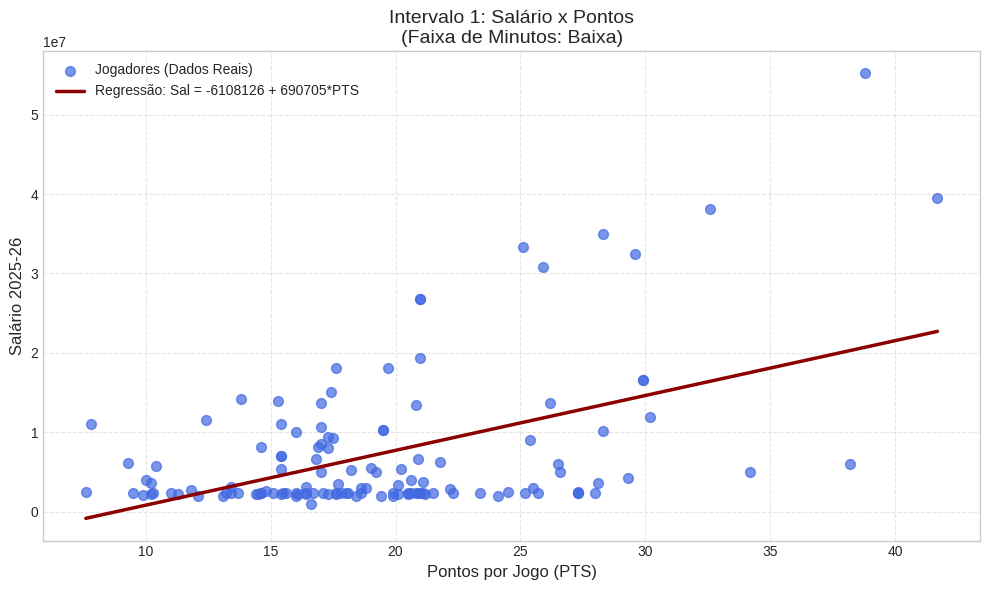


RESULTADOS DO INTERVALO 1:
Métrica         | Regressão Simples (PTS)   | Regressão Multivariada   
----------------------------------------------------------------------
R²              | 0.2334                    | 0.4100                   
R² Ajustado     | 0.2273                    | 0.3703                   
MAE             | 5759909.96                | 5017227.47               
MSE             | 6.25e+13                  | 4.81e+13                 
RMSE            | 7904576.94                | 6934639.23               
----------------------------------------------------------------------
Equação Simples: Salário = -6108125.63 + 690705.02 * PTS
Coefs. Multi (B0...B8): [-20235021.31, 3993.27, 249683.89, 1605358.37, 1298090.23, 1010182.99, 323532.66, -68571.66, 627999.21]




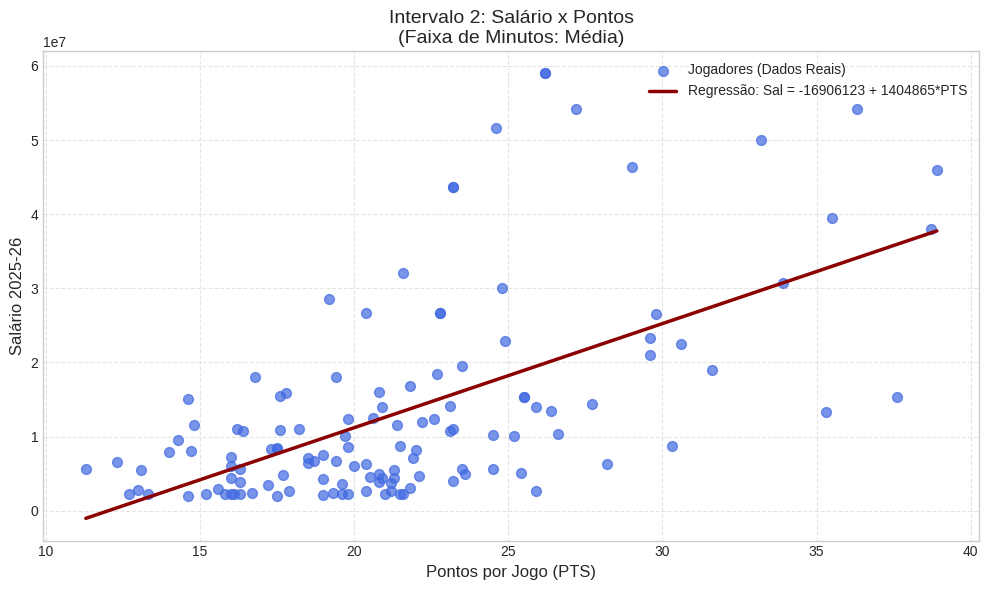


RESULTADOS DO INTERVALO 2:
Métrica         | Regressão Simples (PTS)   | Regressão Multivariada   
----------------------------------------------------------------------
R²              | 0.3489                    | 0.3631                   
R² Ajustado     | 0.3437                    | 0.3199                   
MAE             | 7854235.84                | 7659573.98               
MSE             | 1.20e+14                  | 1.17e+14                 
RMSE            | 10950567.99               | 10830632.23              
----------------------------------------------------------------------
Equação Simples: Salário = -16906122.71 + 1404864.87 * PTS
Coefs. Multi (B0...B8): [-27506021.32, 7682.56, 1563495.95, 93695.51, 246337.15, -457336.53, -327202.98, 46246.51, 169077.81]




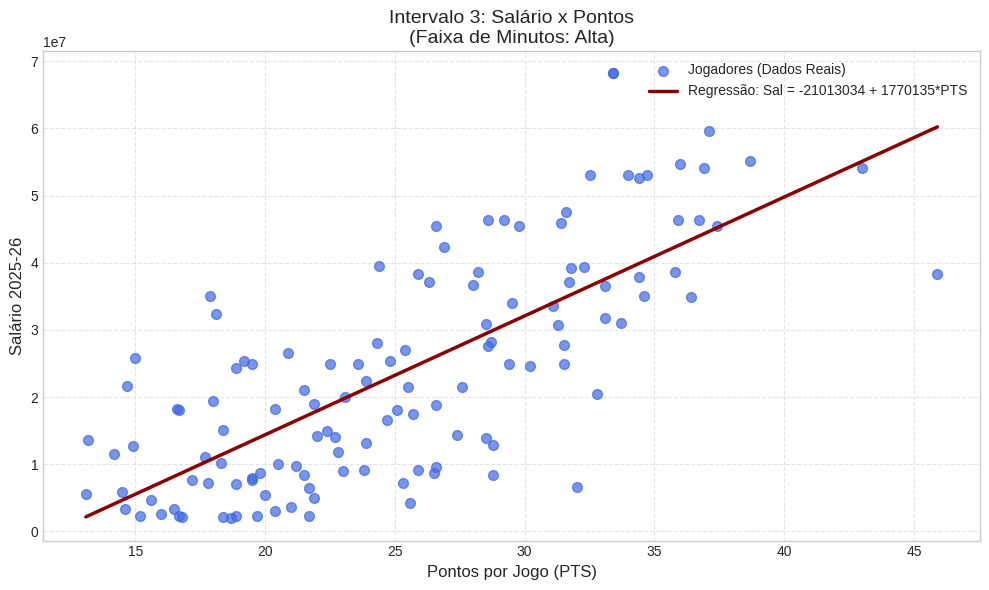


RESULTADOS DO INTERVALO 3:
Métrica         | Regressão Simples (PTS)   | Regressão Multivariada   
----------------------------------------------------------------------
R²              | 0.5518                    | 0.6098                   
R² Ajustado     | 0.5482                    | 0.5831                   
MAE             | 9058932.86                | 8304945.89               
MSE             | 1.24e+14                  | 1.08e+14                 
RMSE            | 11153988.55               | 10407730.06              
----------------------------------------------------------------------
Equação Simples: Salário = -21013033.90 + 1770135.16 * PTS
Coefs. Multi (B0...B8): [-32618154.61, 5855.63, 2065267.1, 957588.41, -324810.33, 1944299.9, -922744.34, -986432.92, 637993.38]




In [ ]:
import math
import matplotlib.pyplot as plt

def mean(v):
    return sum(v) / len(v)

def transpose(M):
    return list(map(list, zip(*M)))

def matmul(A, B):
    result = [[0 for _ in range(len(B[0]))] for _ in range(len(A))]
    for i in range(len(A)):
        for j in range(len(B[0])):
            for k in range(len(B)):
                result[i][j] += A[i][k] * B[k][j]
    return result

def inverse(M):
    n = len(M)
    aug = [row[:] + [1 if i == j else 0 for j in range(n)] for i, row in enumerate(M)]
    for i in range(n):
        pivot = aug[i][i]
        for j in range(2*n):
            aug[i][j] /= pivot
        for k in range(n):
            if k != i:
                factor = aug[k][i]
                for j in range(2*n):
                    aug[k][j] -= factor * aug[i][j]
    return [row[n:] for row in aug]


def regressao_linear_simples(x, y):
    xm = mean(x)
    ym = mean(y)
    num = sum((x[i]-xm)*(y[i]-ym) for i in range(len(x)))
    den = sum((x[i]-xm)**2 for i in range(len(x)))
    b1 = num / den
    b0 = ym - b1 * xm
    return b0, b1

def regressao_multivariada(X, y):
    XT = transpose(X)
    XTX = matmul(XT, X)
    XTy = matmul(XT, [[v] for v in y])
    inv = inverse(XTX)
    B = matmul(inv, XTy)
    return [b[0] for b in B]

def mse(y, yp):
    return sum((y[i] - yp[i])**2 for i in range(len(y))) / len(y)

def mae(y, yp):
    return sum(abs(y[i] - yp[i]) for i in range(len(y))) / len(y)

def r2(y, yp):
    ym = mean(y)
    sst = sum((yi - ym)**2 for yi in y)
    sse = sum((y[i] - yp[i])**2 for i in range(len(y)))
    if sst == 0: return 0
    return 1 - sse/sst

def r2_ajustado(y, yp, p):
    n = len(y)
    R2 = r2(y, yp)
    if (n - p - 1) == 0: return 0
    return 1 - (1 - R2) * (n - 1) / (n - p - 1)



MP  = list(dados["MP"])
PTS = list(dados["PTS"])
AST = list(dados["AST"])
STL = list(dados["STL"])
BLK = list(dados["BLK"])
FGA = list(dados["FGA"])
ORB = list(dados["ORB"])
DRB = list(dados["DRB"])
SAL = list(dados["2025-26"])

n = len(SAL)

mp_sorted = sorted(MP)
t1 = mp_sorted[n//3]
t2 = mp_sorted[2*n//3]

intervalo = []
for i in range(n):
    if MP[i] <= t1:
        intervalo.append(1)
    elif MP[i] <= t2:
        intervalo.append(2)
    else:
        intervalo.append(3)



print(" REGRESSÃO POR INTERVALOS DE MINUTOS JOGADOS (MP):")

resultados_interv_simples = []
resultados_interv_mult = []

for inter in [1, 2, 3]:


    X_lin = []   # Para regressão simples (apenas PTS)
    Y = []       # Salário (Target)
    X_mult = []  # Para regressão multivariada (Todas as stats)

    for i in range(n):
        if intervalo[i] == inter:
            X_lin.append(PTS[i])
            Y.append(SAL[i])


            X_mult.append([
                1, MP[i], PTS[i], AST[i], STL[i], BLK[i], FGA[i], ORB[i], DRB[i]
            ])

    # Regressão Simples (PTS -> SAL)
    b0, b1 = regressao_linear_simples(X_lin, Y)
    yp_lin = [b0 + b1*x for x in X_lin]

    # Métricas Simples
    metrics_lin = {
        "MSE": mse(Y, yp_lin),
        "MAE": mae(Y, yp_lin),
        "RMSE": math.sqrt(mse(Y, yp_lin)),
        "R2": r2(Y, yp_lin),
        "R2_adj": r2_ajustado(Y, yp_lin, p=1)
    }

    # Regressão Multivariada (Todas as Stats -> SAL)
    betas = regressao_multivariada(X_mult, Y)
    yp_multi = [
        sum(betas[j] * X_mult[i][j] for j in range(len(betas)))
        for i in range(len(Y))
    ]

    # Métricas Multivariada
    metrics_mult = {
        "MSE": mse(Y, yp_multi),
        "MAE": mae(Y, yp_multi),
        "RMSE": math.sqrt(mse(Y, yp_multi)),
        "R2": r2(Y, yp_multi),
        "R2_adj": r2_ajustado(Y, yp_multi, p=8)
    }

    resultados_interv_simples.append(metrics_lin)
    resultados_interv_mult.append(metrics_mult)

    plt.figure(figsize=(10, 6))
    plt.scatter(X_lin, Y, label="Jogadores (Dados Reais)", color='royalblue', alpha=0.7, s=50)


    x_line = sorted(X_lin)
    y_line = [b0 + b1*x for x in x_line]
    plt.plot(x_line, y_line, color='darkred', linewidth=2.5, label=f"Regressão: Sal = {b0:.0f} + {b1:.0f}*PTS")

    plt.title(f"Intervalo {inter}: Salário x Pontos\n(Faixa de Minutos: {'Baixa' if inter==1 else 'Média' if inter==2 else 'Alta'})", fontsize=14)
    plt.xlabel("Pontos por Jogo (PTS)", fontsize=12)
    plt.ylabel("Salário 2025-26", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


    print(f"\nRESULTADOS DO INTERVALO {inter}:")
    print(f"{'Métrica':<15} | {'Regressão Simples (PTS)':<25} | {'Regressão Multivariada':<25}")
    print("-" * 70)
    print(f"{'R²':<15} | {metrics_lin['R2']:<25.4f} | {metrics_mult['R2']:<25.4f}")
    print(f"{'R² Ajustado':<15} | {metrics_lin['R2_adj']:<25.4f} | {metrics_mult['R2_adj']:<25.4f}")
    print(f"{'MAE ':<15} | {metrics_lin['MAE']:<25.2f} | {metrics_mult['MAE']:<25.2f}")
    print(f"{'MSE':<15} | {metrics_lin['MSE']:<25.2e} | {metrics_mult['MSE']:<25.2e}")
    print(f"{'RMSE':<15} | {metrics_lin['RMSE']:<25.2f} | {metrics_mult['RMSE']:<25.2f}")
    print("-" * 70)
    print(f"Equação Simples: Salário = {b0:.2f} + {b1:.2f} * PTS")
    print(f"Coefs. Multi (B0...B8): {[round(b, 2) for b in betas]}")
    print("\n")

A análise por intervalos de minutos mostrou que a relação entre desempenho e salário depende fortemente da minutagem do jogador. Nos intervalos de baixa e média minutagem, tanto a regressão simples quanto a multivariada apresentaram baixo poder explicativo, indicando grande variabilidade salarial que não é bem capturada apenas pelas estatísticas.

Já no intervalo de alta minutagem, os modelos obtiveram seus melhores valores de R², mostrando que, entre jogadores com papel mais consistente em quadra, as estatísticas passam a ser muito mais úteis para prever o salário futuro. A regressão multivariada teve desempenho ligeiramente superior, reforçando que múltiplas métricas juntas explicam melhor o valor salarial do que só os pontos por jogo.

#Comparação das regressões
Como ja foi testado, nem todas regressões possuem erros com distribuição normal, portanto, precisamos comparar de uma forma justa para todas as regressões. Para que tenhamos uma comparação imparcial, podemos utilizar o erro absoluto de cada regressão:

In [ ]:
# Tabela de comparação
col_modelo_width = 33
col_r2_width = 12
col_rmse_width = 15
col_mae_width = 15

simp_r2_adj = np.mean([m['R2_adj'] for m in resultados_interv_simples])
simp_rmse   = np.mean([m['RMSE'] for m in resultados_interv_simples])
simp_mae    = np.mean([m['MAE'] for m in resultados_interv_simples])

multi_r2_adj = np.mean([m['R2_adj'] for m in resultados_interv_mult])
multi_rmse   = np.mean([m['RMSE'] for m in resultados_interv_mult])
multi_mae    = np.mean([m['MAE'] for m in resultados_interv_mult])

print(f"{'Modelo':<{col_modelo_width}} | {'R² Ajustado':^{col_r2_width}} | {'RMSE':>{col_rmse_width}} | {'MAE':>{col_mae_width}}")
print(f"{'-'*col_modelo_width}-|{'-'*col_r2_width}--|{'-'*col_rmse_width}--|{'-'*col_mae_width}")

print(f"{'OLS (statsmodels)':<{col_modelo_width}} | {ols_adj_r2:^{col_r2_width}.4f} | {ols_rmse:>{col_rmse_width}.2f} | {mae_ols:>{col_mae_width}.2f}")
print(f"{f'LassoCV (alpha={best_alpha:.1f})':<{col_modelo_width}} | {adj_r2_lasso_cv:^{col_r2_width}.4f} | {rmse_lasso_cv:>{col_rmse_width}.2f} | {mae_lasso:>{col_mae_width}.2f}")
print(f"{f'Polinomial (Grau={degree})':<{col_modelo_width}} | {adj_r2_poly:^{col_r2_width}.4f} | {rmse_poly:>{col_rmse_width}.2f} | {mae_poly:>{col_mae_width}.2f}")
print(f"{'Random Forest':<{col_modelo_width}} | {R2_rf:^{col_r2_width}.4f} | {RMSE_rf:>{col_rmse_width}.2f} | {MAE_rf:>{col_mae_width}.2f}")
print(f"{'Reg. Intervalar (Simples)':<{col_modelo_width}} | {simp_r2_adj:^{col_r2_width}.4f} | {simp_rmse:>{col_rmse_width}.2f} | {simp_mae:>{col_mae_width}.2f}")
print(f"{'Reg. Intervalar (Multi)':<{col_modelo_width}} | {multi_r2_adj:^{col_r2_width}.4f} | {multi_rmse:>{col_rmse_width}.2f} | {multi_mae:>{col_mae_width}.2f}")

Modelo                            | R² Ajustado  |            RMSE |             MAE
----------------------------------|--------------|-----------------|---------------
OLS (statsmodels)                 |    0.5412    |     10217537.10 |      7696663.23
LassoCV (alpha=312806.9)          |    0.5467    |     10075991.37 |      7656943.25
Polinomial (Grau=2)               |    0.5808    |      9765839.38 |      6850690.82
Random Forest                     |    0.6970    |      7832857.45 |      6138726.78
Reg. Intervalar (Simples)         |    0.3731    |     10003044.49 |      7557692.89
Reg. Intervalar (Multi)           |    0.4244    |      9391000.51 |      6993915.78


É importante destacar que o R² ajustado e o RMSE do Random Forest não são métricas totalmente confiáveis, portanto precisamos analisar pelo erro absoluto (MAE). Assim, como o Random Forest apresenta o menor MAE, podemos concluir que ele é o melhor método para nossa análise.

#Análise de Clusters

Vamos tentar separar os jogadores em grupos, antes disso precisamos normalizar os dados para garantir que todoas as estatísticas tenham a mesma influência:

In [ ]:
features = ['PTS','AST', 'FGA', 'ORB', 'DRB', 'STL', 'BLK']
dados_cluster = dados[features]
scaler = StandardScaler()
dados_escalonados = scaler.fit_transform(dados_cluster)

dados_escalonados = pd.DataFrame(dados_escalonados, columns=features)
dados_escalonados.head()

,PTS,AST,FGA,ORB,DRB,STL,BLK
0,-0.922153,-0.785622,-1.013306,-1.119877,-0.825856,-0.948612,-0.979890
1,0.193586,-0.785622,0.288098,-0.217056,-0.058975,-0.612563,-0.495821
2,-0.834069,0.234615,-0.301601,-1.059689,-1.094265,-1.284662,-0.979890
3,0.413798,0.156136,-0.179594,0.204260,-0.442416,-1.452687,-0.616838
4,-0.173434,-0.000824,-0.179594,-0.939313,-1.017577,-0.780588,-0.374804


Usaremos o K-means com o coeficiente de silhueta para verificar qual é o melhor número de Cluster (K) para nossos dados:


O melhor valor de k segundo o coeficiente de Silhueta é: 3


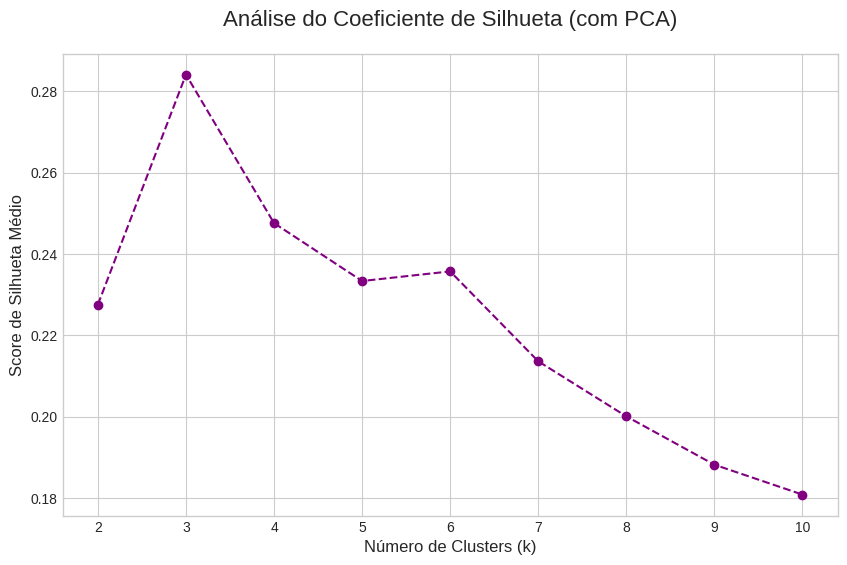

In [ ]:
from sklearn.decomposition import PCA

# Reduzir dimensionalidade com PCA
pca = PCA(n_components=0.95)  # mantém 95% da variância
dados_pca = pca.fit_transform(dados_escalonados)

# Calcular o coeficiente de silhueta para diferentes k
silhouette_scores = []
range_k = range(2, 11)

for k in range_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    cluster_labels = kmeans.fit_predict(dados_pca)
    silhouette = silhouette_score(dados_pca, cluster_labels)
    silhouette_scores.append(silhouette)

# Melhor valor de k
k_otimo_silhueta = range_k[silhouette_scores.index(max(silhouette_scores))]
print(f"\nO melhor valor de k segundo o coeficiente de Silhueta é: {k_otimo_silhueta}")

# Plotar gráfico
plt.figure(figsize=(10, 6))
plt.plot(range_k, silhouette_scores, marker='o', linestyle='--', color='purple')
plt.title('Análise do Coeficiente de Silhueta (com PCA)', fontsize=16, pad=20)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Score de Silhueta Médio', fontsize=12)
plt.xticks(range_k)
plt.grid(True)
plt.show()


Com o melhor número de clusters para os nossos dados, podemos separá-los:

In [ ]:
dados_para_treino = dados.copy()

kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
dados_para_treino['Cluster'] = kmeans.fit_predict(dados_escalonados)


mapa_clusters = dados_para_treino[['Player', 'Cluster']]
tabela_geral_com_clusters = pd.merge(dados, mapa_clusters, on='Player', how='left')

print("Perfil Médio de Cada Cluster:")
perfil_k3 = tabela_geral_com_clusters.groupby('Cluster')[features].mean()
display(perfil_k3)

cluster_0 = tabela_geral_com_clusters[tabela_geral_com_clusters['Cluster'] == 0].copy()
cluster_1 = tabela_geral_com_clusters[tabela_geral_com_clusters['Cluster'] == 1].copy()
cluster_2 = tabela_geral_com_clusters[tabela_geral_com_clusters['Cluster'] == 2].copy()

print(f"\nCluster 0 (Armadores) contém {len(cluster_0)} jogadores.")
print(f"Cluster 1 (Pivôs) contém {len(cluster_1)} jogadores.")
print(f"Cluster 2 (Alas) contém {len(cluster_2)} jogadores.")

coluna_salario = '2025-26'

media_salarial = tabela_geral_com_clusters.groupby('Cluster')[coluna_salario].mean()

print("=== Média Salarial por Cluster ===")
print(f"Cluster 0 (Armadores): $ {media_salarial[0]:,.2f}")
print(f"Cluster 1 (Pivôs):     $ {media_salarial[1]:,.2f}")
print(f"Cluster 2 (Alas):      $ {media_salarial[2]:,.2f}")

Perfil Médio de Cada Cluster:


,PTS,AST,FGA,ORB,DRB,STL,BLK
Cluster,,,,,,,
0,30.201818,7.509091,23.325455,1.420909,6.091818,1.699091,0.674545
1,21.059091,3.643182,15.628409,4.754545,10.030682,1.465909,2.096591
2,18.265672,4.528856,15.062189,1.796517,5.395522,1.737811,0.691542



Cluster 0 (Armadores) contém 110 jogadores.
Cluster 1 (Pivôs) contém 88 jogadores.
Cluster 2 (Alas) contém 201 jogadores.
=== Média Salarial por Cluster ===
Cluster 0 (Armadores): $ 29,682,307.95
Cluster 1 (Pivôs):     $ 13,323,473.30
Cluster 2 (Alas):      $ 8,686,923.69


Analisando características de cada cluster, fizemos a separação:

*   Cluster 0: Com médias muito acima dos outros em Pontos e Assistências, será o grupo dos Armadores;
*   Cluster 1: Com médias muito acima dos outros em Rebotes e Tocos, será o grupo do Pivôs;
*   Cluster 2: Tento um desempenho intermediário, fazendo um pouco de tudo, será o grupo dos Alas.



Podemos ver que a média salarial dos armadores é substancialmente maior que dos outros grupos, apoiando nossa hipótese de que a posição do jogador pode influenciar de fato em seu salário

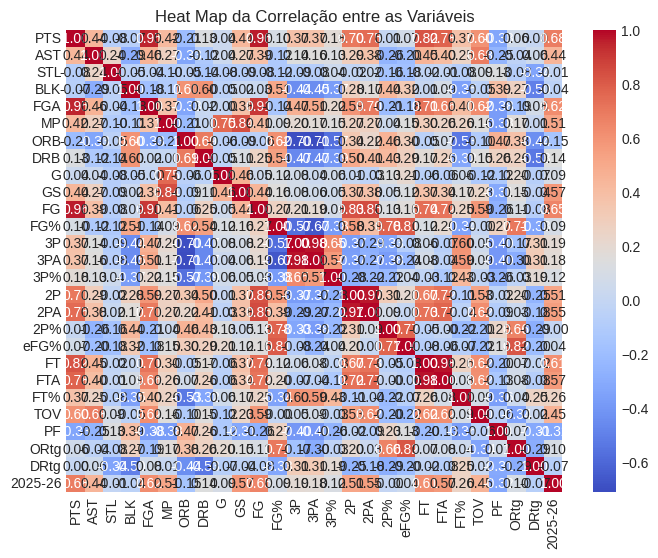

In [ ]:
corr = dados.drop(['Player'],axis=1).corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heat Map da Correlação entre as Variáveis')
plt.show()

A matriz mostra que PTS, FGA e MP são as variáveis mais fortemente correlacionadas com o salário, indicando que volume ofensivo e tempo em quadra têm maior impacto na remuneração. Por outro lado, estatísticas defensivas como STL e BLK apresentam correlações fracas, sugerindo menor influência direta no salário em comparação às métricas de produção ofensiva.

#Classificadores

Distribuição das Classes de Salário:
Categoria_Salario
Médio    128
Baixo    127
Alto     126
Name: count, dtype: int64
------------------------------
Tamanho do treino: 266 amostras
Tamanho do teste: 115 amostras
------------------------------
--- Regressão Logística ---
Acurácia: 0.5739

Matriz de Confusão:
[[29  4  5]
 [ 3 21 14]
 [ 8 15 16]]

Relatório de Classificação:
              precision    recall  f1-score   support

        Alto       0.72      0.76      0.74        38
       Baixo       0.53      0.55      0.54        38
       Médio       0.46      0.41      0.43        39

    accuracy                           0.57       115
   macro avg       0.57      0.58      0.57       115
weighted avg       0.57      0.57      0.57       115

------------------------------
--- Random Forest Classifier ---


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Acurácia: 0.5739

Matriz de Confusão:
[[28  1  9]
 [ 6 22 10]
 [11 12 16]]

Relatório de Classificação:
              precision    recall  f1-score   support

        Alto       0.62      0.74      0.67        38
       Baixo       0.63      0.58      0.60        38
       Médio       0.46      0.41      0.43        39

    accuracy                           0.57       115
   macro avg       0.57      0.58      0.57       115
weighted avg       0.57      0.57      0.57       115

------------------------------
--- Importância das Features (Random Forest) ---


/tmp/ipython-input-2396916228.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')


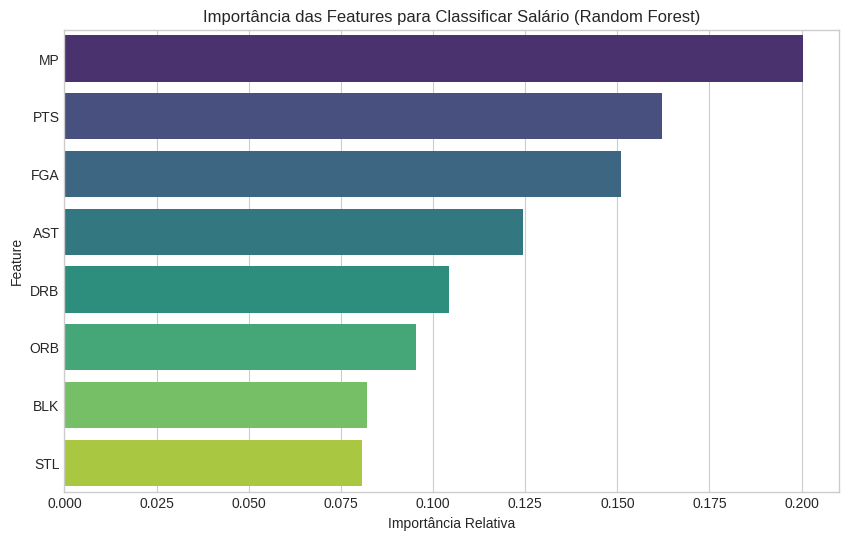


Importâncias:
MP     0.200234
PTS    0.162132
FGA    0.150862
AST    0.124348
DRB    0.104251
ORB    0.095287
BLK    0.082136
STL    0.080749
dtype: float64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


dados['Categoria_Salario'] = pd.qcut(dados['2025-26'], q=3, labels=['Baixo', 'Médio', 'Alto'])
print("Distribuição das Classes de Salário:")
print(dados['Categoria_Salario'].value_counts())
print("-" * 30)

features_clf = ['PTS','AST','STL','BLK','FGA','MP','ORB','DRB']
X_clf = dados[features_clf]
y_clf = dados['Categoria_Salario']


X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf,
    test_size=0.3,
    random_state=42,
    stratify=y_clf
)

print(f"Tamanho do treino: {X_train_clf.shape[0]} amostras")
print(f"Tamanho do teste: {X_test_clf.shape[0]} amostras")
print("-" * 30)


scaler_clf = StandardScaler()
X_train_clf_scaled = scaler_clf.fit_transform(X_train_clf)
X_test_clf_scaled = scaler_clf.transform(X_test_clf)


print("--- Regressão Logística ---")
log_reg = LogisticRegression(random_state=42, multi_class='auto', max_iter=1000)
log_reg.fit(X_train_clf_scaled, y_train_clf)
y_pred_log_reg = log_reg.predict(X_test_clf_scaled)

print(f"Acurácia: {accuracy_score(y_test_clf, y_pred_log_reg):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test_clf, y_pred_log_reg))
print("\nRelatório de Classificação:")
print(classification_report(y_test_clf, y_pred_log_reg))
print("-" * 30)

print("--- Random Forest Classifier ---")
rf_clf = RandomForestClassifier(n_estimators=150, random_state=42)
rf_clf.fit(X_train_clf_scaled, y_train_clf)
y_pred_rf_clf = rf_clf.predict(X_test_clf_scaled)

print(f"Acurácia: {accuracy_score(y_test_clf, y_pred_rf_clf):.4f}")
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test_clf, y_pred_rf_clf))
print("\nRelatório de Classificação:")
print(classification_report(y_test_clf, y_pred_rf_clf))
print("-" * 30)

print("--- Importância das Features (Random Forest) ---")
importances = rf_clf.feature_importances_
feature_importances = pd.Series(importances, index=features_clf).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances, y=feature_importances.index, palette='viridis')
plt.title('Importância das Features para Classificar Salário (Random Forest)')
plt.xlabel('Importância Relativa')
plt.ylabel('Feature')
plt.show()

print("\nImportâncias:")
print(feature_importances)

Os modelos de classificação apresentaram desempenho moderado, com acurácia de aproximadamente 57% tanto para Regressão Logística quanto para Random Forest, indicando que prever faixas salariais apenas com as estatísticas básicas possui limitações. A análise de importância do Random Forest mostrou que MP, PTS e FGA são as variáveis mais relevantes para distinguir entre salários Baixo, Médio e Alto, reforçando que tempo em quadra e volume ofensivo são os fatores que mais influenciam a categorização salarial. Features defensivas tiveram menor impacto, contribuindo menos para a separação entre as classes.